# [이론] 베이즈 — 사전에서 사후로

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 오늘 배울 것

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">AI 데이터 인텔리전스 전문가 과정 · 모형추정과 심화통계</div>
<h1 style="color:#000000;margin:10px 0">베이즈 — 사전에서 사후로, 두 후보 비교</h1>
<div style="font-size:1.05em;color:#656565">사전분포에 우도를 곱해 사후분포를 구하고, 추정 결과를 모수의 확률분포로 표현하는 베이즈 추정</div>
</div>

## 오늘 배울 것

**이 절에서 할 일**

1. 어제 정의한 우도와 MLE 를 몇 문장으로 요약하고, 오늘 무엇을 추가할지 정합니다.
2. 오늘의 핵심 질문 1개를 정하고, 절 6개가 그 질문에 답하는 순서를 확인합니다.
3. 어제 배운 확률과 우도를 그림 1장으로 구분해 두고 출발합니다.

어제는 **우도** $L(p)$ 를 정의하고, 그 값이 가장 큰 모수값을 추정값으로 선택하는 **MLE** 를 다루었습니다 — 동전 10번에 앞면 7번이면 $\hat{p} = k/n = 0.70$ 이 그 값입니다. 그리고 어제 4절에서 이 방법의 한계를 확인했습니다. 3번 던져 3번 앞면이면 MLE 는 아무 보정 없이 $\hat{p} = 1.0$, 곧 "이 동전은 뒷면이 안 나온다"는 값을 그대로 산출합니다. 데이터만 보는 방법이라 "그래도 동전이면 반반 근처겠지"라는 상식을 반영할 항이 아예 없었기 때문입니다.

<details class="lms-extra"><summary>자세히 — 1편의 우도·MLE 와 그 한계: 수치 예</summary>

**⑴ 우도가 무엇이었나.** 데이터를 고정하고 모수 후보 하나하나에 대해 "이 값이라면 지금 이 데이터가 얼마나 그럴듯한가" 를 수치로 계산한 것이었습니다. 동전 10번에 앞면 7번이라는 데이터를 고정하고 $p$ 를 0 부터 1 까지 변화시키며 그 값을 계산한 곡선이 우도곡선이고, 최댓값의 위치, 곧 MLE 가 $\hat{p} = k/n = 7/10 = 0.70$ 이었습니다.

**⑵ 3번에 3번 앞면일 때가 문제입니다.** 같은 규칙을 그대로 쓰면 $\hat{p} = 3/3 = 1.0$ 입니다. 추정값의 산포를 측정하는 표준오차에 그 값을 대입합니다. $\hat{p}$ 에 1.0 을, $n$ 에 3 을 넣습니다.

$$
\mathrm{SE} = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}} = \sqrt{\frac{1.0 \times 0}{3}} = 0
$$

**⑶ 그래서 구간도 사라집니다.** 신뢰구간은 $\hat{p} \pm 2\,\mathrm{SE}$ 라 위아래로 더하고 뺄 값이 $2 \times 0 = 0$ 이고, 구간의 길이는 그 2배인 0 입니다. "뒷면은 나오지 않는다" 를 불확실성 없이 단언하는 것이라, 관측 3건으로 내릴 결론은 아닙니다.

</details>

오늘은 그 사전 정보를 베이즈 정리의 사전분포 $P(\theta)$ 로 식에 넣습니다.

> **"동전이면 앞면 확률이 0.5 근처겠지 — 이 사전 정보를 식의 어느 항으로 표현하고, 데이터와 어떤 비율로 결합할까?"**

## 오늘의 절 구성

절 6개가 앞의 질문 1개에 순서대로 답합니다.

| 절 | 이 절이 답하는 것 |
|---|---|
| 1절 왜 베이즈 추정인가 | 데이터만 보는 방법의 한계를 식의 어느 항으로 메우는가 |
| 2절 사전분포를 적는 법 — 베타분포 | 사전 정보를 숫자 2개로 어떻게 적는가 |
| 3절 켤레 — 적분 없이 덧셈으로 | 그 곱셈을 덧셈 2회로 끝내고 값 하나로 보고하려면 |
| 4절 실무 적용 — 자동차보험 데이터 | 계약 67만 8천 건에 적용하면 어떤 값이 나오는가 |
| 5절 두 집단 비교와 사고 건수 | "다른 집단보다 실제로 더 나쁜가"에 확률 하나로 답하려면 |
| 6절 오늘의 정리와 수업에서 다룰 질문 | 오늘 다룬 내용을 한 장으로 정리하면 |

**학습 목표**

- 1절 — 사전분포·우도·증거·사후분포를 베이즈 정리의 각 항에 대응시킵니다
- 2절 — 베타분포의 모수 2개로 사전분포를 적고, 가상 관측 수 $\nu$ 와 강도 $\alpha+\beta$ 를 구분해 사전분포의 비중 $\nu/(\nu+n)$ 을 계산합니다
- 3절 — 켤레로 갱신을 덧셈 2회로 수행하고, MAP 와 신용구간으로 결과를 보고합니다
- 4절 — 계약별 노출 기간이 다를 때 사고율의 분모를 노출로 정하고, 노출이 작은 세그먼트의 수축을 확인합니다
- 5절 — 두 집단의 사후분포를 비교해 $P(\theta_B > \theta_A)$ 를 내고, 지표를 사고 건수 ÷ 노출로 바꾸면 그 답이 0.980 에서 0.712 로 달라지는 것을 확인합니다
- 6절 — 오늘 구분한 개념 쌍 5개를 숫자와 함께 다시 적습니다

**그래서** 1절에서는 사전 정보를 넣을 항을 베이즈 정리에서 찾습니다. 2절에서는 그 항을 베타분포의 숫자 2개로 적고, 3절에서는 갱신을 덧셈 2회로 줄여 MAP 와 신용구간을 계산합니다. 4절은 그 도구를 자동차보험 계약에 적용하고, 5절은 두 지역의 사후분포를 비교합니다.

시작하기 전에 어제 배운 용어 2개, 확률과 우도를 그림 1장으로 정리합니다. 같은 식 $P(x \mid p)$ 를 어느 쪽을 고정하는가에 따라 구분해 표현한 그림입니다.

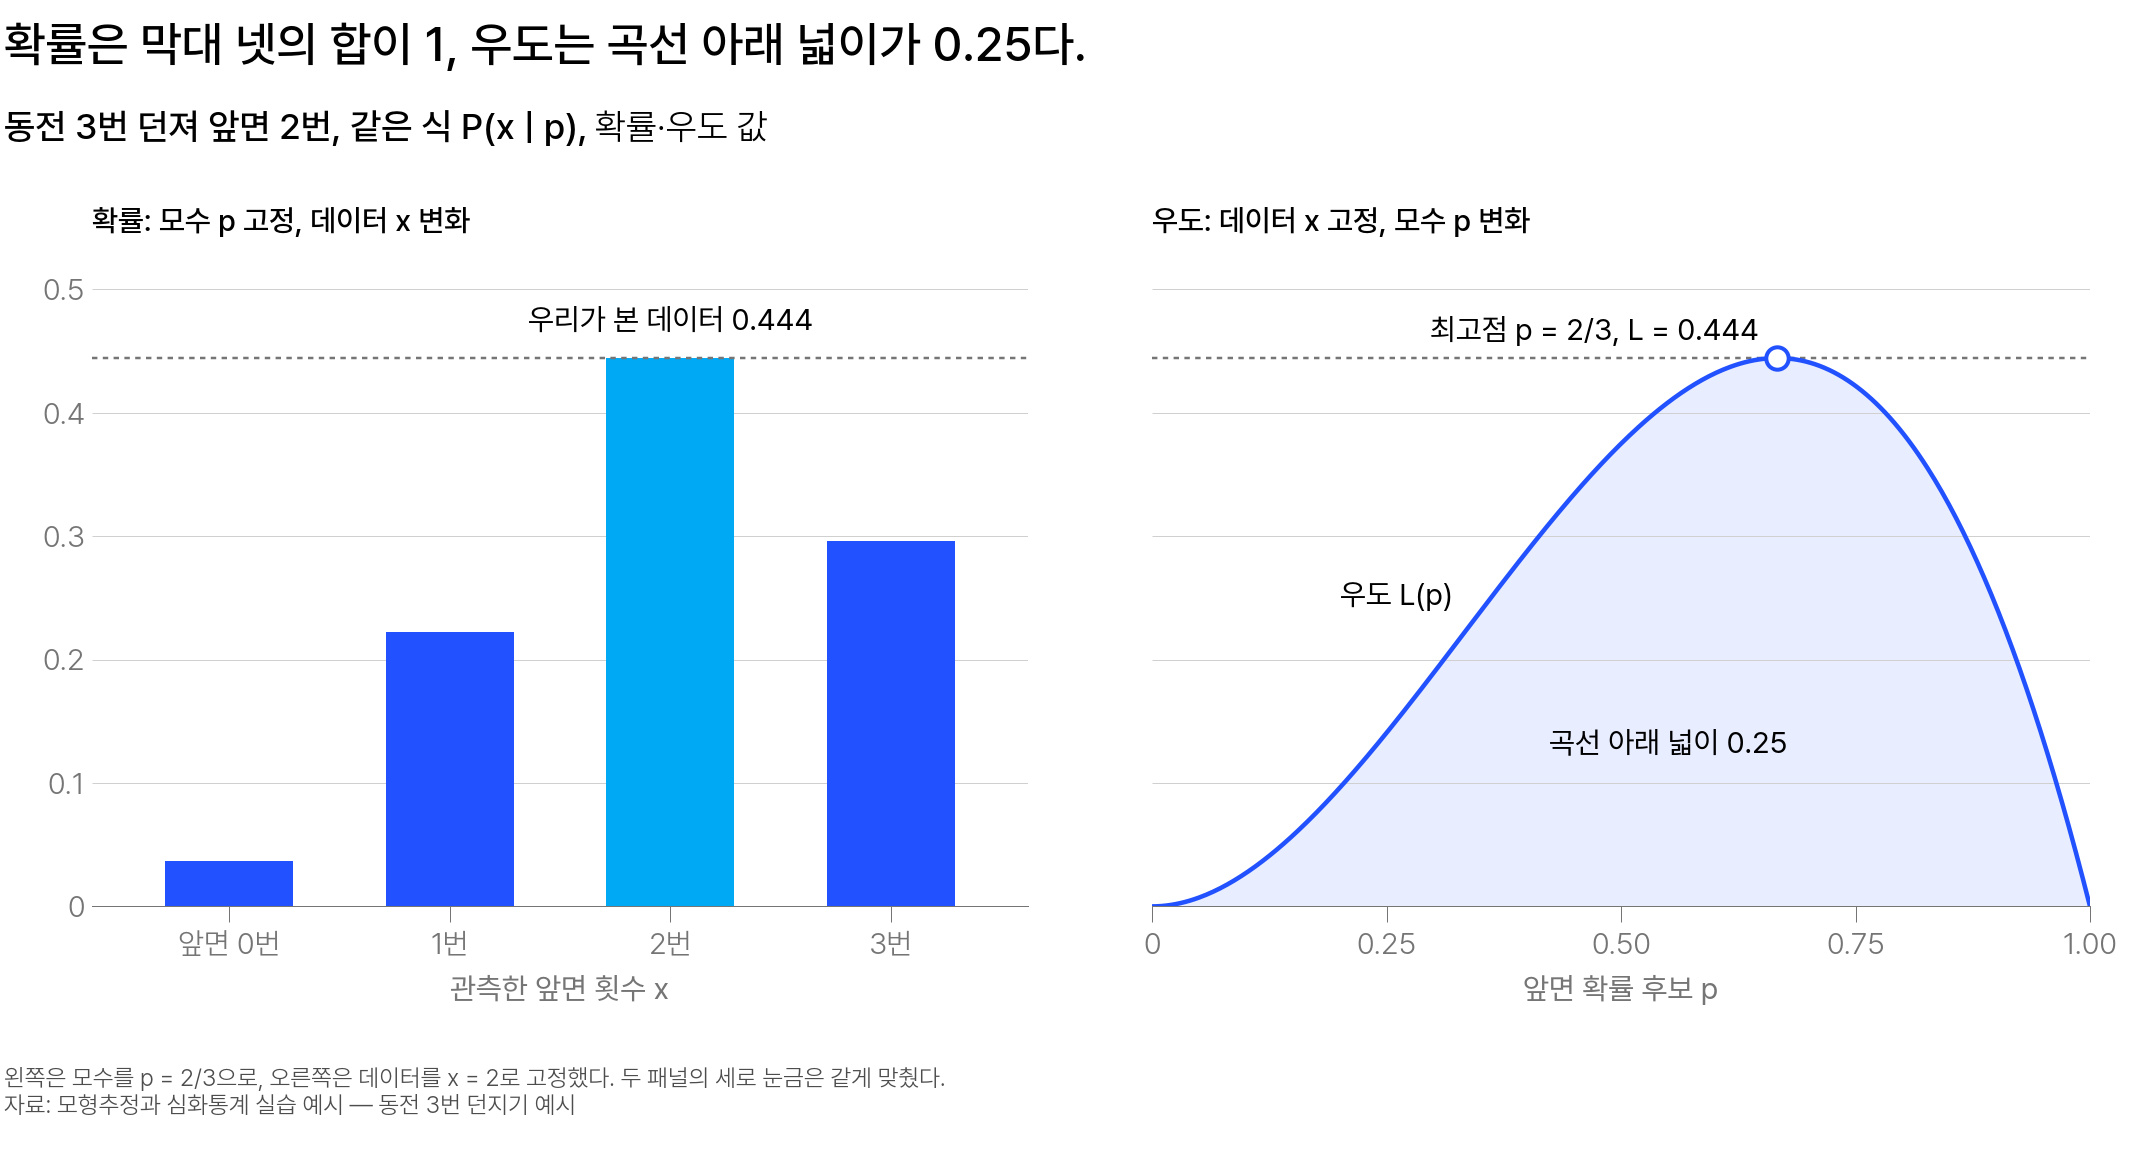

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 같은 식 P(x | p) 를 두 방향으로 읽기 — 왼쪽은 모수를 p = 2/3 으로 고정하고 데이터를 변화시킨 확률이라 막대 4개의 합이 1 이고, 하늘색 「앞면 2번」 막대가 우리가 본 데이터 0.444 다. 오른쪽은 데이터를 x = 2 로 고정하고 모수를 움직인 우도라, 최댓값의 위치가 p = 2/3 이고 그 값도 같은 0.444 이며 곡선 아래 넓이는 1 이 아니라 0.25 다 — 두 패널의 세로축 척도는 같게 맞췄다</em></p>

높이는 같은 0.444 인데 왼쪽은 확률, 오른쪽은 우도입니다. 무엇을 고정하고 무엇을 변화시켰는지가 둘을 구분하는 기준이고, 오늘은 이 우도에 사전분포를 곱하는 데서 출발합니다.

## 1절 왜 베이즈 추정인가

## 데이터만으로는 넣을 수 없는 것

**이 절에서 할 일**

1. 어제 방법의 한계를 숫자 하나로 확인합니다 — 3번 던져 3번 앞면이면 MLE 는 1.0, 표준오차는 0 입니다.
2. 그 한계를 메울 항을 베이즈 정리에서 찾고, 항 4개에 이름을 부여합니다.
3. 사후분포를 구하는 일이 「모수의 분포」를 구하는 일이라는 것까지 확인합니다.

어제 4절은 관측 수가 적으면 MLE 가 $3/3 = 1.0$ 처럼 구간의 끝값으로 나온다는 것을 보여 주었습니다. 어제 3절 표의 마지막 행, 곧 계약 63건 중 사고 4건으로 MLE 0.0635 를 낼 때도 이미 알고 있던 전체 계약(회사 전체)의 사고 경험률 5.02% 를 넣을 항이 식에 없었습니다. 베이즈 추정은 그 항을 도입합니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Thomas_Bayes.gif" width="304" height="326"/>
<p align="center"><em>▲ 토머스 베이즈의 초상으로 전해지는 그림 — 오늘 쓰는 갱신 규칙은 그가 남긴 원고가 1763년에 발표되며 세상에 나왔다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia</span></p>

**사전분포(prior)** — 데이터를 보기 전에 어느 모수값이 얼마나 그럴듯한지 미리 그려 둔 분포입니다. "동전이면 그래도 반반 근처겠지" 가 여기 들어갑니다. 기호로는 $P(\theta)$ 라 적습니다.

그 분포를 식의 어느 항에 곱하는지부터 봅니다.

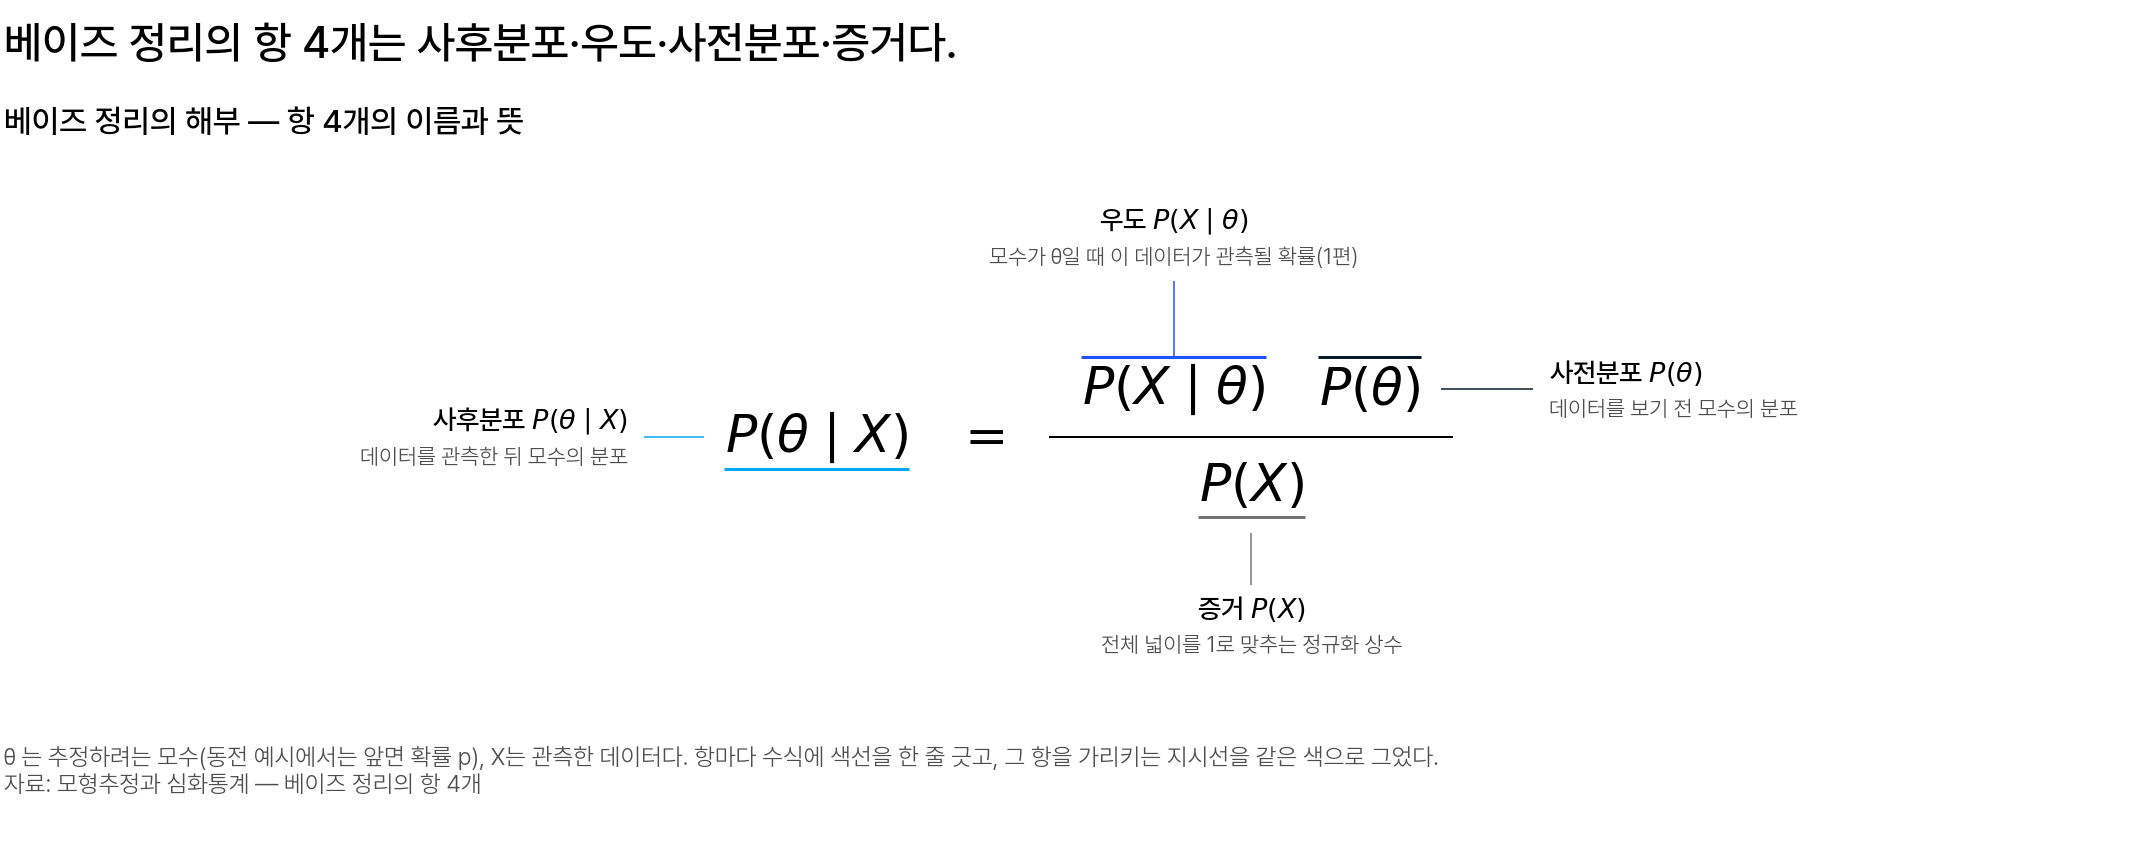

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 베이즈 정리의 항 4개 — 어제의 우도 P(X | θ) 가 분자에 있고, 사전분포 P(θ) 를 곱해 증거 P(X) 로 나누면 사후분포 P(θ | X) 가 된다</em></p>

식에 등장하는 기호는 2개입니다. 동전 예시에서는 $\theta = p$(앞면 확률)이고 $X$ 는 "10번 던져 앞면 7번" 입니다.

$$
P(\theta \mid X) = \frac{P(X \mid \theta)\,P(\theta)}{P(X)}
$$

- $\theta$ : 추정하려는 모수 — 동전이면 앞면 확률 $p$ 입니다
- $X$ : 관측한 데이터 — 동전이면 "10번 던져 앞면 7번" 입니다

항의 이름이 「확률」이 아니라 「분포」로 끝나는 이유도 여기서 정리해 둡니다. 좌변을 「사후 확률」이라 부르는 자료도 있지만, $\theta$ 가 0～1 의 연속값이면 한 점의 확률은 0 이라 $P(\theta \mid X)$ 가 나타내는 값은 확률이 아니라 **확률밀도**입니다. 그래서 이 교재는 분포 전체를 가리키는 **사후분포**로 부르고, 확률은 구간의 넓이에만 부여합니다.

## 베이즈 정리의 항 4개 — 사전분포·우도·증거·사후분포

식을 세 부분으로 나눠 읽습니다 — 좌변은 데이터를 본 뒤의 모수, 우변 분자는 항 2개의 곱, 분모는 전체 넓이를 1 로 맞추는 정규화 상수입니다. 앞으로 계속 사용할 용어 4개입니다.

- **사전분포(prior)** $P(\theta)$ — 데이터를 보기 **전**에 설정해 둔 분포입니다
- **우도(likelihood)** $P(X \mid \theta)$ — 모수가 $\theta$ 라면 이 데이터가 나올 가능성입니다. 어제 정의한 그 우도값입니다
- **사후분포(posterior)** $P(\theta \mid X)$ — 데이터를 본 **후**로 다시 계산한 분포, 곧 베이즈 추정의 산출물입니다
- **증거(evidence)** $P(X)$ — 우도를 사전분포로 가중해 평균 낸 데이터의 확률입니다. 곡선 아래 넓이를 1 로 맞추는 **정규화 상수**입니다

$\theta$ 가 동전의 앞면 확률이라면 사전분포는 "반반 근처" 라는 상식이고, 우도는 어제 그린 그 곡선이며, 사후분포는 둘을 곱해 다시 그린 곡선입니다.

## 사후 ∝ 사전 × 우도 — 모수의 분포를 구한다

분모 $P(X)$ 는 $\theta$ 와 무관한 상수라, 사후분포의 **모양**은 분자가 정합니다. 그래서 실무에서는 흔히 비례식으로 씁니다.

$$
\underbrace{P(\theta \mid X)}_{\text{사후}} \;\propto\; \underbrace{P(X \mid \theta)}_{\text{우도}} \times \underbrace{P(\theta)}_{\text{사전}}
$$

- $\propto$ : "비례한다" — 상수 배 차이를 무시하면 같다는 뜻입니다. 곡선의 **모양**은 분자가 정하고, 분모는 전체 넓이를 1 로 맞추는 역할만 합니다

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Bayes_icon.svg" width="640" height="384"/>
<p align="center"><em>▲ 사후 ∝ 우도 × 사전 — 가로축은 추정하려는 모수(비례식의 세타, 동전이라면 앞면 확률 p)이고 세로축은 그 값이 얼마나 그럴듯한지다. 눈금값 없이 모양만 보는 그림에서 낮고 넓게 분포한 빨강이 사전분포, 오른쪽으로 이동해 좁고 높아진 파랑이 사후분포다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia</span></p>

어제와 오늘의 차이는 **확률분포를 어디에 두는가** 하나입니다. 어제는 참값 $p$ 를 알 수 없는 상수로 두고 무작위성을 데이터 쪽에 두었습니다. 그래서 확률은 데이터와 그로부터 계산한 $\hat{p}$ 에만 부여됐고, 「$p$ 가 0.6～0.8 사이일 확률」 같은 문장은 정의되지 않았습니다. 오늘은 이미 관측한 데이터를 고정하고 모수 $p$ 쪽에 분포를 둡니다.

그래서 **데이터의 분포**와 **모수의 분포**를 구분합니다. 어제의 표준오차는 표본을 다시 추출할 때 $\hat{p}$ 이 얼마나 달라지는지 측정하는 값이라 데이터의 분포에 속합니다. 오늘 구하는 사후분포는 모수 $p$ 자체의 분포라, 「$p$ 가 0.6～0.8 사이일 확률은 95%」처럼 모수에 확률을 부여한 문장을 쓸 수 있습니다. 어제의 신뢰구간과 오늘의 신용구간이 갈리는 지점도 여기인데, 두 구간을 나란히 놓는 일은 3절에서 합니다.

**그래서** 1절이 답한 것은 하나입니다. 상식을 반영할 항은 사전분포 $P(\theta)$ 이고, 그 항에 적은 것을 우도와 곱하면 모수의 분포인 사후분포가 나옵니다. 사전분포를 숫자로 어떻게 적을지는 2절에서 정합니다.

#### 핵심 주의점

$P(X \mid \theta)$ 와 $P(\theta \mid X)$ 는 다른 값입니다.

$$
P(\theta \mid X) = \frac{P(X \mid \theta)\,P(\theta)}{P(X)}
$$

$P(X \mid \theta)$ 는 모수 $\theta$ 를 고정했을 때 데이터 $X$ 가 관측될 확률입니다(우도로 읽을 때는 $X$ 를 고정한 $\theta$ 의 함수). $P(\theta \mid X)$ 는 데이터 $X$ 를 관측한 뒤 모수 $\theta$ 의 확률밀도, 곧 사후분포입니다. 위 식처럼 $P(X \mid \theta)$ 에 사전분포 $P(\theta)$ 를 곱하고 $P(X)$ 로 나누어야 $P(\theta \mid X)$ 가 됩니다.

정확한 뜻은 다음과 같습니다.

> **$P(X \mid \theta)$ 는 모수가 $\theta$ 일 때 이 데이터가 관측될 확률이고, $P(\theta \mid X)$ 는 데이터를 관측한 뒤 모수 $\theta$ 의 사후분포 밀도다.**

> 사전 정보를 반영할 항은 사전분포 $P(\theta)$ 이고, 거기에 무엇을 적을지는 2절에서 정합니다.

> **[문제] 사전 정보를 넣는 항은 어느 것인가**
>
> 베이즈 정리 $P(\theta \mid X) = P(X \mid \theta)\,P(\theta) / P(X)$ 의 항 4개 가운데, 데이터를 보기 전에 알고 있던 것을 적어 넣는 항은 어느 것일까요?
>
> 1. $P(\theta \mid X)$ — 사후분포
> 2. $P(X \mid \theta)$ — 우도
> 3. $P(\theta)$ — 사전분포
> 4. $P(X)$ — 증거

## 2절 사전분포를 적는 법 — 베타분포

## 베타분포 — 0～1 값을 갖는 모수의 분포족

**이 절에서 할 일**

1. 사전분포를 **베타분포**의 모수 2개로 적습니다.
2. 그 두 숫자가 각각 무엇을 나타내는지 — **가상 관측**과 **강도** — 를 구분합니다.
3. 사전분포에 우도를 곱해 사후분포를 구하고, 관측이 쌓일수록 사전분포의 **비중**이 어떻게 작아지는지 확인합니다.

동전의 $p$ 는 0 과 1 사이니 사전분포도 그 구간에서 정의되는 분포여야 합니다.

**베타분포(Beta distribution)** — 0～1 값을 갖는 모수의 분포족입니다. 모수 2개로 모양이 정해져 $\text{Beta}(\alpha, \beta)$ 라 적고, 밀도는 $\theta^{\alpha-1}(1-\theta)^{\beta-1}$ 에 비례합니다. 이 권에서는 사전분포와 사후분포 두 역할로 씁니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Beta_distribution_pdf.svg" width="640" height="512"/>
<p align="center"><em>▲ α, β 에 따라 모양이 바뀌는 베타분포 — 보라 Beta(2,2) 는 0.5 에서 최댓값을 갖는 완만한 볼록 곡선이고, 파랑 Beta(5,1) 은 p = 1 까지 계속 증가하는 곡선이다. 나머지 곡선 3개는 아래 접힘에서 다룬다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia</span></p>

요약값 2개를 먼저 적어 둡니다. 평균은 기댓값이고, 최빈값은 곡선이 가장 높아지는 값입니다.

$$
\text{평균} = \frac{\alpha}{\alpha+\beta}, \qquad \text{최빈값} = \frac{\alpha-1}{\alpha+\beta-2}
$$

- $\alpha$ : 성공 쪽 모수 — 밀도에서 지수 $\alpha-1$ 로 들어갑니다
- $\beta$ : 실패 쪽 모수 — 밀도에서 지수 $\beta-1$ 로 들어갑니다

<details class="lms-extra"><summary>자세히 — 밀도 식의 지수 부호가 곡선 5개를 구분하는 과정</summary>

베타분포의 밀도는 이런 형태입니다. 넓이를 1 로 맞추는 상수 $B(\alpha,\beta)$(베타함수)는 모양에 관여하지 않아서, 모양만 볼 때는 오른쪽 비례식으로 충분합니다.

$$
f(p; \alpha, \beta) = \frac{p^{\alpha-1}(1-p)^{\beta-1}}{B(\alpha, \beta)} \;\propto\; p^{\alpha-1}(1-p)^{\beta-1}
$$

그림의 곡선 5개를 구분하는 것은 지수 $\alpha-1$ 과 $\beta-1$ 의 **부호** 하나입니다.

**⑴ 곡선마다 모수를 확인해 둡니다.** **보라** $\text{Beta}(2,2)$ 는 0.5 에서 최댓값을 갖는 완만한 볼록 곡선, **주황** $\text{Beta}(2,5)$ 는 0.2 근처가 높고, **파랑** $\text{Beta}(5,1)$ 은 $p=1$ 쪽에 밀도가 집중되어 있습니다. **초록** $\text{Beta}(1,3)$ 은 $p=0$ 에서 가장 높고, **빨강** $\text{Beta}(0.5,0.5)$ 은 양끝의 밀도가 높은 U자 형태입니다.

**⑵ 왼쪽 끝의 높이는 $p^{\alpha-1}$ 이 정합니다.** $p$ 가 0 으로 갈 때 이 항이 어떻게 되는지만 보면 됩니다.

- $\alpha > 1$ 이면 지수가 양수라 $p^{\alpha-1} \to 0$ — 왼쪽 끝이 0 에 접근합니다(보라 $\alpha=2$, 파랑 $\alpha=5$).
- $\alpha = 1$ 이면 $p^{0} = 1$ 이라 그 항이 사라집니다 — 왼쪽 끝이 높이 1 에서 시작합니다(초록 $\alpha=1$).
- $\alpha < 1$ 이면 지수가 음수라 $p^{-0.5} = 1/\sqrt{p} \to \infty$ — 왼쪽 끝에서 발산합니다(무한히 커집니다, 빨강 $\alpha=0.5$).

**⑶ 오른쪽 끝은 $\beta$ 로 좌우만 바꾼 같은 이야기입니다.** $(1-p)^{\beta-1}$ 에서 $p \to 1$ 이면 $1-p \to 0$ 이니, 위 항목 3개의 $p$ 에 $1-p$ 를, $\alpha$ 에 $\beta$ 를 넣어 읽으면 그대로입니다. 파랑 $\text{Beta}(5,1)$ 은 $\beta = 1$ 이라 오른쪽 항이 사라지고 $p^{4}$ 만 남아 끝까지 증가하는 곡선이 됩니다.

**⑷ 두 지수가 모두 0 이면 밀도가 상수인 균등분포입니다.** $\text{Beta}(1,1)$ 이 그 경우라 $p^{0}(1-p)^{0} = 1$, 곧 어느 $p$ 에서든 높이가 같습니다. 어느 값도 선호하지 않는 균등 사전분포가 이 곡선입니다.

**⑸ 최대 밀도가 1 을 넘는 것은 오류가 아닙니다.** 세로축은 확률이 아니라 **밀도(density)** 라서, 확률은 높이가 아니라 곡선 아래 **넓이**로 읽습니다.

</details>

## 두 숫자를 읽는 법 — 가상 관측과 강도

괄호 안 두 숫자는 서로 다른 양 2개를 말합니다. 하나는 곡선의 **중심**을 어디에 둘지이고, 다른 하나는 곡선이 **얼마나 좁은지**입니다.

**가상 관측** — 최빈값 공식 $(\alpha-1)/(\alpha+\beta-2)$ 를 기준으로 계산하면 $\alpha-1$ 회가 가상 성공, $\beta-1$ 회가 가상 실패입니다. $\text{Beta}(2,2)$ 는 앞면 1회·뒷면 1회를 미리 관측한 것과 같고, 두 수가 같아 중심이 0.50 에 놓입니다.

**강도(유효 표본 수)** — 두 모수의 **합** $\alpha+\beta$ 입니다. 클수록 곡선이 좁아 데이터가 들어와도 덜 움직입니다.

중심이 같아도 강도는 다를 수 있습니다. 중심이 모두 0.5 인 곡선 3개를 강도 순으로 놓습니다.

| 사전분포 | 가상 관측 | 강도 $\alpha+\beta$ | 모양 |
|---|---|---|---|
| $\text{Beta}(1,1)$ | 0회 | 2 | 어느 값도 선호하지 않는 균등 사전분포 |
| $\text{Beta}(6,6)$ | 앞면 5회·뒷면 5회 | 12 | 0.5 근처가 완만하게 높다 |
| $\text{Beta}(100,100)$ | 앞면 99회·뒷면 99회 | 200 | 0.5 에 좁게 몰려 있다 |

$\text{Beta}(1,1)$ 은 어느 값도 선호하지 않는 **균등 사전분포**입니다. 밀도가 어느 $\theta$ 에서나 같아 최빈값을 어느 쪽으로도 이동시키지 않습니다.

강도를 키우면 곡선이 좁아집니다 — 같은 중심 0.5 라도 강도 4 인 $\text{Beta}(2,2)$ 의 표준편차는 0.224 이고, 강도를 10배인 40 으로 키운 $\text{Beta}(20,20)$ 은 0.078 입니다.

**그래서** 사전분포를 고르는 일은 중심을 어디에 둘지(가상 관측의 비)와 얼마나 좁게 둘지(강도)를 따로 정하는 일입니다.

## 사전분포에 우도를 곱한다

정한 사전분포를 우도와 곱해 봅니다. 데이터는 앞에서 쭉 쓴 그 동전이라 **10번 던져 앞면 7번**이고, 사전분포는 중심 0.50 인 $\text{Beta}(2,2)$ 입니다. 아래 패널 3개의 가로축은 모두 앞면 확률 $p$ 입니다.

> **[예측] 중심이 0.50 인 사전분포 Beta(2,2) 에 앞면 7/10 데이터를 곱하면, 사후분포의 최빈값은 어디에 놓일까요?**
>
> 1. 0.50 그대로 — 사전분포의 중심에서 움직이지 않는다
> 2. 0.50 과 0.70 사이
> 3. 0.70 보다 크다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

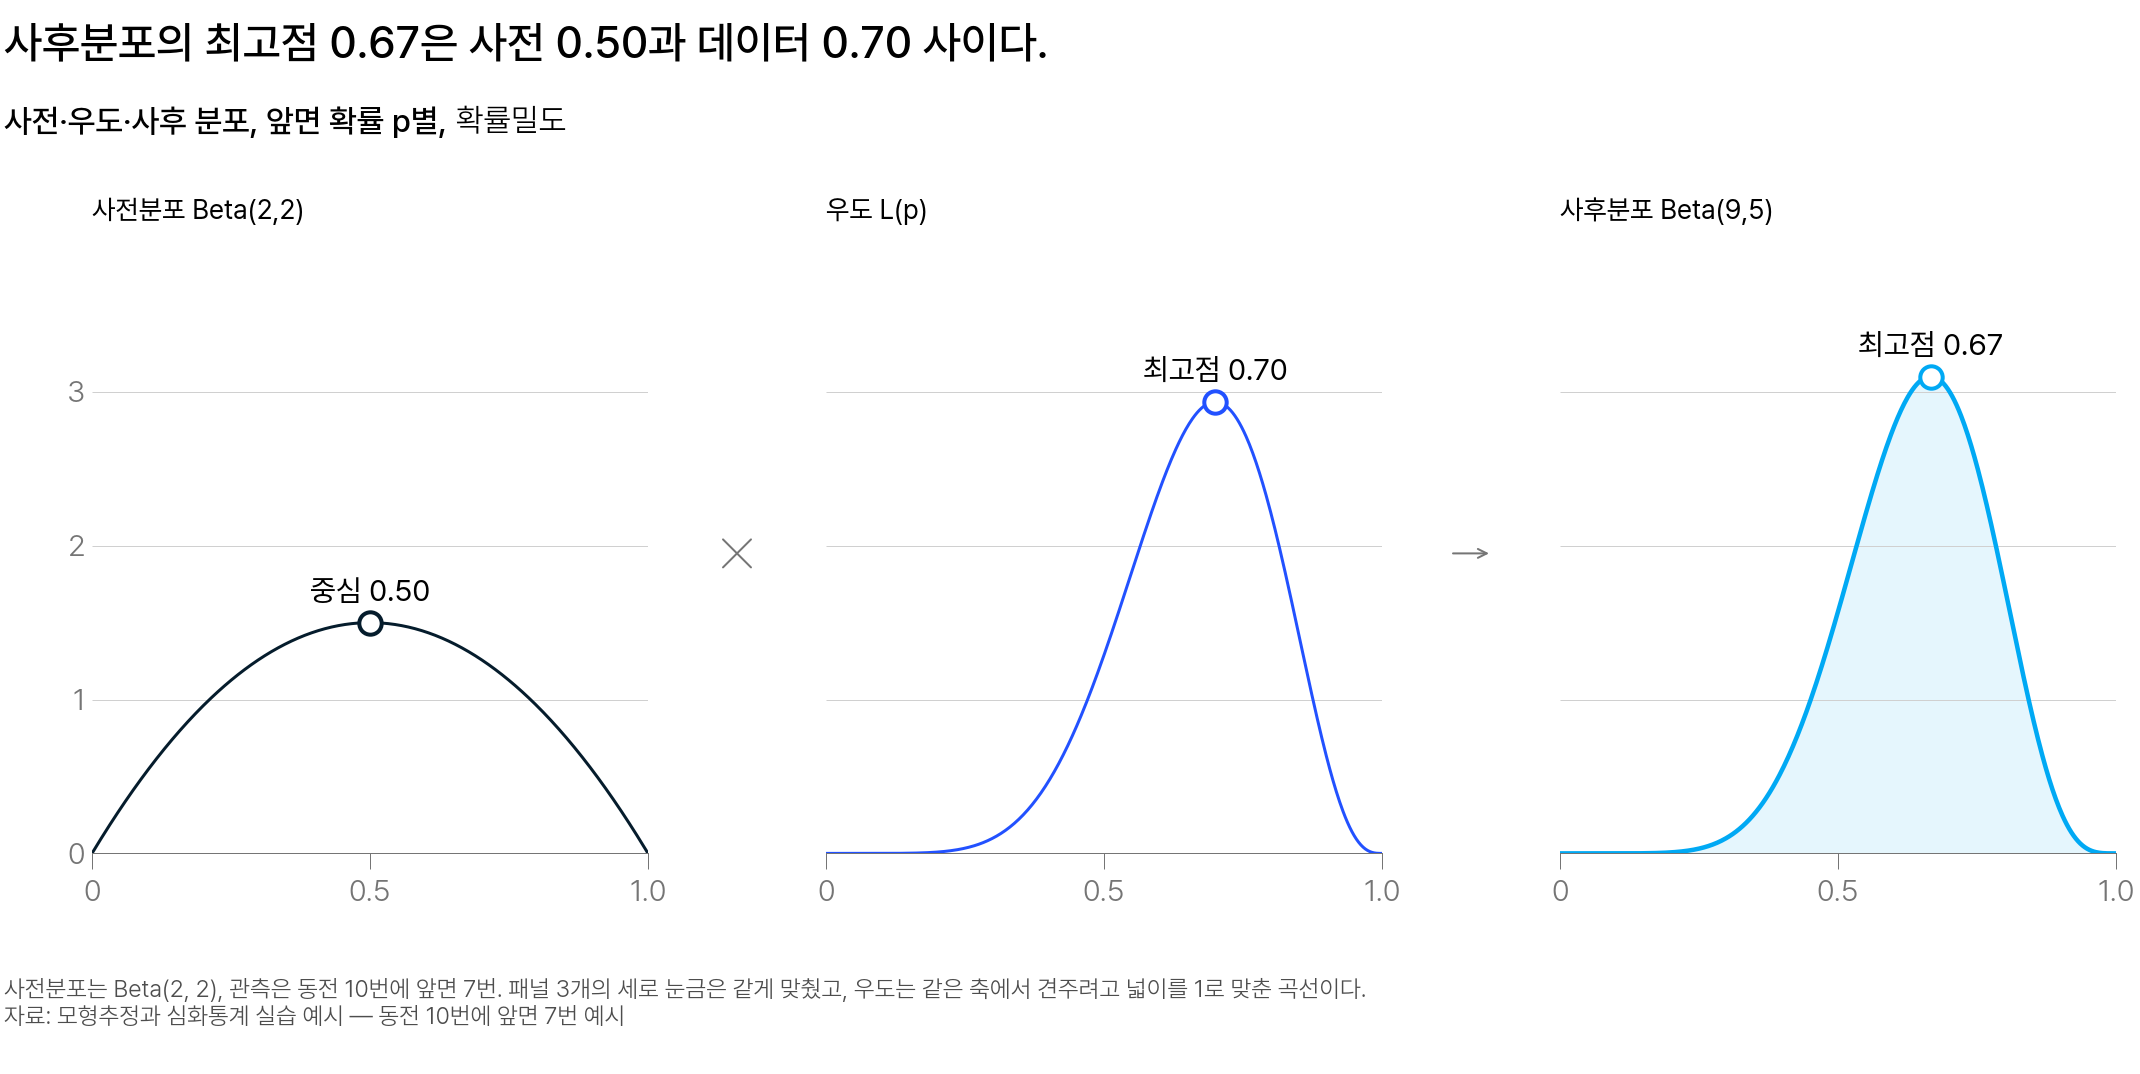

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 사전분포 × 우도 → 사후분포 — 왼쪽 남색 사전분포(중심 p = 0.50)와 가운데 파랑 우도(최댓값 위치 = MLE 0.70)를 곱한 오른쪽 하늘색 사후분포는, 사전분포가 0.5 쪽으로 수축시킨 만큼 0.70 보다 작은 0.67 에서 최빈값을 갖는다</em></p>

예측 탭의 답은 두 번째, 0.50 과 0.70 사이입니다. 데이터만 보면 우도가 최대인 위치, 곧 MLE 는 0.70 입니다. 그런데 왼쪽 남색 사전분포가 0.5 근처에 밀도를 몰아 두었으니, 곱한 결과는 두 값 사이에 놓입니다. **그래서** 사후분포의 최빈값은 **0.67** 입니다.

**수축(shrinkage)** — 관측 수가 적을 때 추정값이 사전분포의 중심 쪽으로 이동하는 현상입니다. 여기서는 0.70 이 0.67 로 이동한 만큼이 그 수축입니다.

갱신 규칙은 덧셈입니다. 관측한 앞면 7회를 모수 $\alpha$ 에 더합니다. 가상 관측 횟수 $\alpha-1$ 이 아니라 모수에 직접 더하는 것입니다.

$$
\alpha_{\text{사후}} = 2 + 7 = 9
$$

뒷면 3회는 $\beta$ 에 더합니다.

$$
\beta_{\text{사후}} = 2 + 3 = 5
$$

오른쪽 패널의 $\text{Beta}(9,5)$ 가 그 결과입니다. 최빈값 공식에 두 모수를 대입합니다.

$$
\frac{9 - 1}{9 + 5 - 2} = \frac{8}{12} = 0.667
$$

- $9-1$ : 가상 앞면 1회에 관측 앞면 7회를 더한 값
- $9+5-2$ : 가상 시행 2회에 관측 시행 10회를 더한 값

**그래서** 최빈값은 (가상 + 관측) ÷ (가상 합 + $n$) 이라는 비율 하나로 읽힙니다.

<details class="lms-extra"><summary>자세히 — 그림의 우도 곡선 2.9 와 계산에 넣는 우도 0.267</summary>

가운데 패널의 파랑 우도 곡선은 패널 3개를 같은 세로축 척도에서 비교하려고 곡선 아래 넓이를 1 로 맞춰 다시 그린 것입니다. 그래서 그림에서 읽는 최댓값이 2.9 입니다. 계산에 넣는 우도는 그 정규화를 하기 전의 값입니다.

$$
P(X \mid p) = \binom{10}{7} p^{7}(1-p)^{3}
$$

- $\binom{10}{7}$ : 10회 중 앞면 7회가 나오는 순서의 경우의 수 120
- $p$ : 앞면 확률 — 추정하려는 모수입니다

$p = 0.70$ 을 대입하면 이 값은 0.267 입니다. 그림에서 읽은 2.9 는 넓이를 1 로 맞춰 다시 그린 곡선의 높이이고, 베이즈 정리에 넣는 값은 0.267 입니다.

이름도 구분해 씁니다. 우도 곡선의 **봉우리**는 최댓값의 **위치**라 MLE 이고, 사후분포의 봉우리는 최빈값(MAP)입니다. 그 위치의 **높이**는 최댓값이라 부릅니다.

</details>

항 4개 중 $P(X)$ 만 아직 숫자가 없습니다. $P(X)$ 는 우도를 사전분포로 가중해 평균 낸 데이터의 확률이라, 사전분포 $\text{Beta}(2,2)$ 에 10번 던져 앞면 7번을 넣으면 $P(X) = 0.1119$ 입니다. 중앙에 밀도를 모은 사전분포라, 균등 사전분포 $\text{Beta}(1,1)$ 에서의 0.0909 보다 큽니다.

$P(X)$ 는 $\theta$ 와 무관한 상수라 곡선의 모양을 바꾸지 않고 넓이만 1 로 맞춥니다. 그래서 앞으로는 1절의 비례식만 쓰고, 분모는 마지막에 한 번 맞추는 값으로 둡니다. MLE 는 값 하나(점 추정)를 냈지만, 베이즈 추정의 산출물은 곡선 전체, 곧 **불확실성을 포함한 분포**입니다.

## 갱신의 반복 — 오늘의 사후분포가 내일의 사전분포

베이즈 추정의 핵심 성질은 **갱신을 반복할 수 있다**는 점입니다. 오늘의 사후분포를 내일의 사전분포 항에 그대로 대입하면 됩니다. 아래 패널 4개가 그 반복입니다 — 참값 0.65 인 동전을 2번 · 5번 · 20번 · 60번까지 던지며 앞 단계의 사후분포를 다음 단계의 사전분포로 넣었습니다.

> **[예측] 모든 값에 같은 밀도를 주는 균등 사전분포에서 출발해 참값 0.65 인 동전을 20번쯤 던지면, 사후분포는 어떤 모습이 될까요?**
>
> 1. 여전히 거의 평평하다 — 20번으로는 아무것도 정하지 못한다
> 2. 봉우리가 생기며 좁아지되, 아직 참값에서 조금 비껴 있다
> 3. 이미 0.65에 뾰족하게 꽂힌다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

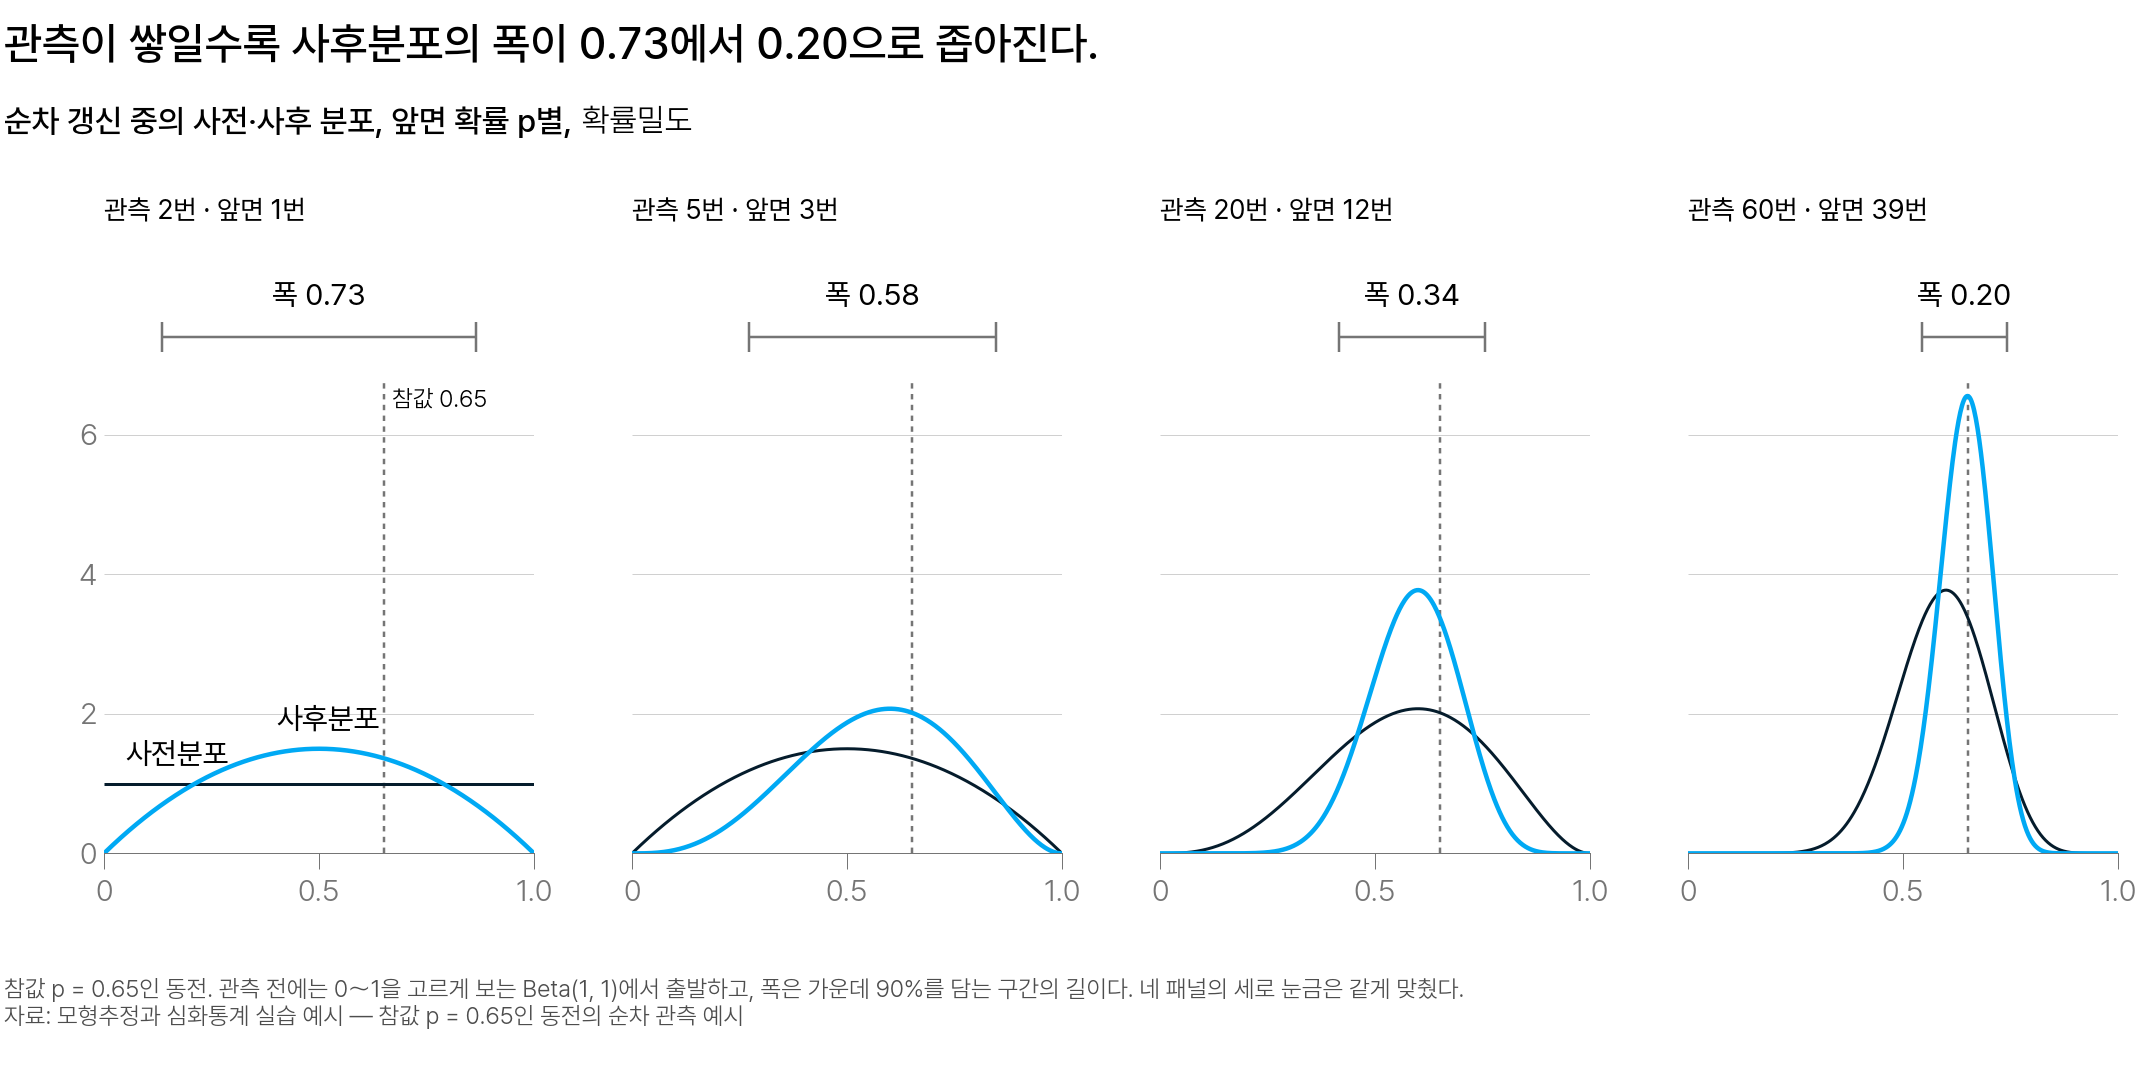

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 순차 갱신 — 가로축은 앞면 확률 p, 세로축은 확률밀도이고, 남색이 그 계산에 들어간 사전분포(첫 패널은 관측 전의 평평한 상태, 이후는 직전 단계의 사후분포) · 하늘색이 갱신된 사후분포 · 세로 회색 점선이 참값 p = 0.65(이름은 첫 패널에만)다. 최빈값이 0.50 → 0.60 → 0.60 → 0.65 로 이동하는 동안 위쪽 회색 막대로 표시한 90% 구간의 길이는 0.73 에서 0.20 으로 짧아진다</em></p>

예측 탭의 답은 두 번째입니다. 20번 시점의 최빈값은 0.60 으로 참값 0.65 와 아직 차이가 있고, 회색 막대로 표시한 구간은 첫 패널의 0.73 에서 0.34 로 이미 절반 이하가 됐습니다.

**최빈값의 위치**와 **사후분포의 산포**는 서로 다른 것을 나타냅니다. 최빈값의 위치를 정하는 것은 데이터의 비율입니다 — 20번 시점은 $12/20 = 0.60$, 60번 시점은 $39/60 = 0.65$ 입니다.

구간 길이를 줄이는 것은 강도 $\alpha+\beta$ 입니다. 5번 시점의 사후분포는 $\text{Beta}(4,3)$ 이라 강도가 7, 20번 시점은 $\text{Beta}(13,9)$ 라 강도가 22 입니다. 관측만 비교하면 4배인데 강도로 비교하면 $22 \div 7 = 3.1$ 배이고, 구간 길이는 0.58 에서 0.34 로 $0.58 \div 0.34 = 1.7$ 배 짧아졌습니다.

**그래서** 관측이 쌓이면 사후분포는 참값 쪽으로 이동하면서 좁아집니다.

<details class="lms-extra"><summary>더 깊이 — 관측 4배에 구간이 2배가 아니라 1.7배만 짧아진 계산</summary>

앞에서 본 $\sqrt{n}$ 규칙대로면 관측 4배에 사후 표준편차 $\sigma_{\text{post}}$ 는 $\sqrt{4} = 2$ 배 작아져야 합니다. 그림에서 읽은 구간 길이의 비는 1.7 배입니다. 차이가 생긴 원인은 사전분포의 강도입니다 — 강도로 계산한 비가 4배가 아니라 3.1배이기 때문입니다.

⑴ 기준이 되는 값은 강도에 1 을 더한 $\alpha+\beta+1$ 입니다. 베타분포의 분산 식에 그 1 이 들어 있습니다.

$$
\operatorname{Var}[p] = \frac{\alpha\beta}{(\alpha+\beta)^2\,(\alpha+\beta+1)}
$$

- $\operatorname{Var}[p]$ : $p$ 의 분산 — 중심에서 얼마나 흩어져 있는지 측정하는 값이고, 그 제곱근이 표준편차입니다
- $\alpha+\beta+1$ : 분모에서 $(\alpha+\beta)^2$ 와 나란히 놓인 항 — 이것 때문에 $\sigma_{\text{post}}$ 는 대략 $\sqrt{\alpha+\beta+1}$ 에 반비례해 작아집니다

⑵ 숫자를 넣습니다. $\alpha+\beta+1$ 은 5번 시점이 $7 + 1 = 8$, 20번 시점이 $22 + 1 = 23$ 입니다. 앞 인자 $\alpha\beta/(\alpha+\beta)^{2}$ 는 두 시점에서 거의 같아 비에서 근사로 지워지고, 남는 것은 $\alpha+\beta+1$ 뿐입니다. 이 항은 분모에 있었으니 비에서는 위아래가 서로 바뀝니다.

$$
\frac{\operatorname{Var}_5}{\operatorname{Var}_{20}} \approx \frac{23}{8}
$$

⑶ 분산의 비에 제곱근을 씌우면 표준편차의 비입니다. 먼저 나눕니다.

$$
\frac{23}{8} = 2.875
$$

제곱근을 씌웁니다.

$$
\sqrt{2.875} = 1.70
$$

그림에서 읽은 1.7 배와 그대로 맞습니다. 강도만 쓴 $\sqrt{22/7} = 1.77$ 배는 조금 크게 계산된 어림값입니다.

⑷ $\sigma_{\text{post}}$ 로 직접 확인해도 같습니다. $\text{Beta}(4,3)$ 은 0.175, $\text{Beta}(13,9)$ 는 0.103 이라 $0.175 \div 0.103 = 1.71$ 이고, ⑶ 의 1.70 과 소수 둘째 자리에서만 다릅니다.

</details>

그림의 회색 막대로 표시한 구간을 3절에서 **신용구간**이라고 부릅니다. 같은 구간이고, 자른 비율만 95% 가 아니라 90% 입니다.

요약값이 하나 더 필요합니다. **사후 평균(posterior mean)** — 사후분포의 기댓값입니다. $\text{Beta}(a,b)$ 에서는 $a/(a+b)$ 로 계산하고, 최빈값과는 조금 다른 위치에 옵니다. 아래 위젯 오른쪽에 그 값이 함께 뜹니다.

### [직접 해보기] 데이터가 쌓일수록 사후분포가 참값으로 좁아지는 과정

이번에는 갱신을 **직접 조작**합니다.

1. **조작.** `동전 던지기` 와 `10번 던지기` 로 데이터를 쌓고, `사전의 확신` 슬라이더를 `약함` 과 `강함` 사이에서 옮겨 보세요. 슬라이더는 이미 던진 횟수를 지우지 않으니, 두 경우를 비교할 때는 `리셋` 으로 0 부터 다시 시작합니다.
2. **관찰.** 곡선은 3개입니다 — 남색 `사전분포 (던지기 전)`, 파랑 `우도 (지금까지 나온 앞·뒤)`, 둘을 곱한 하늘색 `사후분포 = 사전분포 × 우도`. 확신을 강하게 둘수록 사후분포가 사전분포 쪽으로 수축하고, 던질수록 좁아지며 `진짜 앞면 확률`(회색 점선)로 수렴합니다. `사전의 확신` 옆에 뜨는 Beta 의 두 숫자를 더한 값이 사전분포의 강도(유효 표본 수)입니다 — 처음 화면은 `약함` 의 Beta(1.9, 1.9) 라 강도 3.8, 오른쪽 끝은 `강함` 의 Beta(6.0, 6.0) 이라 강도 12 입니다. 최빈값은 하늘색 곡선이 가장 높은 위치로 읽으세요. 오른쪽 `사후 평균` 은 곡선의 기댓값이라 조금 다르게 뜹니다.
3. **확인 질문.** `리셋` 을 누르고(`동전의 진짜 앞면 확률` 은 `0.70` 그대로 둡니다), `사전의 확신` 을 오른쪽 끝으로 옮겨 Beta(6.0, 6.0) 으로 두세요. `10번 던지기` 를 한 번만 누르면 최빈값이 0.70 이 될까요, 그보다 작을까요? 그보다 작다면 0.5 쪽일까요, 0.7 쪽일까요, 아니면 둘의 중간일까요? 던지기는 난수라 화면마다 앞면 수가 다르니, 곡선 아래 집계 표시란에 뜬 **자기 화면의 앞면 수**로 맞춰 보세요.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/bayes-lab.html?trueP=0.7&priorPct=18", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — Beta(6,6) 사전분포에 10회 시행 뒤 최빈값의 위치</summary>

10번에 앞면 7번이 나온 흔한 화면이라면, 최빈값은 0.70 이 되지 못합니다. 0.5 와 0.7 중 어느 한쪽으로 치우치지도 않습니다. 사전분포의 중심 0.50 과 데이터의 앞면 비율 0.70 의 정확히 중간인 **0.60** 입니다. 그 화면의 숫자는 사후 평균 0.59, 최빈값은 0.60 입니다.

최빈값이 데이터의 0.70 에 이르지 못한 이유는 사전분포의 가상 관측 횟수입니다. $\text{Beta}(6,6)$ 은 앞면 5회·뒷면 5회, 곧 가상 관측 10회입니다. 실제 관측도 10회라 두 횟수가 같고, 그래서 최빈값은 어느 쪽으로도 치우치지 않고 두 중심의 중간인 $(0.50 + 0.70) \div 2 = 0.60$ 이 됩니다.

앞면이 9번 이상 나온 화면도 10번에 1～2번은 나옵니다(참값 0.70 · 10번 기준 약 15%). 그때는 최빈값이 0.70 이상이 됩니다. $\text{Beta}(6,6)$ 에 10번 던져 앞면이 $k$ 번 나오면 사후분포는 $\text{Beta}(6+k,\; 16-k)$ 이고, 최빈값 공식에 그 두 모수를 넣습니다.

$$
\frac{(6+k)-1}{(6+k)+(16-k)-2}
$$

분자와 분모를 각각 정리합니다. 분모에서 $+k$ 와 $-k$ 가 서로 지워져 20 만 남습니다.

$$
\frac{5+k}{20}
$$

$k$ 에 5·7·9 를 차례로 넣으면 최빈값이 0.50 · 0.60 · 0.70 입니다.

그리고 `강함` 은 한 점이 아니라 슬라이더 오른쪽 구간 전체에 부여된 이름입니다. 끝까지 옮기지 않았다면 화면에 뜬 Beta 의 숫자로 계산하는 편이 안전합니다.

</details>

방금 한 계산을 식으로 정리합니다. 사후분포의 최빈값은 **가상 앞면 수에 관측 앞면 수를 더한 값**을 **가상 총 횟수에 관측 횟수를 더한 값**으로 나눈 값입니다.

$$
\text{사후분포의 최빈값} = \frac{(\alpha - 1) + k}{(\alpha - 1) + (\beta - 1) + n}
$$

- $\alpha - 1$, $\beta - 1$ : 사전분포의 가상 앞면 수와 가상 뒷면 수 — $\text{Beta}(6,6)$ 이면 5회와 5회입니다
- $k$, $n$ : 이번에 실제로 관측한 앞면 수와 던진 횟수

$\text{Beta}(6,6)$ 에 10번 던져 앞면 7번을 넣으면 $(5 + 7) \div (10 + 10) = 0.60$ — 사전분포의 0.50 과 데이터의 0.70 의 정확히 중간입니다. 가상 관측 10회와 실제 관측 10회가 같기 때문입니다.

## 사전분포의 비중 — 관측이 늘면 작아진다

MAP 가 사전분포 쪽으로 얼마나 수축하는지를 정하는 값은 **가상 관측 수** $\nu$ 이고, 그 $\nu$ 가 관측 $n$ 과 비교해 얼마나 큰지가 **사전분포의 비중**입니다.

$$
\text{사전분포의 비중(최빈값 기준)} = \frac{\nu}{\nu+n}, \qquad \nu = (\alpha-1) + (\beta-1)
$$

- $\nu$ : 가상 관측 수 — 최빈값 공식에 들어가는 가상 성공 $\alpha-1$ 회와 가상 실패 $\beta-1$ 회의 합
- $n$ : 이번에 실제로 관측한 횟수

**강도 $\alpha+\beta = \nu+2$ 는 다른 양을 말합니다.** 강도는 사후분포의 표준편차, 곧 산포를 정하는 크기이고, 산포를 기준으로 한 비중은 $(\alpha+\beta)/(\alpha+\beta+n)$ 입니다. 두 비중은 2 만큼 다르고, $n$ 이 커지면 그 차이는 무시할 수 있습니다.

균등 사전분포 $\text{Beta}(1,1)$ 은 $\nu = 0$ 이라 최빈값 기준 비중이 0 입니다 — 최빈값을 정하는 것은 데이터뿐입니다. 산포 기준으로는 강도가 2 라, 동전을 7번 던졌다면 $n = 7$ 이라 $2/(2+7) = 2/9$ 이고, 200번 던졌다면 $2/202$ 라 100분의 1 남짓입니다. 나머지가 데이터의 비중이라, 위젯 화면의 **데이터 가중치** $w = n/(\alpha+\beta+n)$ 가 그 값입니다. **그래서** 관측이 많아지면 사후분포의 산포는 어제 본 $1/\sqrt{n}$ 규칙에 가까워집니다.

<details class="lms-extra"><summary>더 깊이 — 사전분포의 강도와 비중, 중심이 참값과 다를 때</summary>

**⑴ 같은 곡선을 「가상 관측 0회」라고도, 「강도 2」라고도 합니다.** $\text{Beta}(1,1)$ 은 $\alpha-1 = 0$·$\beta-1 = 0$ 이라 가상 관측이 0회이고, $\alpha+\beta = 2$ 라 강도는 2 입니다. 어긋나 보이지만 두 말이 측정하는 양이 다릅니다 — 가상 관측은 최빈값을 어느 쪽으로 옮기는지(**위치**)를 정하고, 강도는 곡선이 얼마나 좁은지(**산포**)를 정합니다. 어느 값도 선호하지 않는 곡선이라 위치는 0 이지만, 정의역이 0～1 이라 산포는 유한합니다. 참값이 3 이나 −5 일 가능성은 처음부터 0 으로 두고 있기 때문입니다.

**⑵ 방향이 어긋난 예.** 참값 0.70 인 동전에 $\text{Beta}(6,6)$ 을 두면 10회 관측 뒤 최빈값이 $(5+7) \div (10+10) = 0.60$ 입니다. 균등 사전분포였다면 0.70 입니다. 사전 중심이 참값과 다르면 관측 $n$ 이 가상 관측 수 $\nu$ 를 넘어설 때까지 그 차이가 남습니다 — 최빈값 식에서 $(\alpha-1)$ 과 $(\beta-1)$ 이 $k$ 와 $n$ 을 압도하는 구간입니다.

**⑶ 강도를 얼마로 둘지는 사람이 정합니다.** 여기가 베이즈 추정에서 판단이 들어가는 유일한 단계입니다. 그래서 실무에서는 사전분포를 2～3개 바꿔 가며 결론이 달라지는지 확인합니다(민감도 확인). 결론이 사전분포에 따라 달라진다면, 그 데이터로는 아직 결론을 낼 수 없다는 뜻입니다.

</details>

#### 핵심 주의점

$\text{Beta}(6,6)$ 의 「가상 관측 10회」와 「강도 12」를 같은 수로 읽으면 안 됩니다.

$$
\text{가상 관측} = (\alpha-1) + (\beta-1) = 10, \qquad \text{강도} = \alpha + \beta = 12
$$

앞은 최빈값을 옮기는 위치의 양이고, 뒤는 곡선의 좁기를 정하는 산포의 양입니다. 두 수가 2 만큼 다른 것은 최빈값 공식이 분자에서 1 을, 분모에서 2 를 빼기 때문입니다.

정확한 뜻은 다음과 같습니다.

> **$\text{Beta}(6,6)$ 은 앞면 5회·뒷면 5회를 미리 관측한 것과 같고(가상 관측 10회), 곡선의 좁기를 정하는 강도는 12 다.**

> 사전분포는 데이터와 경쟁하는 항이 아니라, 관측이 적을 때 추정값이 구간의 끝점 0 이나 1 로 가지 않게 제한하는 항입니다.

> **[문제] 관측이 3배로 늘면 최빈값은 어디까지 이동하나**
>
> 위젯에서 `사전의 확신` 을 오른쪽 끝으로 옮기면 나오는 사전분포 $\text{Beta}(6,6)$ 을 그대로 두고, 이번에는 동전을 30번 던져 앞면 24번을 관측했다고 해 봅시다. 사후분포의 최빈값은 어떤 값일까요?
>
> 1. 0.50 — 사전의 중심
> 2. 0.65 — 사전의 중심과 데이터의 한가운데
> 3. 0.725 — 한가운데와 데이터 사이
> 4. 0.80 — 데이터의 앞면 비율

## 3절 켤레 — 적분 없이 덧셈으로

## 켤레 — 같은 분포족이면 갱신이 덧셈이 된다

**이 절에서 할 일**

1. 베타분포에 이항 우도를 곱하면 왜 다시 베타분포가 되는지 지수 덧셈 하나로 확인합니다.
2. 그 성질 덕분에 갱신이 덧셈 2회로 끝나는 것을 확인하고, 우도마다 짝이 되는 사전분포를 목록으로 봅니다.
3. 사후분포를 값 하나(**MAP**)와 구간 하나(**신용구간**)로 보고합니다.

2절에서는 $p$ 후보를 촘촘히 늘어놓고 곡선끼리 곱했습니다. 사전분포를 베타로 두면 그 곱셈을 하지 않아도 됩니다. 밑이 같은 거듭제곱끼리는 지수가 더해지기 때문입니다.

$$
\underbrace{p^{k}(1-p)^{n-k}}_{\text{이항 우도}} \times \underbrace{p^{\alpha_0-1}(1-p)^{\beta_0-1}}_{\text{사전 Beta}} \;=\; p^{\alpha_0+k-1}(1-p)^{\beta_0+n-k-1}
$$

- $k$, $n$ : 관측한 성공 횟수와 전체 시행 횟수
- $\alpha_0$, $\beta_0$ : 사전분포의 두 모수 — 데이터를 보기 *전*이라는 뜻으로 아래첨자 0 으로 표기합니다

오른쪽도 $p^{a-1}(1-p)^{b-1}$ 형태라 다시 베타분포입니다. 지수를 대조하면 $a = \alpha_0+k$, $b = \beta_0+n-k$ 입니다.

**켤레 사전분포(conjugate prior)** — 사후분포가 사전분포와 같은 분포족으로 남는 사전분포입니다. 갱신이 모수 덧셈으로 끝납니다.

$$
\text{Beta}(\alpha_0, \beta_0) + \text{데이터}(k\text{번 성공},\, n-k\text{번 실패}) \;\longrightarrow\; \text{Beta}(\alpha_0 + k,\; \beta_0 + n - k)
$$

사전분포 $\text{Beta}(2,2)$ 에 앞면 7회·뒷면 3회를 대입합니다. $\alpha_0 + k = 2 + 7 = 9$ 이고 $\beta_0 + n - k = 2 + 3 = 5$ 라 사후분포는 $\text{Beta}(9,5)$ 입니다. 2절 그림에서 읽은 최빈값 0.67 이 이 사후분포의 최빈값 $8/12 \approx 0.667$ 입니다.

**그래서** 적분도 격자도 없이, 모수 2개에 관측 횟수를 더하는 것으로 갱신이 끝납니다.

## 켤레 짝 목록 — 포아송의 짝은 감마분포

동전의 $p$ 에는 베타분포가 맞지만, 포아송의 $\lambda$ 는 0 보다 크고 상한이 없어 베타분포로는 표현할 수 없습니다. 어제 4절에서 시간당 통화 건수를 집계하던 콜센터 예시가 그런 경우입니다.

**감마분포(Gamma distribution)** — 0 보다 큰 값에서 정의되는 분포족입니다. $\text{Gamma}(\alpha_0, \beta_0)$ 라 적고, 포아송의 $\lambda$ 처럼 양수인 모수의 사전분포로 씁니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Gamma_distribution_pdf.svg" width="640" height="480"/>
<p align="center"><em>▲ 감마분포 — 곡선에 표시된 (k, θ)는 이 그림의 표기이고 우리 표기와는 k = α₀, θ = 1/β₀ 으로 대응한다. θ 가 2.0 으로 같은 곡선 3개(빨강 k=1, 주황 k=2, 노랑 k=3)는 최빈값이 0 → 2 → 4 로 이동한다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia</span></p>

우도마다 짝이 되는 사전분포가 정해져 있습니다.

| 데이터(우도) | 켤레 사전분포 | 사후 갱신 |
|---|---|---|
| 베르누이/이항 ($k$ 성공, $n-k$ 실패) | $\text{Beta}(\alpha_0,\beta_0)$ | $\text{Beta}(\alpha_0+k,\ \beta_0+n-k)$ |
| 포아송 ($n$개 관측, 합 $\sum_i x_i$) | $\text{Gamma}(\alpha_0,\beta_0)$ | $\text{Gamma}(\alpha_0+\sum x_i,\ \beta_0+n)$ |

감마 사전분포의 두 숫자도 베타와 같은 방식으로 구분해 읽습니다. 중심은 최빈값 $(\alpha_0-1)/\beta_0$ 이고, 강도는 $\beta_0$ 입니다.

- $\alpha_0$ : 가상 사건 수 + 1 — 중심을 정하는 쪽입니다
- $\beta_0$ : 미리 관측해 둔 **가상 기간**(년) — 이 값이 감마 사전분포의 강도(유효 표본 수)이고, 기간이라 4절의 노출 $E$ 와 단위가 같습니다

중심을 $\lambda_0$ 에 맞추려면 $\alpha_0 = 1 + \lambda_0\beta_0$ 로 둡니다. 최빈값 식에 넣으면 $\alpha_0 - 1 = \lambda_0\beta_0$ 이고 그것을 $\beta_0$ 로 나누면 $\lambda_0$ 이 되기 때문입니다.

5시간의 통화 기록 [3, 2, 4, 3, 5](합 17)에 사전분포 $\text{Gamma}(2,1)$ 을 적용하면 사후분포는 $\text{Gamma}(2+17,\ 1+5) = \text{Gamma}(19,6)$ 이고, 최빈값은 $(19-1)/6 = 3.0$ 통/시간입니다. 표본평균(MLE) 3.400 이 사전분포의 중심 1.0 쪽으로 0.4 만큼 수축한 값입니다.

**그래서** 짝을 맞춰 두면 갱신이 표 오른쪽 열의 덧셈으로 끝납니다. 감마-포아송을 실제 계약 데이터에 적용하는 것은 5절입니다.

<details class="lms-extra"><summary>더 깊이 — 감마 최빈값 (α−1)/β 가 나오는 과정</summary>

감마 밀도는 $\lambda^{\alpha-1} e^{-\beta\lambda}$ 에 비례합니다. 최빈값을 구하는 절차는 베타분포와 같습니다.

**⑴ 밀도에 로그를 씌웁니다.** 로그가 곱을 합으로 바꾸고 지수를 항으로 꺼냅니다. 뒤쪽은 $\log e^{-\beta\lambda} = -\beta\lambda$ 입니다.

$$
\ell(\lambda) = (\alpha-1)\log\lambda - \beta\lambda
$$

**⑵ $\lambda$ 로 미분합니다.** $\dfrac{d}{d\lambda}\log\lambda = \dfrac{1}{\lambda}$ 이고 $\dfrac{d}{d\lambda}(-\beta\lambda) = -\beta$ 입니다.

$$
\frac{d\ell}{d\lambda} = \frac{\alpha-1}{\lambda} - \beta
$$

**⑶ 0 으로 놓습니다.** 최빈값에서는 접선이 수평이기 때문입니다.

$$
\frac{\alpha-1}{\lambda} - \beta = 0
$$

**⑷ 양변에 $\lambda$ 를 곱해 분모를 없앱니다.**

$$
\alpha - 1 - \beta\lambda = 0
$$

$\beta\lambda$ 를 오른쪽으로 넘깁니다.

$$
\alpha - 1 = \beta\lambda
$$

양변을 $\beta$ 로 나눕니다.

$$
\lambda = \frac{\alpha-1}{\beta}
$$

**⑸ 숫자로 검산합니다.** 사후분포 $\text{Gamma}(19,6)$ 의 $\alpha$ 에 19 를, $\beta$ 에 6 을 넣으면 $(19-1) \div 6 = 3.0$ 통/시간입니다.

감마분포의 평균은 $\alpha/\beta$ 라 $\text{Gamma}(19,6)$ 의 평균은 $19/6 \approx 3.17$ 통/시간으로 최빈값 3.0 보다 위입니다. 통화량은 아래로는 0 에서 막히고 위로는 열려 있어 곡선이 오른쪽으로 길게 늘어지는데, 그 꼬리가 기댓값을 최빈값보다 오른쪽으로 이동시킵니다.

</details>

## MAP — 사후분포의 최빈값

베이즈 추정의 산출물은 분포인데, 보고서를 받는 쪽에서는 추정값 하나를 요구하는 경우가 많습니다.

**최대사후확률 추정(MAP, Maximum A Posteriori)** — 사후분포의 밀도가 최대가 되는 모수값을 추정값으로 쓰는 방법입니다. 기호로는 $\hat{\theta}_{\text{MAP}}$ 이라 적고, 그 값을 가리키는 정식 용어가 **최빈값(mode)** 입니다.

$$
\hat{\theta}_{\text{MAP}} = \operatorname{argmax}_{\theta}\; P(\theta \mid X) = \operatorname{argmax}_{\theta}\; P(X \mid \theta)\, P(\theta)
$$

- $\theta$ : 추정하려는 모수 — 동전이면 $p$, 콜센터라면 $\lambda$
- $P(X \mid \theta)$ : 우도 — 모수 후보마다 매긴 데이터의 그럴듯함 점수(어제 2절)
- $P(\theta)$ : 사전분포 — 데이터를 보기 전의 사전 정보(1절)
- 두 번째 등호 : 분모 $P(X)$ 가 상수라 최빈값의 **위치**를 바꾸지 못해 지운 것

$P(\theta)$ 만 지우면 MLE 입니다. **그래서** MAP 는 사전분포를 곱한 MLE 입니다.

## 베타-베르누이 MAP 공식 — 「3회 중 3회 앞면」의 재계산

베타 사후분포의 최빈값에는 공식이 있습니다. $\text{Beta}(a, b)$ 의 최빈값이 $\dfrac{a-1}{a+b-2}$ ($a, b > 1$) 이니, 사후분포 $\text{Beta}(\alpha_0+k,\; \beta_0+n-k)$ 를 대입하면 이렇게 됩니다.

$$
\hat{p}_{\text{MAP}} = \frac{\alpha_0 + k - 1}{\alpha_0 + \beta_0 + n - 2}
$$

- $k$ : 실제 성공 횟수
- $n$ : 전체 시행 횟수
- $\alpha_0,\ \beta_0$ : 사전분포의 가상 성공·실패 횟수에 각각 1 을 더한 값

<details class="lms-extra"><summary>자세히 — 밀도를 로그 미분해 (a−1)/(a+b−2) 가 나오는 과정과 조건 a, b > 1</summary>

$\text{Beta}(a,b)$ 의 최빈값 공식이 어디서 나오는지 밀도를 직접 미분해 봅니다. 어제 3절 베르누이 MLE 와 유도 절차가 같습니다.

**⑴ 밀도에 로그를 씌웁니다.** 밀도는 $p^{a-1}(1-p)^{b-1}$ 에 비례하니, 로그가 곱을 합으로 바꾸고 지수를 앞으로 내립니다. 상수 $B(a,b)$ 는 $p$ 와 무관해 미분에서 사라집니다.

$$
\ell(p) = (a-1)\log p + (b-1)\log(1-p)
$$

**⑵ $p$ 로 미분합니다.** $\frac{d}{dp}\log p = \frac{1}{p}$ 이고 $\frac{d}{dp}\log(1-p) = -\frac{1}{1-p}$ 입니다.

$$
\frac{d\ell}{dp} = \frac{a-1}{p} - \frac{b-1}{1-p}
$$

**⑶ 0 으로 놓습니다.** 최빈값에서는 접선이 수평이기 때문입니다.

$$
\frac{a-1}{p} = \frac{b-1}{1-p}
$$

**⑷ 양변에 $p(1-p)$ 를 곱해 분모를 없앱니다.**

$$
(a-1)(1-p) = (b-1)\,p
$$

왼쪽 괄호를 풀면 이렇게 됩니다.

$$
a-1-(a-1)p = (b-1)p
$$

양변에 $(a-1)p$ 를 더하면 $p$ 가 오른쪽에 모입니다.

$$
a-1 = (b-1)p + (a-1)p = (a+b-2)\,p
$$

양변을 $a+b-2$ 로 나누면 답입니다.

$$
p = \frac{a-1}{a+b-2}
$$

**⑸ 이 값이 최빈값인지, 그리고 조건 $a, b > 1$ 이 무엇을 막는지 확인합니다.** 2차 미분은 $\ell''(p) = -\dfrac{a-1}{p^{2}} - \dfrac{b-1}{(1-p)^{2}}$ 인데, $a, b > 1$ 이면 두 항 모두 음수라 곡선이 구간 전체에서 아래로 굽습니다. 기울기가 0 인 $p$ 값이 하나뿐이고 그 값이 최빈값(밀도가 최대인 위치)입니다. $a = 1$ 이면 $\log p$ 항이 전부 사라져 최빈값이 곡선 안쪽이 아니라 끝점 $p = 0$ 으로 이동합니다 — 조건 $a, b > 1$ 을 명시한 이유가 이것입니다.

이 조건은 사후분포에서도 그대로 적용됩니다. $0 < k < n$ 이면 두 모수가 저절로 1 보다 커서 공식이 그대로 통하고, $k = n$ 같은 극단에서만 최빈값이 끝점 $p = 1$ 로 이동합니다. 실행 카드 가운데 표의 $\text{Beta}(1,1)$ 행 MAP 1.000 이 그 경우입니다.

**⑹ 숫자로 검산합니다.** 사후분포 $\text{Beta}(9,5)$ 에 넣으면 $\frac{9-1}{9+5-2} = \frac{8}{12} \approx 0.667$ 이고, 실행 카드가 격자로 계산한 최빈값 0.6670 과 같은 값입니다.

짝이 되는 요약값 $a/(a+b)$ 는 최빈값이 아니라 **베타분포의 평균 공식**이고, 이쪽은 $a, b > 0$ 이면 언제나 쓸 수 있습니다.

</details>

이 공식이 격자에서 직접 곱한 값과 맞는지, 그리고 MLE 가 1.0 을 산출했던 그 사례에서 어떤 값이 되는지 실행 카드로 대조합니다.

##### 덧셈 2회가 맞는지 — 격자 계산과 대조하기

아래 실행 카드가 격자에서 직접 곱한 사후분포와 켤레 공식을 대조하고, 사전분포의 강도와 표본 크기의 효과까지 표 2개로 출력합니다.

> **[예측] 동전 3번에 3번 앞면이라 MLE 는 1.0 이었습니다. Beta(2,2) 사전분포를 곱해 최빈값을 다시 계산하면 어떤 값이 될까요?**
>
> 1. 1.0 그대로
> 2. 0.5 쪽으로 조금 내려온다
> 3. 0.5 까지 내려온다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

In [ ]:
# 켤레 공식은 격자 계산과 같은 답을 주나 - 그리고 사전의 무게 · 표본 크기의 효과
import numpy as np

p = np.linspace(0, 1, 1001)          # p 후보 1,001칸
dp = p[1] - p[0]
a0, b0 = 2, 2                        # 사전 Beta(2,2)


def posterior(k, n):
    """사전 Beta(2,2) x 우도를 격자에서 곱한 뒤 전체 넓이를 1로 맞춘 사후 밀도"""
    post = p**(a0 + k - 1) * (1 - p)**(b0 + n - k - 1)
    return post / (post.sum() * dp)


def map_beta(a, b, k, n):
    """Beta(a,b) 사전 + 앞면 k / 전체 n -> 사후 최빈값(MAP)"""
    return (a + k - 1) / (a + b + n - 2)


post = posterior(7, 10)
a, b = a0 + 7, b0 + 3                # 켤레 공식이 예고한 사후 Beta(9,5)
print(f"격자로 구한 사후 봉우리 : {p[np.argmax(post)]:.4f}")
print(f"공식 (a-1)/(a+b-2)      : {(a - 1) / (a + b - 2):.4f}")
print(f"격자로 구한 사후 평균   : {float(np.sum(p * post) * dp):.4f}")
print(f"공식 a/(a+b)            : {a / (a + b):.4f}")

print()
print("동전 3번에 3번 앞면 - MLE 는 1.000")
print("  사전 Beta(a,b) | 가상 관측 |  MAP")
for pa, pb in [(1, 1), (2, 2), (5, 5), (20, 20)]:
    print(f"    Beta({pa:>2},{pb:>2})   |   {pa + pb - 2:>3}회   | {map_beta(pa, pb, 3, 3):.3f}")

print()
print("같은 70% 비율에서 관측만 4배씩 늘리면 (사전 Beta(2,2) 고정)")
print("  관측 n |  MLE   |  MAP   | 사후 중앙 90% 구간 폭")
for k, n in [(7, 10), (28, 40), (112, 160), (448, 640)]:
    q = posterior(k, n)
    cdf = np.cumsum(q) * dp
    lo, hi = p[np.searchsorted(cdf, 0.05)], p[np.searchsorted(cdf, 0.95)]
    print(f"  {n:>6} | {k / n:.4f} | {map_beta(a0, b0, k, n):.4f} |  {hi - lo:.3f}")

#### 결과 해석

카드를 실행하면 행 4개와 표 2개가 차례로 출력됩니다. 격자로 직접 곱해 구한 값과 켤레 공식값이 짝을 이룹니다 — 최빈값은 0.6670 과 0.6667, 평균은 2절에서 정의한 사후 평균 $a/(a+b) = 9/14$ 까지 0.6429 로 같고 차이는 반올림뿐입니다.

예측 탭의 답은 두 번째, 0.5 쪽으로 조금 내려온다 — 가운데 표의 $\text{Beta}(2,2)$ 행이 0.800 입니다. 값이 왜 0.800 인지는 바로 위 MAP 공식에 넣어 확인합니다. 아래 표는 반대쪽이라, 사전분포는 그대로 두고 관측을 10 에서 640 으로 늘리면 MAP 가 MLE 0.7000 에 수렴합니다.

**그래서** 추정값이 수축하는 정도는 사전분포의 강도와 실제 관측 수의 비로 정해지고, 관측이 많아지면 MLE 와 MAP 가 같은 값으로 수렴합니다.

<details class="lms-extra"><summary>더 깊이 — 표 2개로 보는 사전분포의 강도와 중심</summary>

**⑴ 가운데 표는 사전분포의 강도가 하는 일입니다.** 앞면 3번에 3번이라 MLE 는 1.000 인데, 강도 2(가상 관측 0회)인 $\text{Beta}(1,1)$ 에서는 MAP 도 1.000, 강도 4(가상 관측 2회)인 $\text{Beta}(2,2)$ 에서는 0.800, 강도 40(가상 관측 38회)인 $\text{Beta}(20,20)$ 에서는 0.537 입니다.

**⑵ 아래 표는 반대쪽입니다.** 같은 70% 비율에서 관측이 10 → 640 으로 늘면 MAP 는 0.6667 → 0.6994 로 MLE 0.7000 에 수렴하고, 사후분포 가운데 90% 구간 길이는 0.407 에서 0.059 로 줄어듭니다. 사전분포의 강도는 그대로인데 관측 $n$ 이 커져 비중이 뒤바뀐 것입니다.

**⑶ 수축 방향은 강도가 아니라 사전 중심이 정합니다.** ⑴ 에서 MAP 가 1.000 에서 0.537 로 감소한 것을 보면 "사전분포는 값을 낮춘다"고 읽기 쉬운데, 그렇지 않습니다. 같은 $\text{Beta}(20,20)$ 사전분포에 앞면이 0/3 이었다면 MLE 는 0.000 이고 MAP 는 $\frac{20+0-1}{20+20+3-2} = \frac{19}{41} \approx 0.463$ 이라, 이번에는 사전분포가 값을 **증가**시킵니다. 중심 0.5 가 양쪽 극단을 모두 0.5 쪽으로 수축시키는 것입니다.

**⑷ 중심과 강도는 따로 고릅니다.** 사전 평균은 $\alpha_0/(\alpha_0+\beta_0)$ 이고 강도는 $\alpha_0+\beta_0$ 입니다. 중심 0.5 를 유지한 채 강도만 키우려면 $\text{Beta}(2,2) \to \text{Beta}(20,20)$ 처럼 두 모수를 같이 키우고, 중심을 0.05 쪽으로 옮기려면 $\text{Beta}(6,96)$ 처럼 한쪽을 크게 둡니다. 이 절 끝의 요율표 예시가 그 경우입니다.

**⑸ 보고할 값은 최빈값인가 평균인가.** "가장 그럴듯한 한 값"이면 최빈값(MAP)이고, "이 곡선을 값 하나로 요약"하려면 평균입니다. 5절에서 두 지역을 비교할 때는 평균을 사용합니다. 관측이 쌓여 곡선이 대칭에 가까워지면 두 값은 가까워집니다.

</details>

그 행 4개를 그림으로도 나타냅니다. 가로축은 앞면 확률 $p$ 이고, 행마다 표시한 점이 MAP, 좌우로 뻗은 구간 막대가 사후분포의 가운데 90% 구간입니다.

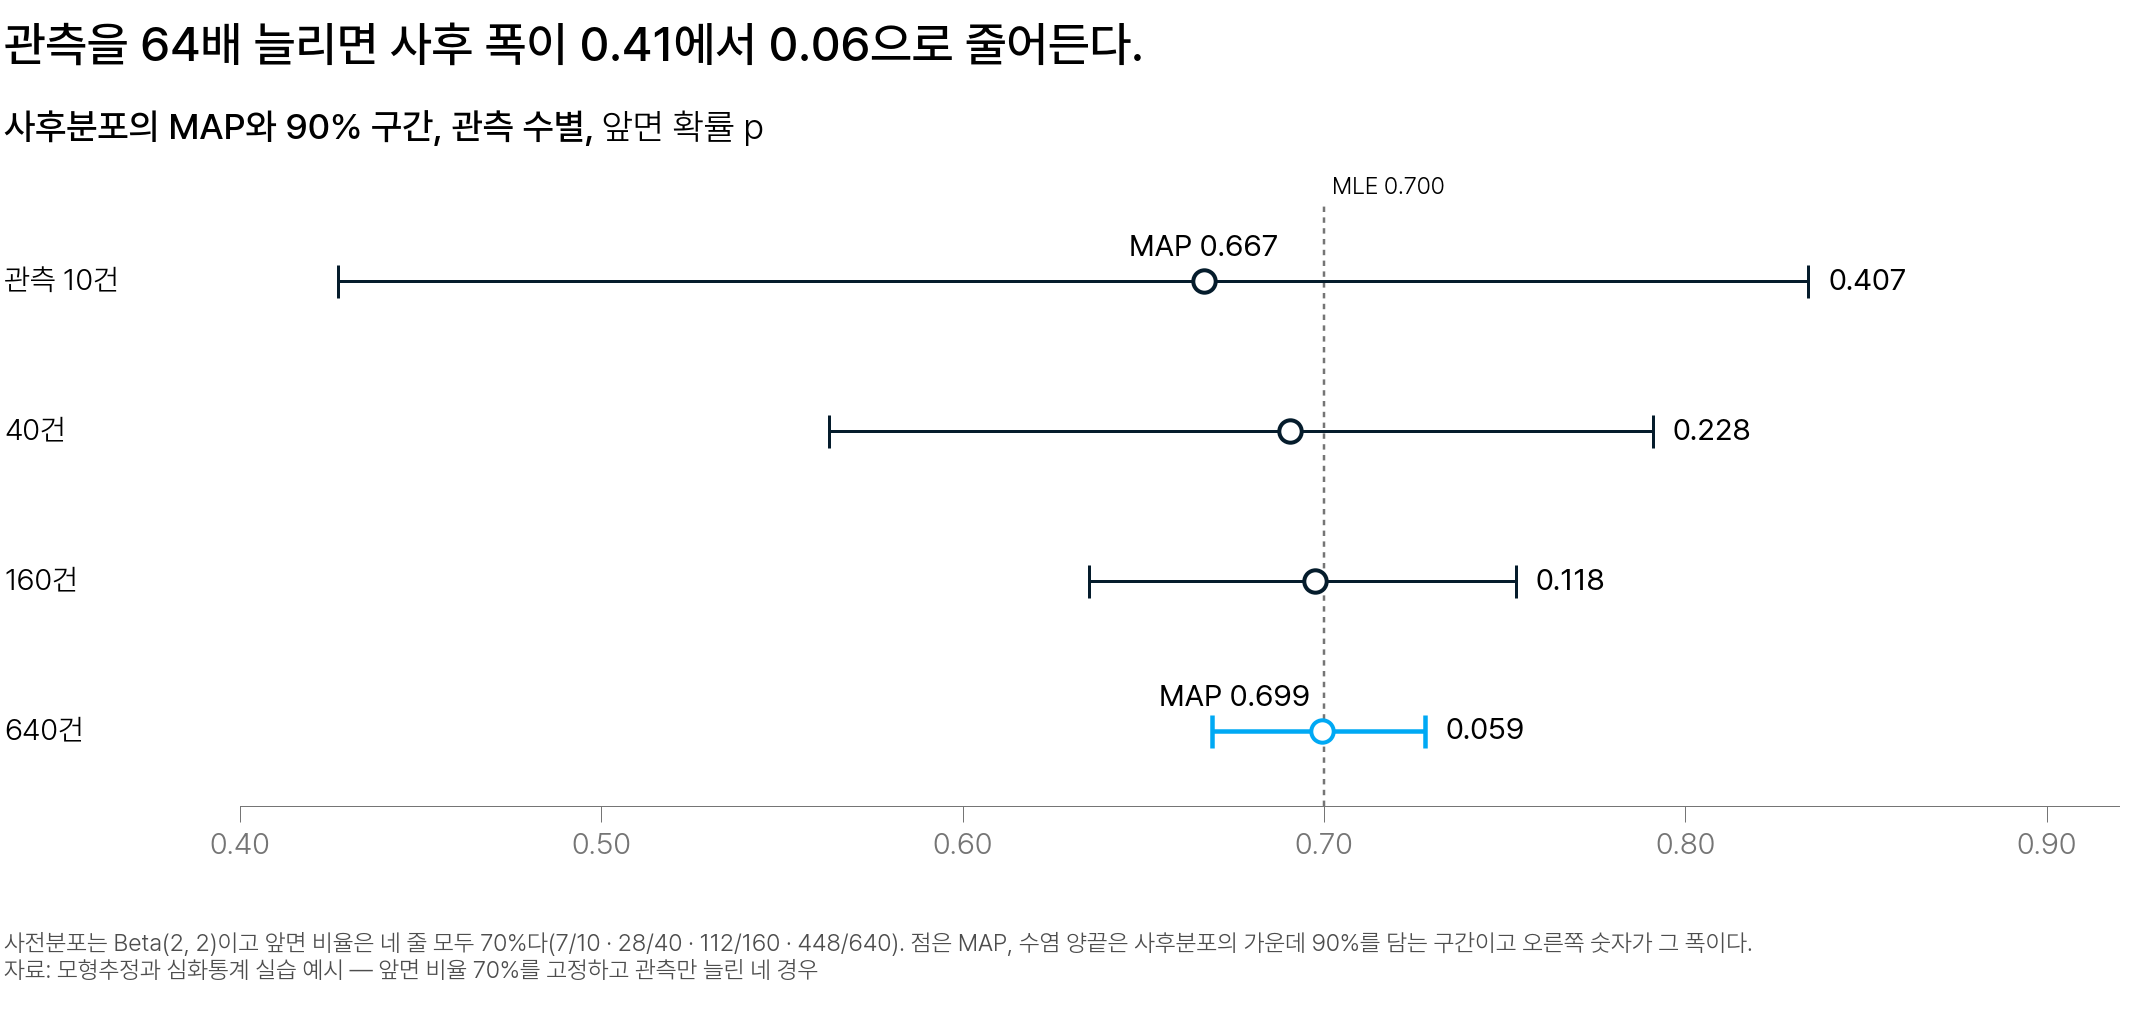

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 관측 수별 사후분포 요약 — 속 빈 원이 MAP, 구간 막대 양끝이 사후분포의 가운데 90% 를 포함하는 구간이고 오른쪽 숫자가 그 구간 길이라, 관측이 늘수록 점은 회색 점선의 MLE 0.700 으로 수렴하고 구간 막대는 0.407 에서 0.059 로 짧아진다</em></p>

관측 10건 행의 구간 막대는 가로축 눈금 간격 4개가 넘는 0.407 이라 "0.5 도 아니라고는 못 한다"는 상태입니다. 640건 행에서는 MAP 0.699 와 MLE 0.700 의 차이가 소수 셋째 자리뿐입니다.

실행 카드의 표에서 읽은 0.800 이 공식에서도 같게 나오는지 대입해 확인합니다.

<details class="lms-answer"><summary>최빈값 0.8 의 계산: 공식 대입</summary>

위 MAP 공식에 사전 $\alpha_0 = \beta_0 = 2$ 와 데이터 $k = 3$, $n = 3$ 을 그대로 넣어 보면 됩니다.

$$
\hat{p}_{\text{MAP}} = \frac{2 + 3 - 1}{2 + 2 + 3 - 2}
$$

분자와 분모를 각각 정리합니다.

$$
\frac{4}{5} = 0.8
$$

MLE 는 1.0 이었습니다.

구간의 끝점 1.0 으로 나왔던 추정값이 0.8 로 감소했습니다. 사전분포가 실패 확률을 남겨 둔 만큼 최빈값이 구간 안쪽으로 이동한 것입니다.

**검산.** 같은 공식을 사전분포 없이 쓰면, 곧 $\alpha_0 = \beta_0 = 1$ 인 균등 사전분포를 넣으면 분자가 $1 + 3 - 1 = 3$, 분모가 $1 + 1 + 3 - 2 = 3$ 이라 $3 \div 3 = 1.0$ 으로 MLE 가 그대로 나옵니다. 0.8 과 1.0 의 차이가 $\text{Beta}(2,2)$ 사전분포가 만든 수축입니다.

</details>

## MLE 는 균등 사전분포를 쓴 MAP

균등 사전분포 $\text{Beta}(1,1)$ 을 넣으면 공식이 $\hat{p}_{\text{MAP}} = k/n$ 이 됩니다. **MLE 는 "균등 사전분포를 쓴 MAP"** 였던 것입니다 — $\text{Beta}(1,1)$ 은 어느 값도 선호하지 않아(가상 관측 0회) 최빈값을 어느 쪽으로도 옮기지 않습니다. 강도는 2 이지만 그것은 곡선의 좁기이지 중심을 옮기는 양이 아닙니다.

머신러닝의 **정규화(regularization)** 도 같은 구조입니다. 정규화는 손실 함수에 벌점 항을 더해 모수가 극단값으로 가는 것을 막는 방법인데, 로그 사후분포에 $-1$ 을 곱하면 「손실 + 벌점」 으로 분리되고 그 벌점 항이 $-\log P(\theta)$ 입니다. 벌점 항은 사전분포를 다른 형태로 적은 것입니다.

<details class="lms-extra"><summary>더 깊이 — 로그 사후분포가 손실 + 벌점으로 분리되는 식</summary>

**먼저 로그가 곱을 합으로 바꿉니다.** MAP 가 최대화하려는 대상은 우도 $P(X \mid \theta)$ 와 사전분포 $P(\theta)$ 의 곱입니다. 그 곱에 로그를 씌웁니다.

$$
\log\big(P(X \mid \theta)\,P(\theta)\big) = \log P(X \mid \theta) + \log P(\theta)
$$

**그다음 양변에 $-1$ 을 곱합니다.** 부호를 바꾸면 최대화 문제가 최소화 문제로 바뀝니다.

$$
-\log\big(P(X \mid \theta)\,P(\theta)\big) = \underbrace{-\log P(X \mid \theta)}_{\text{손실}(\text{NLL})} + \underbrace{\big(-\log P(\theta)\big)}_{\text{벌점}}
$$

왼쪽 항은 어제 4절에서 최소화 문제로 바꿔 쓰던 음의 로그우도(NLL) 그대로이고, 새로 더해진 것은 오른쪽의 $-\log P(\theta)$ 하나뿐입니다.

**어떤 사전분포를 쓰느냐에 따라 벌점 항의 식이 정해집니다.** 여기서는 $\theta$ 를 비율 $p$ 처럼 0~1 사이 값이 아니라 음수부터 양수까지 어떤 값이든 될 수 있는 모수(예: 회귀 모형의 계수)로 둡니다. $\theta$ 에 평균 0, 표준편차 $\sigma$ 인 정규분포 사전분포를 쓰면 밀도가 $P(\theta) \propto \exp\left(-\frac{\theta^{2}}{2\sigma^{2}}\right)$ 이므로

$$
-\log P(\theta) = \frac{1}{2\sigma^{2}}\,\theta^{2} + \text{상수}
$$

가 됩니다. 손실에 $\lambda\theta^{2}$ 를 더하는 방법을 머신러닝에서 **릿지(ridge, L2 정규화)** 라 부르는데, 그 계수 $\lambda$ 가 $1/2\sigma^{2}$ 입니다. 여기의 $\lambda$ 는 벌점 계수이고, 이 권의 다른 절에서 사고율을 뜻하는 $\lambda$ 와는 다른 기호입니다. $\sigma$ 가 작을수록, 곧 사전분포가 0 주위에 좁게 집중될수록 $\lambda$ 가 커지므로 **벌점 계수 $\lambda$ 를 키우는 것과 사전분포를 좁히는 것은 같은 일**입니다. 사전분포를 밀도 $P(\theta) \propto \exp(-|\theta|/b)$ 인 라플라스 분포로 바꾸면 같은 계산으로 벌점이 $|\theta|/b$ 가 되고, 이것이 **라쏘(lasso, L1 정규화)** 입니다.

**용어가 겹치는 '정규화' 가 2개 있습니다.** 1절에서 정의한 정규화 상수 $P(X)$ 는 넓이를 1 로 맞추는 값이라 이름만 겹치는 다른 말입니다. 영어로도 앞은 normalizing constant, 뒤는 regularization 으로 다릅니다.

</details>

아래 그림은 곡선 3개를 겹쳐 최빈값이 어디로 이동하는지 보는 그림입니다.

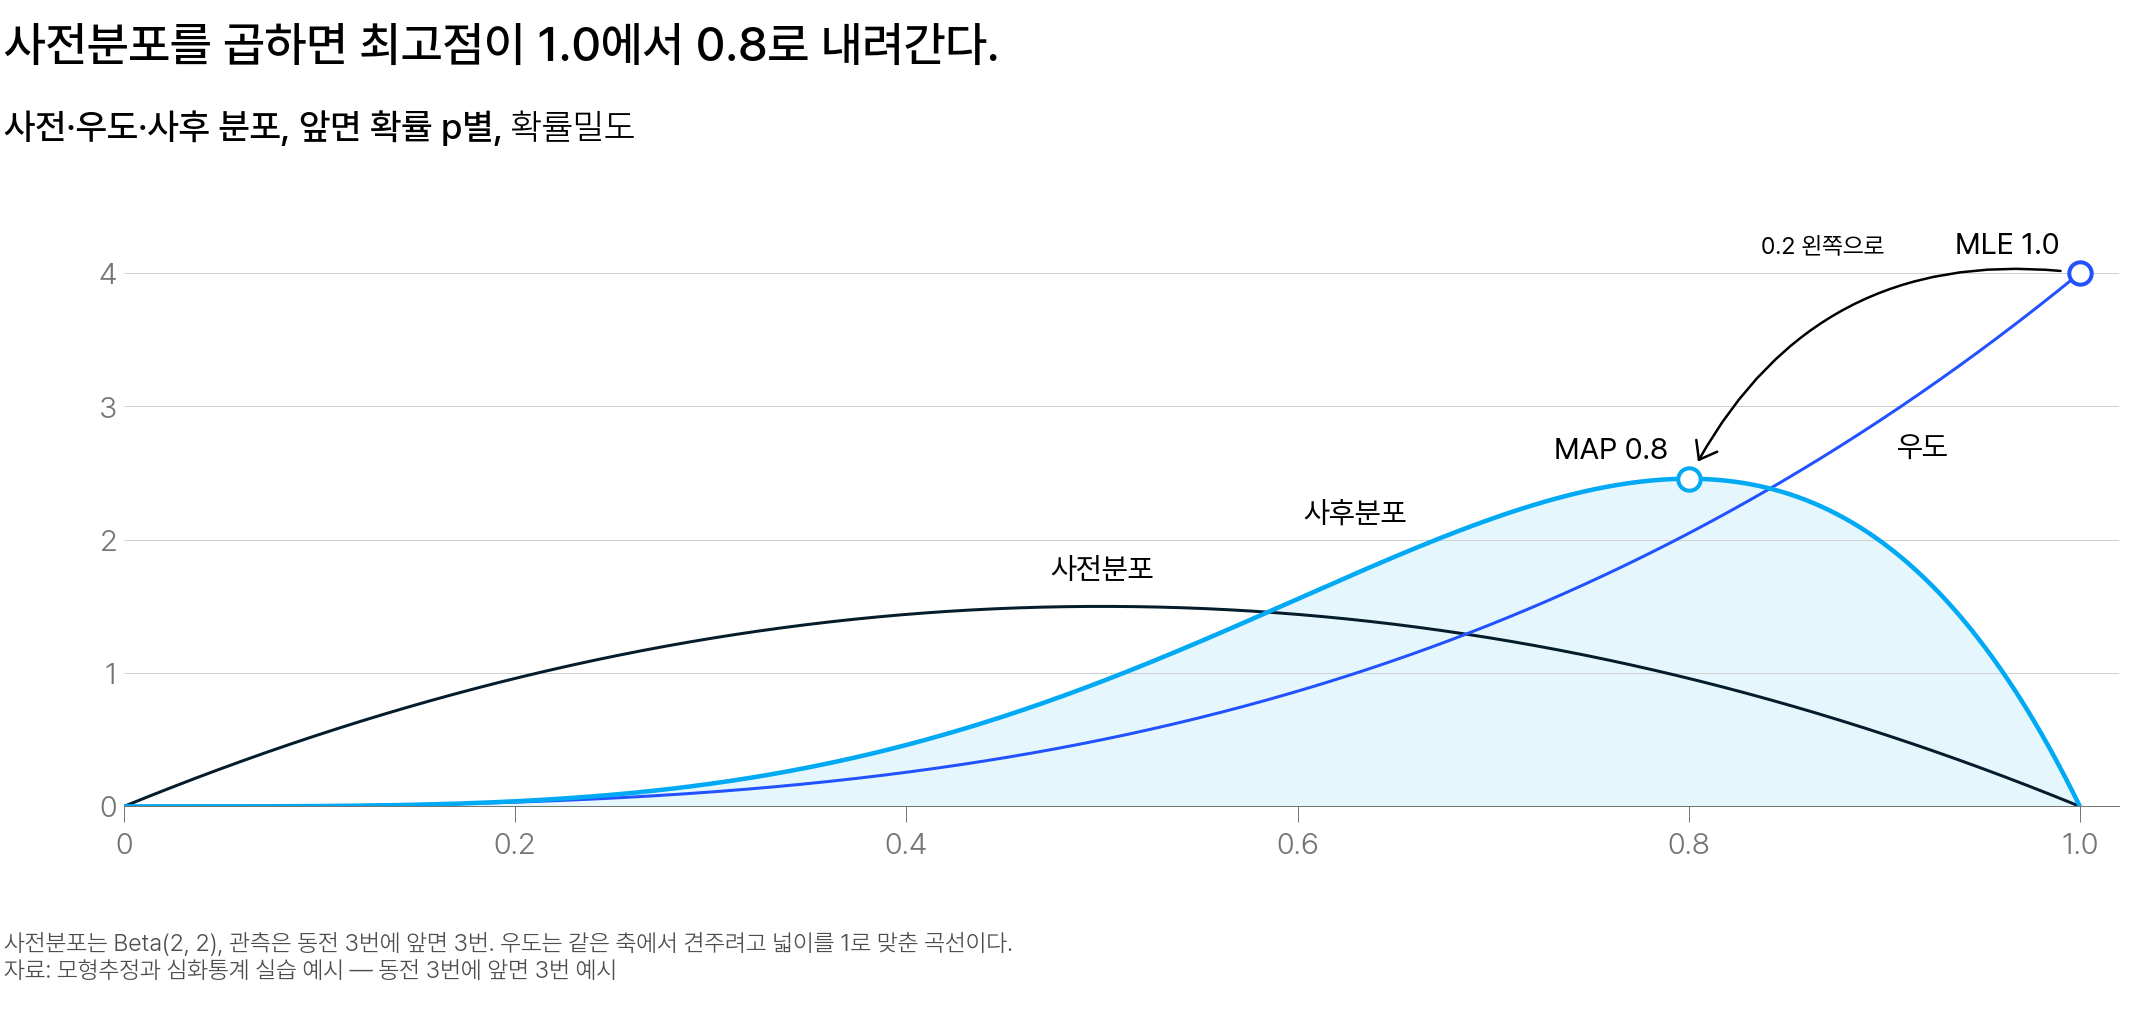

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 사전분포(남색) × 우도(파랑) = 사후분포(하늘색) — 두 속 빈 원이 각각 MLE(1.0)와 MAP(0.8)이고, 둘을 잇는 검은 화살표가 사전분포를 곱해 생긴 0.2 만큼의 이동이다</em></p>

#### 결과 해석

남색 사전분포와 파랑 우도를 곱한 하늘색 사후분포의 최빈값이 0.8 입니다. 우도가 최대인 위치 1.0(MLE)에서 사전분포 쪽으로 수축한 값이고, 2절에서 정의한 그 수축입니다.

## 요율표에 적을 값 — 관측이 적은 세그먼트

실무 적용 사례는 어제 3절 표의 맨 아래 행입니다. 그 표의 한 행은 **세그먼트** 하나입니다 — 세그먼트란 지역·차량 브랜드 같은 조건을 겹쳐 구성한 조합 하나, 그리고 그 조합에 속한 계약 $n$건을 말합니다. 계약 63건 중 사고 4건인 세그먼트라면 MLE 0.0635 가 전체 계약(회사 전체)의 평균 0.05 쪽으로 수축해 **MAP 0.055** 가 됩니다.

전체 계약의 사고 경험률 0.05 를 중심에 두고 가상 관측 100건(강도 $\alpha+\beta = 102$)인 사전분포 $\text{Beta}(6, 96)$ 을 설정한 결과입니다. MAP 공식의 $\alpha_0$ 에 6, $\beta_0$ 에 96, $k$ 에 4, $n$ 에 63 을 넣습니다.

$$
\hat{p}_{\text{MAP}} = \frac{6 + 4 - 1}{6 + 96 + 63 - 2} = \frac{9}{163} = 0.055
$$

가상 관측 100건짜리 사전분포를 계약 63건 세그먼트에 적용했으니 사전분포의 비중(최빈값 기준)은 $100/163 \approx 0.61$, 곧 61% 입니다. **그래서** 요율표에 어느 값을 적을지는 MLE 와 MAP 사이에서 사전분포의 가상 관측 수를 얼마로 둘지 정하는 문제가 됩니다.

<details class="lms-extra"><summary>더 깊이 — 가상 관측 수를 키울 때와 줄일 때의 대가</summary>

**⑴ 오른쪽 끝이 0 이 되는 것은 사전분포 때문입니다.** $\text{Beta}(2,2)$ 의 밀도는 $p(1-p)$ 형태라 $p = 1$ 에서 $1-p$ 가 0 이 됩니다. 우도가 $p=1$ 에서 가장 높아도 0 을 곱하면 0 이니, 사후분포는 그 값에서 0 이 됩니다.

**⑵ 가상 관측 수를 키우면 세그먼트마다 값이 극단으로 나오는 일은 줄어듭니다.** $\text{Beta}(6,96)$ 의 가상 관측을 1,000건으로 키우면 계약 63건 세그먼트의 값은 전체 평균 0.05 에 거의 같아지고, 10건으로 줄이면 MLE 0.0635 쪽에 남습니다. 어느 쪽도 계산이 틀린 것이 아니라 "계약 수가 적은 세그먼트를 얼마나 믿을 것인가" 라는 선택입니다.

**⑶ 가상 관측 수의 선택은 서로 반대인 두 오류 사이의 선택입니다.** 가상 관측 수를 키우면 수축이 강해져, 실제로 위험이 높은 세그먼트의 추정값도 전체 평균 0.05 쪽으로 내려갑니다. 그 세그먼트의 보험료는 실제 위험보다 낮게 산정됩니다(과소 산정). 가상 관측 수를 줄이면 수축이 약해져, 우연히 사고가 평소보다 몇 건 더 난 세그먼트의 추정값이 MLE 근처에 남습니다. 그 세그먼트의 보험료는 실제 위험보다 높게 산정됩니다(과대 산정). 한쪽 오류를 줄이면 다른 쪽 오류가 커지므로, 요율표를 만들 때는 가상 관측 수 하나를 정하는 것으로 두 오류의 크기를 함께 정하게 됩니다. 노출이 작은 세그먼트에서 값이 얼마나 수축하는지는 4절 끝 위젯에서 직접 조작해 봅니다.

</details>

MAP 는 점 추정값입니다 — 그 값이 얼마나 불확실한지까지 함께 적으려면 구간이 필요합니다.

## 신용구간 — 확률을 부여하는 대상이 다르다

**신용구간(credible interval)** — 사후분포에서 가운데 95% 를 포함하도록 자른 구간입니다. 95% 는 모수가 그 구간에 있을 **사후확률**이라, "모수가 이 안에 있을 확률 95%" 로 곧바로 읽습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Beta_distribution_cdf.svg" width="560" height="448"/>
<p align="center"><em>▲ 베타분포 5개의 누적분포함수(CDF) — 곡선이 0.025 와 0.975 를 가로지르는 두 지점의 가로 좌표가 그 분포의 95% 신용구간 양 끝이고, 보라 Beta(2,2) 는 0.094 와 0.906 이 그 두 값이다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia</span></p>

이름만 미뤄 뒀을 뿐 앞에서 이미 그렸습니다 — 실행 카드 표의 마지막 열, 점·구간 막대 그림의 구간 막대가 모두 신용구간이고, 자른 비율만 90% 가 아니라 95% 입니다. 어제 3절의 신뢰구간과 혼동하기 쉬운데, 차이는 95% 라는 숫자가 무엇의 비율인가입니다.

| 구분 | 신뢰구간 (어제 3절) | 신용구간 (이 절) |
|---|---|---|
| 구성 방법 | 추정값과 표준오차 — $\hat{p} \pm 2\,\mathrm{SE}$ | 사후분포에서 가운데 95% 를 자른다 |
| 95% 가 뜻하는 것 | 표집을 반복할 때 그렇게 만든 구간이 참값을 포함하는 비율 | 모수가 그 구간에 있을 사후확률 |
| 같은 데이터의 답 | 0.0497 ～ 0.0508 | 0.0497 ～ 0.0508 |

계약 678,013건에서 계산하면 두 구간의 양 끝이 **0.0497 ～ 0.0508** 로 같습니다. 표본이 이만큼 크면 사전분포의 영향이 거의 사라져 두 방법의 구간이 일치합니다. **그래서** 두 방법을 구분하는 것은 구간의 양 끝이 아니라 각 방법이 허용하는 확률 문장입니다. 신뢰구간은 「이 방법으로 만든 구간이 참값을 포함할 확률이 95%」 까지만 말할 수 있고, 신용구간은 「$p$ 가 이 구간 안에 있을 확률이 95%」 라고 말할 수 있습니다.

> **[문제] 신뢰구간과 신용구간의 확률 문장**
>
> MAP 는 사후분포에서 값 하나를 고른 것이고, 그 값이 얼마나 불확실한지까지 함께 적으려면 신용구간을 씁니다. 그런데 계약 678,013건에서는 어제 3절의 신뢰구간과 이 절의 신용구간이 둘 다 0.0497 ～ 0.0508 로 나왔습니다. 두 구간을 보고서에 옮겨 적을 문장으로 각각 한 문장씩 써 보고, 확률을 어디에 부여하는지로 무엇이 달라지는지 한 문장 추가해 보세요.

#### 핵심 주의점

MAP 를 사후분포의 평균처럼 읽으면 안 됩니다.

$$
\hat{p}_{\text{MAP}} = \frac{a-1}{a+b-2}, \qquad \text{사후 평균} = \frac{a}{a+b}
$$

- $a$, $b$ : 사후분포 $\text{Beta}(a,b)$ 의 두 모수
- $a-1$, $a+b-2$ : 최빈값 쪽에서 1 과 2 를 빼는 항 — 가상 관측을 복원하는 항입니다

두 식은 분자와 분모가 달라 같은 곡선에서도 서로 다른 값을 냅니다 — $\text{Beta}(9,5)$ 에서 0.6667 과 0.6429 로 다릅니다. "MAP 0.6667" 을 "사후분포의 평균이 0.6667" 로 옮겨 적으면 틀린 문장이 됩니다.

정확한 뜻은 다음과 같습니다.

> **사후분포 $\text{Beta}(9,5)$ 에서 곡선이 가장 높은 값이 MAP 0.6667 이고, 기댓값인 사후 평균은 그보다 작은 0.6429 다.**

> 켤레를 쓰면 갱신이 덧셈 2회로 끝나고, 그 사후분포의 최빈값이 MAP, 가운데 95% 를 자른 구간이 신용구간입니다.

다음 절은 이 도구를 동전이 아니라 계약 67만 8천 건에 적용합니다.

> **[문제] 사전분포의 강도가 커지면 MAP 는 어떤 값이 되나**
>
> 실행 카드 가운데 표는 동전 3번에 3번 앞면인 같은 데이터에 사전분포만 바꿔 가며 MAP 를 행마다 출력합니다. MLE 가 1.000 인 이 데이터에서, 사전분포를 $\text{Beta}(5,5)$ 로 두면 MAP 는 어느 값일까요?
>
> 1. 1.000
> 2. 0.800
> 3. 0.636
> 4. 0.537

## 4절 실무 적용 — 자동차보험 데이터

## 실무 적용 — 자동차보험 계약 데이터

**이 절에서 할 일**

1. 프랑스 자동차보험 계약 67만 8천 건을 열어, 계약마다 지켜본 기간이 다르다는 것부터 확인합니다.
2. 사고 건수의 합을 기간의 합으로 나눠 연간 사고율 하나를 냅니다.
3. 그 값을 기준선에 두고, 노출이 작은 세그먼트가 얼마나 수축하는지 위젯으로 조작해 봅니다.

3절에서 사전분포로 계약 수가 적은 세그먼트의 추정값을 수축시킨 그 도구가 실제 계약 기록 위에서 어떤 숫자를 산출하는지 확인합니다. 어제 3절에서 사고 경험률 5.02% 를 사용한 바로 그 데이터입니다 — **freMTPL2freq**(OpenML, ID 41214). 계약 하나마다 사고 건수 `ClaimNb`, 유지 기간 `Exposure`(연 단위), 운전자·차량·지역 특성이 함께 기록되어 있고, 열 이름과 첫 5개 행은 아래 「자세히」 에 정리했습니다.

**노출(Exposure)** — 계약 하나가 보장을 받은 기간이고 단위는 년입니다. 사고 건수를 비교할 때의 분모이고, 기호로는 $E_i$ 라 적습니다. 0.10 이면 약 5주입니다.

**사고율** — 사고 건수를 그 계약이 보장을 받은 기간(년)으로 나눈 값이고 단위는 건/년입니다. 분모인 이 기간이 바로 위에서 정의한 노출 $E_i$ 입니다. 이 절에서 구하는 값이 이것이고, 계산 절차는 잠시 뒤 계약 2건으로 먼저 봅니다.

<details class="lms-extra"><summary>자세히 — 오늘 쓰는 열 5개와 첫 5개 행, 그리고 상한 처리 2가지</summary>

표의 첫 5개 행입니다. 오늘 쓰는 열 5개만 골랐습니다.

| ClaimNb | Exposure | Region | VehBrand | VehPower |
|---|---|---|---|---|
| 1 | 0.10 | R82 | B12 | 5 |
| 1 | 0.77 | R82 | B12 | 5 |
| 1 | 0.75 | R22 | B12 | 6 |
| 1 | 0.09 | R72 | B12 | 7 |
| 1 | 0.84 | R72 | B12 | 7 |

- `ClaimNb` : 그 계약에서 접수된 사고 건수 — 이 절에서 집계하는 값입니다
- `Exposure` : 노출, 곧 그 계약이 보장을 받은 기간(년). 첫 행의 0.10 이면 약 5주입니다
- `Region` : 계약자가 사는 프랑스 행정구역 코드(R11·R22·R82 … 22개) — 5절에서 이 중 R43 과 R42 를 비교합니다
- `VehBrand` : 차량 브랜드 코드(B1 ～ B14 중 11개)
- `VehPower` : 차량 마력 등급(4 ～ 15 의 정수)

첫 5개 행이 전부 사고 1건인 것은 사고가 있는 계약이 표 앞쪽에 모여 있기 때문입니다. 전체로 보면 계약의 95%가 사고 0건인데, 그 계산은 잠시 뒤 그림에서 봅니다.

**집계 전에 상한 처리를 2가지 적용합니다.** 노출은 1년, 사고 건수는 4건을 상한으로 두고, 그보다 큰 값은 상한값으로 바꿉니다. 노출이 1년을 초과해 2년까지 적힌 계약이나 4건을 넘는 사고가 적힌 계약이 소수 포함되어 있어서, 그 몇 건이 전체 평균을 좌우하지 않게 하는 관례적인 전처리입니다. 이 절의 숫자는 모두 그 처리 뒤에 집계한 값이니, 전처리 규칙이 바뀌면 기준선 0.1006 도 다시 계산해야 합니다.

</details>

계약마다 노출이 얼마나 다른지부터 봅시다.

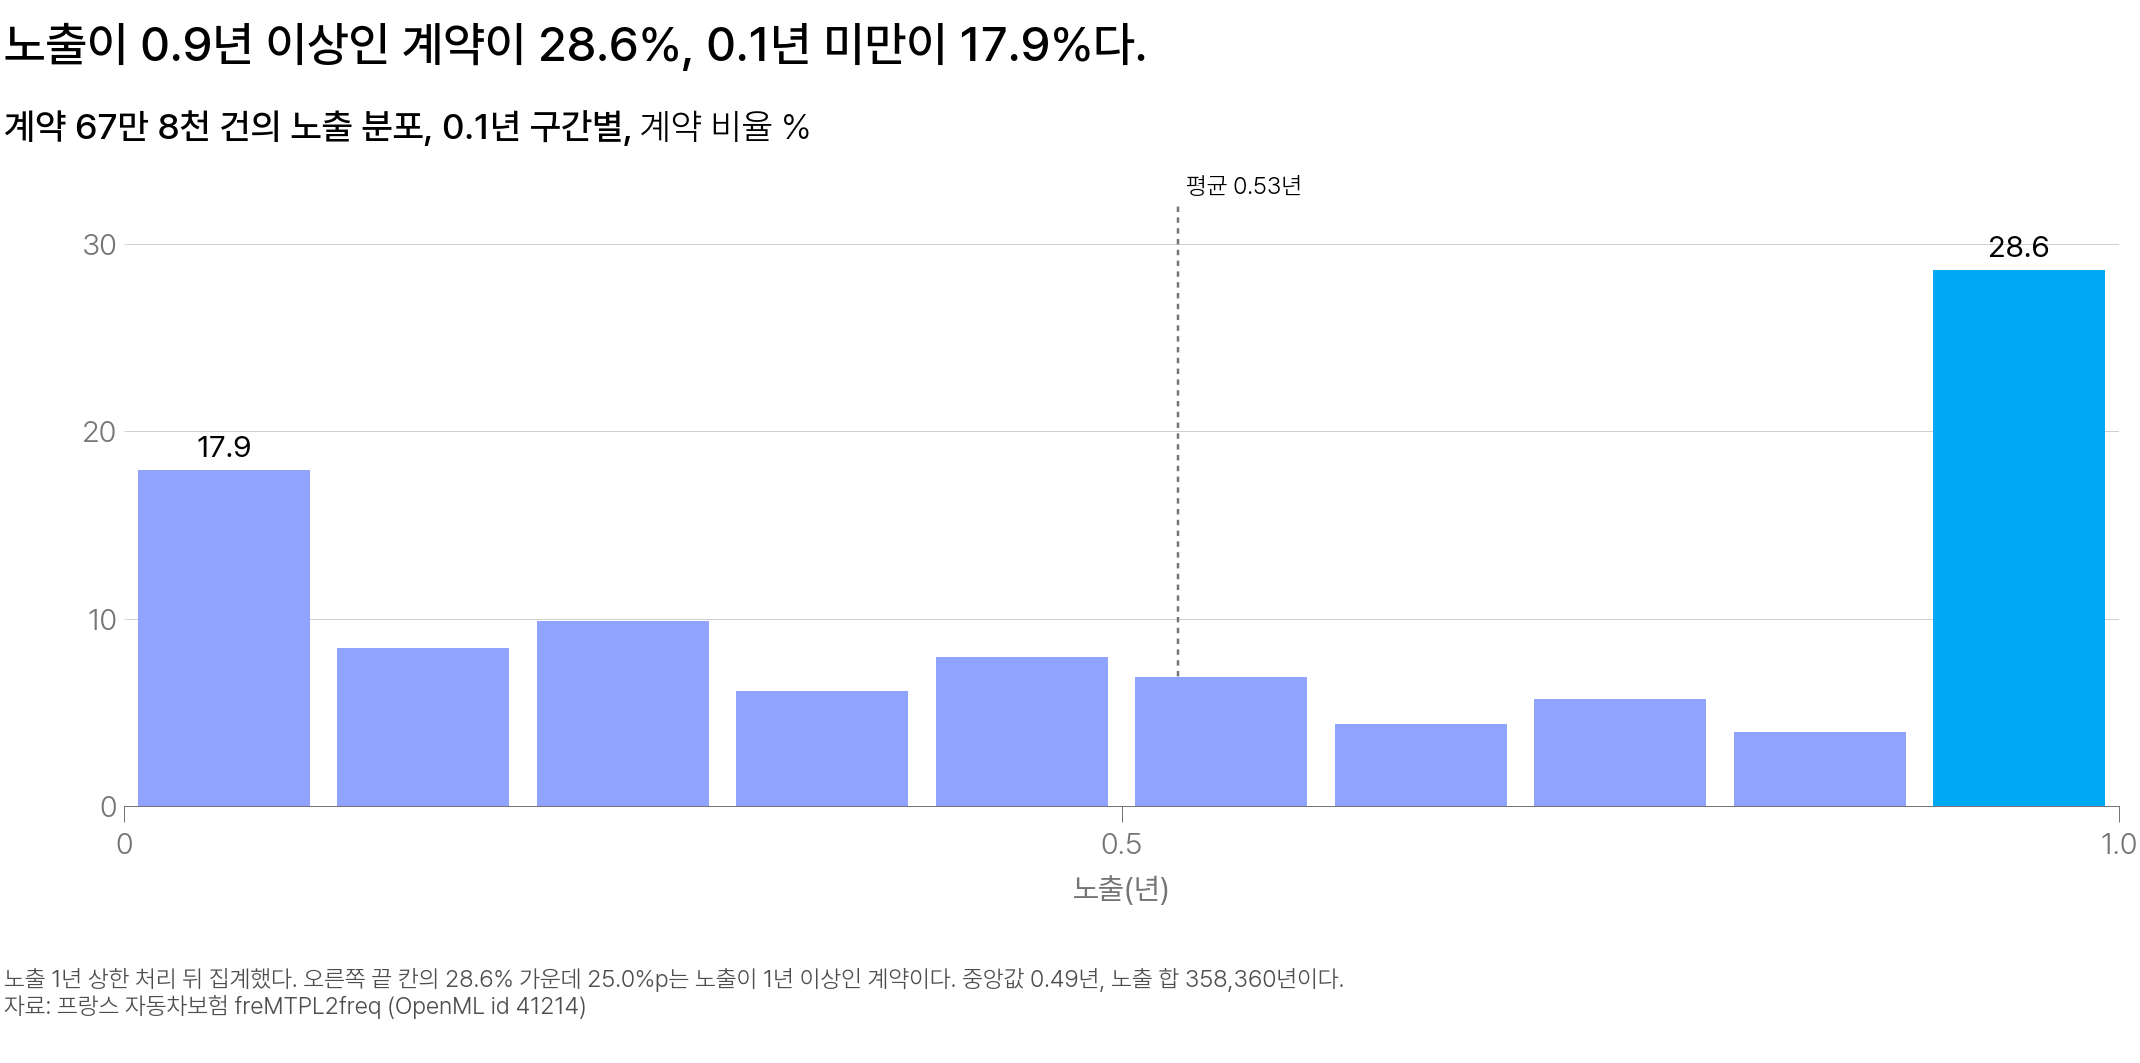

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계약 67만 8천 건의 노출 분포 — 가로축은 노출(년)을 0.1년씩 나눈 구간(bin) 10개, 세로축은 그 구간에 든 계약의 비율이다. 하늘색 오른쪽 끝 구간이 28.6%로 가장 높고 왼쪽 첫 구간이 17.9%이며, 회색 점선이 평균 0.53년 위치다</em></p>

여기서 **구간(bin)** 은 값 범위를 같은 길이로 나눈 구간 1개이고, 이 그림에서는 노출 0.1년이 구간 1개입니다. 오른쪽 끝 구간 28.6% 가운데 25.0%p 가 노출이 1년 이상인 계약이라 계약 4건 중 1건이 노출 1년을 채운 것이고, 왼쪽 첫 구간은 한 달 남짓인 0.1년 미만입니다. **그래서** 평균 0.53년은 계약 절반이 그 근처라는 뜻이 아니라 양쪽 끝을 함께 반영한 값입니다.

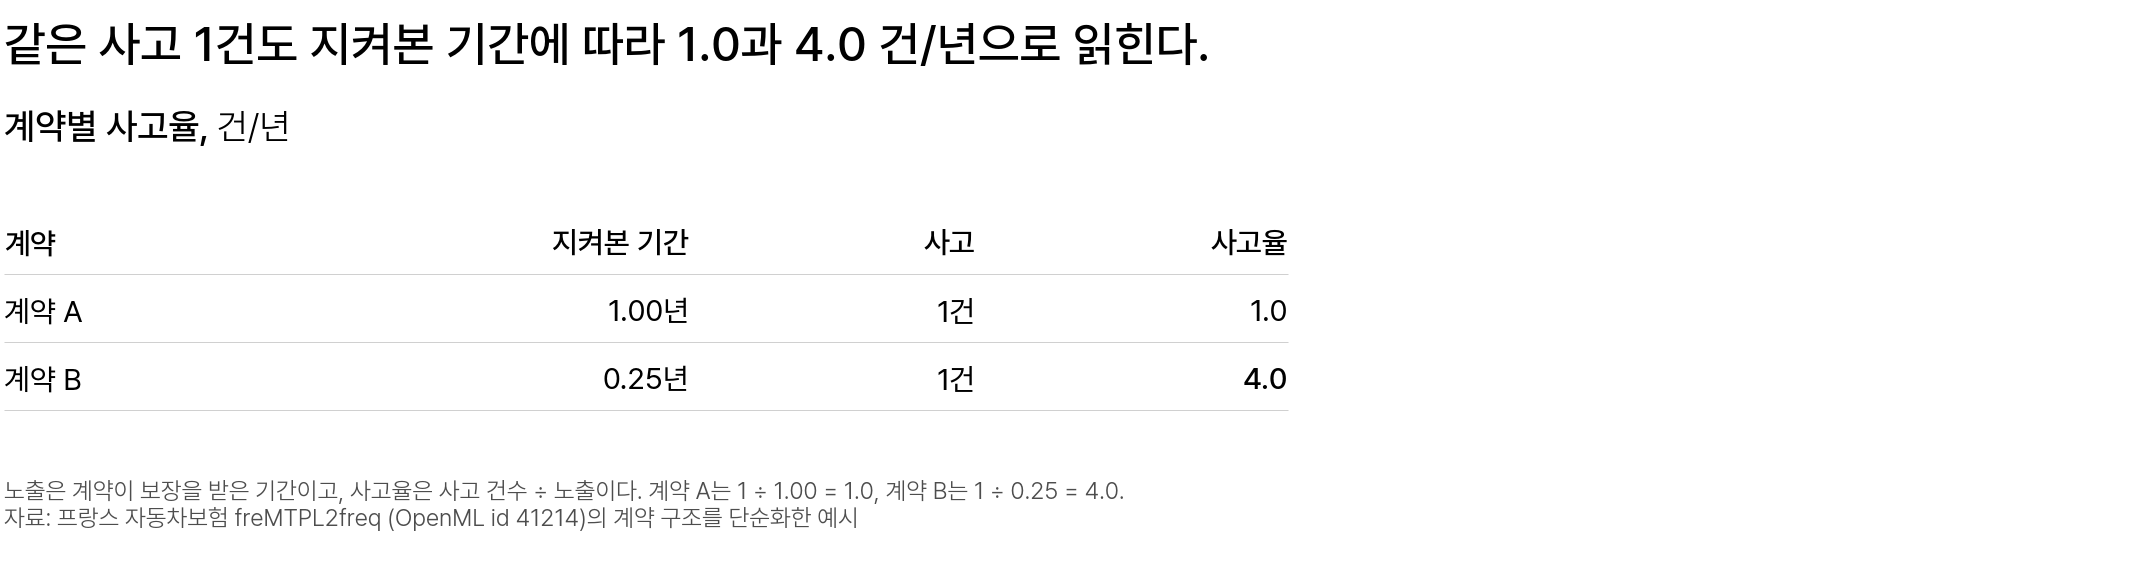

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 같은 사고 1건도 지켜본 기간이 다르면 다르게 읽힌다 — 사고율은 사고 건수 ÷ 노출(표의 지켜본 기간, 년)이니, 같은 1건이라도 3개월만 관측한 계약 B 는 1 ÷ 0.25 = 4.0(굵게 강조)으로 4배가 된다</em></p>

표의 두 숫자 0.25와 1.00을 기간의 **길이**로 그려 보면 4배 차이가 바로 보입니다.

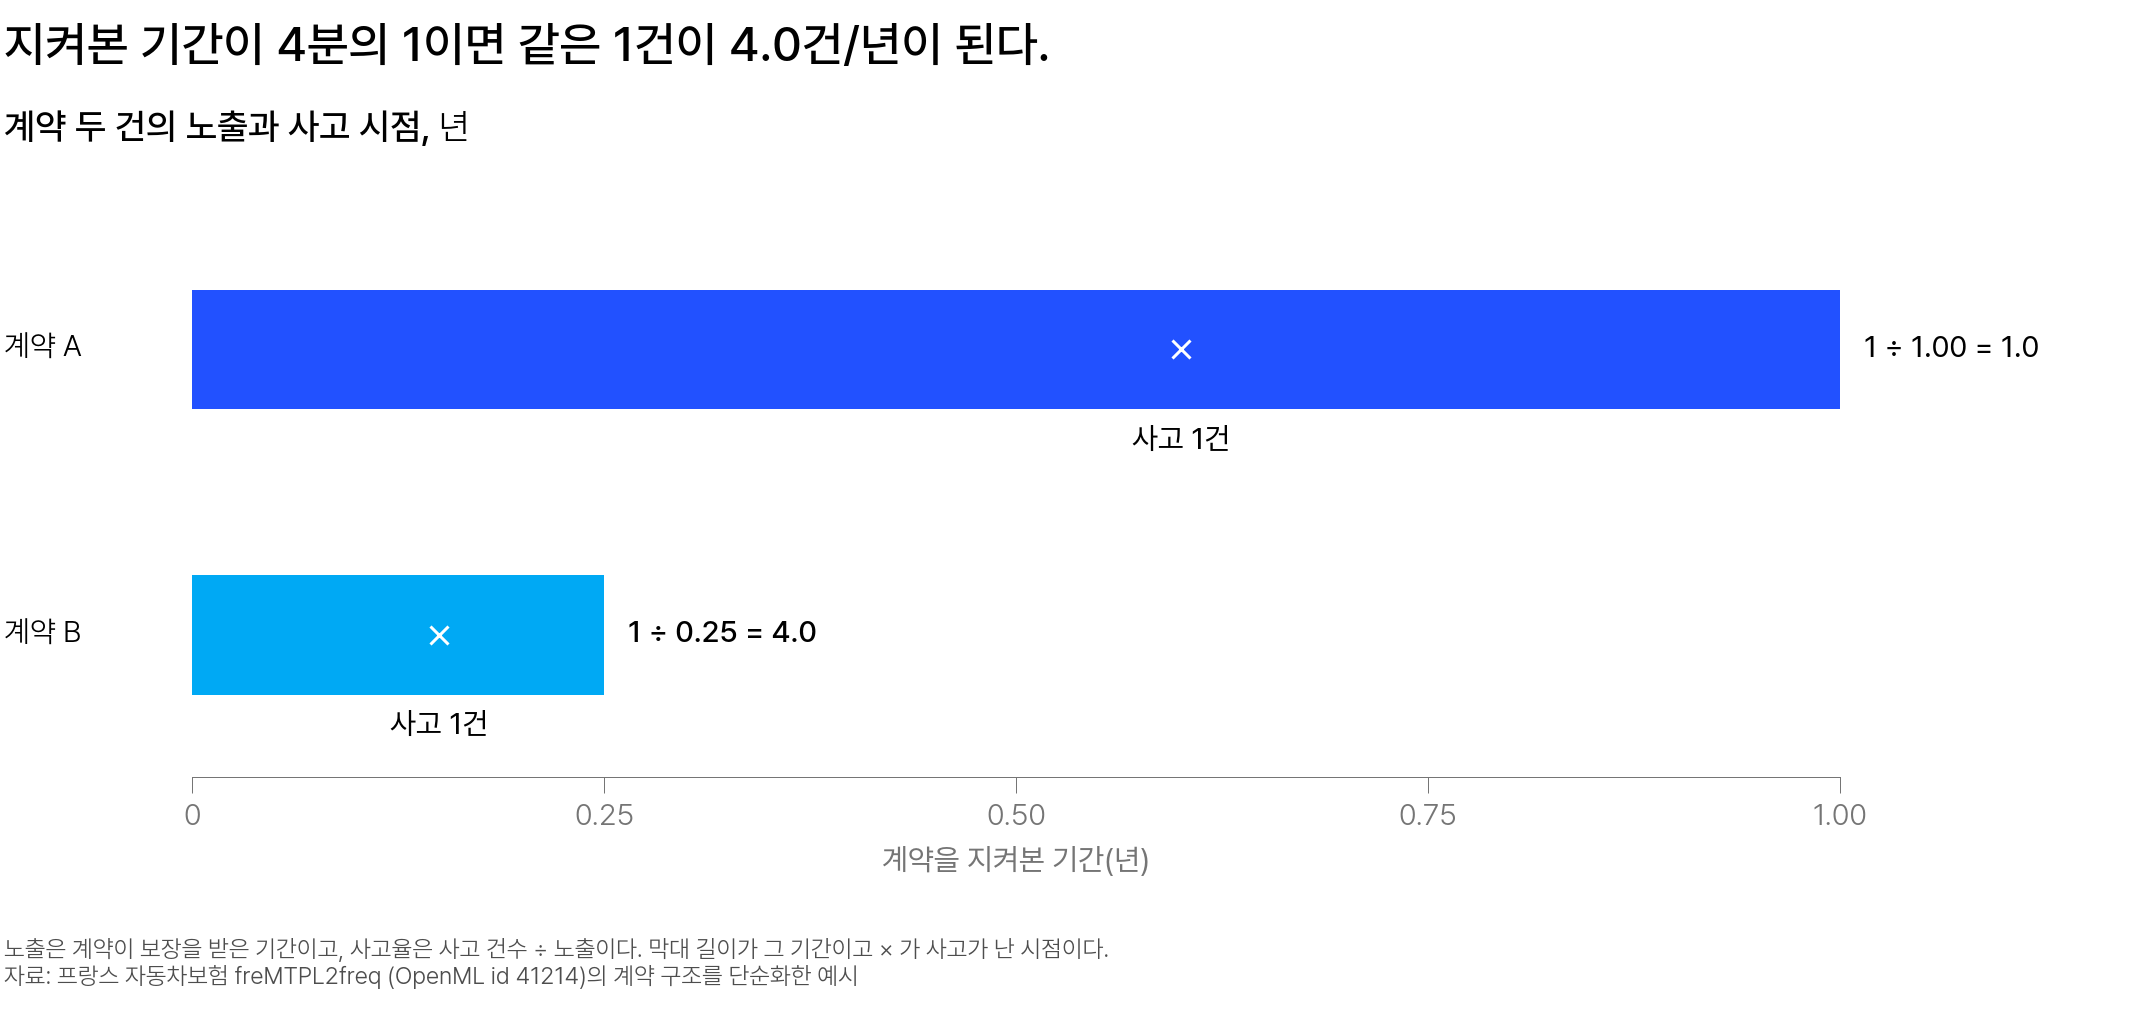

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계약 두 건의 노출을 길이로 그린 그림 — 막대 길이가 계약을 지켜본 기간이고 흰 ×가 사고가 난 시점이다. 파랑 계약 A는 1년을 다 지켜봤고 하늘색 계약 B는 0.25년만 지켜봤으니, 같은 사고 1건이 1.0과 4.0 건/년으로 다르게 계산된다</em></p>

#### 결과 해석

두 계약 모두 사고는 **1건**인데 관측 기간이 4배 차이라 **같은 1건이 4배로 계산됩니다.** 그래서 계약 678,013건의 사고율은 계약마다 따로 계산해 평균 내지 않고 합끼리 한 번만 나눕니다. 계약 A·B 로만 따져도 각자 나눈 평균은 2.5건/년, 합끼리 나눈 값은 1.6건/년으로 서로 다른데, 그 계산은 이 절 끝 「자세히」 에서 두 지표의 분모와 함께 전개합니다.

**사고율** — 사고 건수 ÷ 노출이고 단위는 건/년, 기호는 $\hat{\lambda}$ 입니다. 어제 3절에서 쓴 5.02% 는 계약이 기간 중 사고를 겪었는지만 0/1 로 기록하는 **사고 경험률**이라 다른 값입니다.

$$
\hat{\lambda} = \frac{\sum_i y_i}{\sum_i E_i}
$$

- $y_i$ : $i$번째 계약의 사고 건수
- $E_i$ : $i$번째 계약의 노출(년) — 계약 A 는 $E_A = 1.00$, 계약 B 는 $E_B = 0.25$

분자와 분모를 각각 먼저 합친 뒤 한 번만 나눕니다. 계약 67만 8천 건을 전부 넣으면 이렇게 됩니다.

$$
\hat{\lambda} = \frac{36{,}056}{358{,}360} = 0.1006\ \text{건/년}
$$

분자 36,056건은 접수된 사고를 모두 더한 수, 분모 358,360년은 그 계약들을 관측한 기간을 모두 더한 햇수입니다. **그래서** 계약 하나가 평균 10년에 한 번 사고를 낸다는 뜻이고, 이 0.1006 이 세그먼트로 나눌 때마다 기준으로 삼을 전체 계약의 기준선입니다.

이어지는 질문에는 지표가 하나 더 나옵니다. **계약당 단순 평균**은 사고 건수의 합을 **계약 수**로 나눈 값(건/계약)입니다. 평균 노출이 0.53년이라는 사실만 이용해 답해 보세요.

> **[예측] 이 데이터의 평균 노출은 약 0.53년입니다. 노출로 보정한 연간 사고율은 계약당 단순 평균과 비교해 어떻게 나올까요?**
>
> 1. 노출 보정한 쪽이 두 배쯤 크다
> 2. 노출 보정한 쪽이 절반쯤으로 작다
> 3. 둘이 사실상 같다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

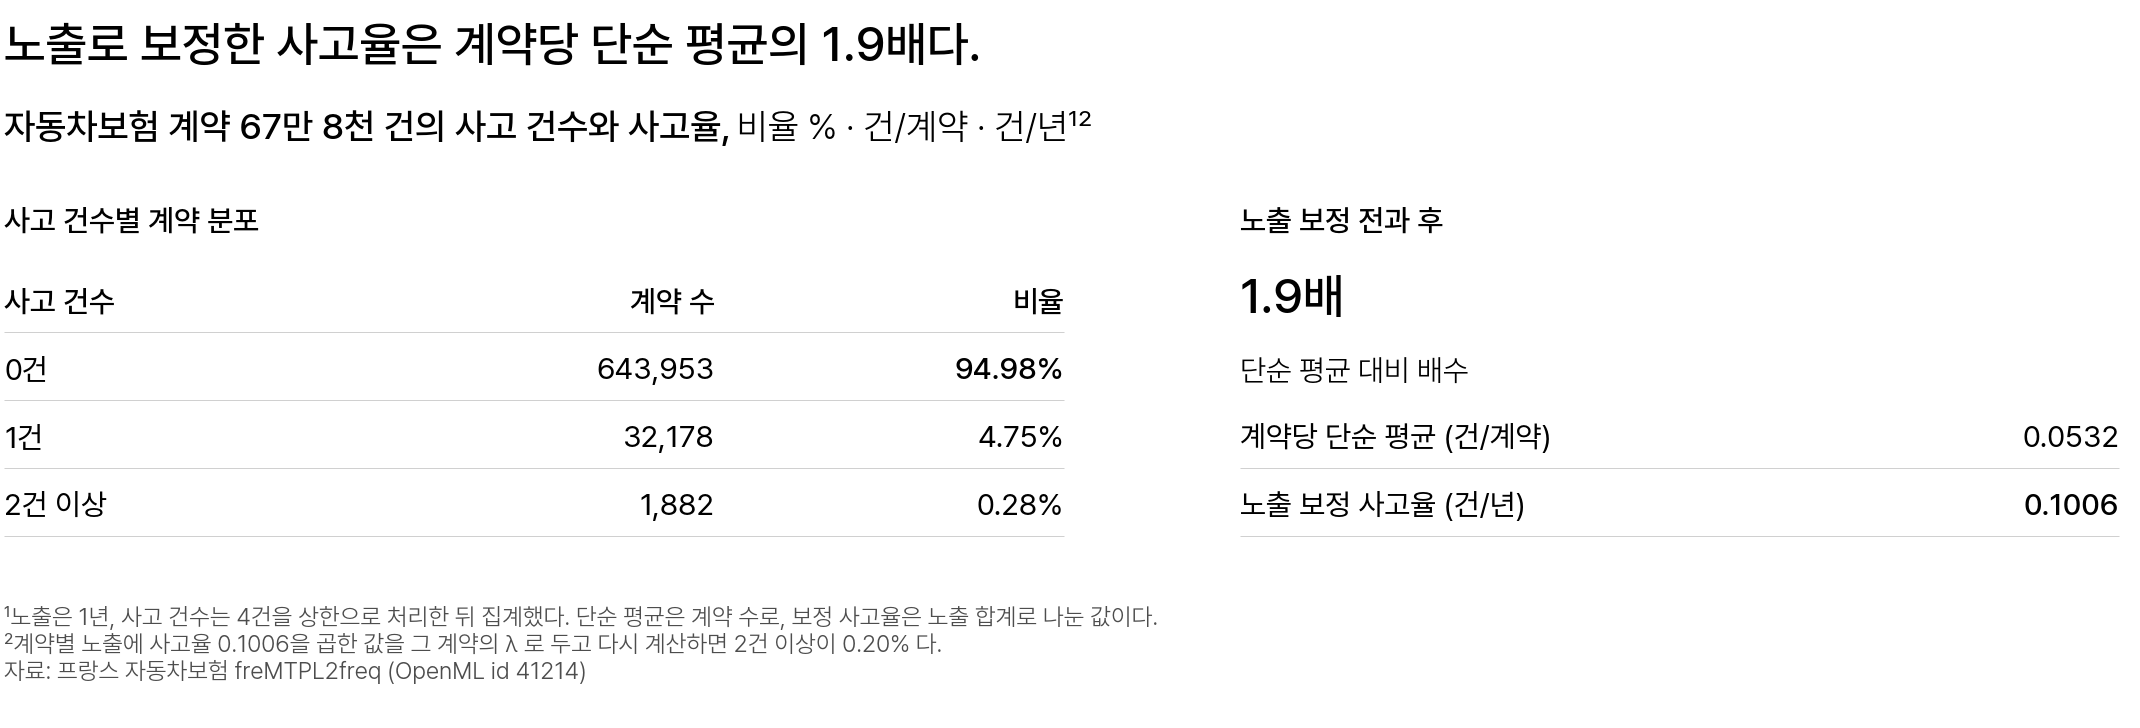

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 왼쪽 표: 계약 67.8만 건의 사고 건수별 분포 — 0건이 94.98%(굵게 강조)로 대부분이다 │ 오른쪽: 노출로 보정하면 사고율이 보정 전 0.0532건/계약 에서 λ̂ = 0.1006건/년 으로, 곧 1.9배로 증가한다</em></p>

#### 결과 해석

예측 탭의 답은 첫 번째, 노출 보정한 쪽이 두 배쯤 크다 — 오른쪽에 크게 표시된 1.9배가 그 값입니다.

3가지를 확인할 수 있습니다 — 계약의 약 95%는 사고 0건이고, 사고를 한 번이라도 낸 계약은 약 5%(어제 3절의 $\hat{p} = 0.0502$)이며, 노출로 보정한 연간 사고율은 $\hat{\lambda} = 0.1006$건/년입니다.

첫 항목은 사고가 드문 사건이라는 성질을 뜻하고, 드문 사건은 포아송 분포로 모형화하기 알맞습니다. 그 분포의 모양을 그림 1장으로 확인합니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Poisson_pmf.svg" width="560" height="433"/>
<p align="center"><em>▲ 포아송 분포 — 색은 λ 값이고 점 높이는 그 λ 에서 사건이 k 번 일어날 확률이다. 계약 하나의 연간 사고율 0.1006 은 맨 왼쪽 주황 곡선의 λ=1 보다도 훨씬 작아, 사고 0건인 계약이 95%를 차지한다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia</span></p>

<details class="lms-extra"><summary>더 깊이 — 포아송 예측 비율이 2건 이상 행에서만 어긋나는 이유</summary>

포아송분포가 이 데이터에 맞는지도 비교합니다. 아래 표에는 관측 비율 옆에, 계약당 평균 0.0532건을 $\lambda$ 로 둔 포아송의 예측 비율을 적었습니다. 표의 관측 비율은 계약을 '지켜본 기간 그대로' 집계한 값이니, 예측도 같은 지표인 계약당 평균 0.0532건으로 계산해야 나란히 놓입니다. 1년으로 환산한 0.1006 을 넣으면 관측하지 않은 기간까지 포함하게 되므로, 포아송분포가 예측하는 '사고가 있는 계약' 비율이 5.18%에서 9.57%로 약 2배가 됩니다.

예측 비율은 포아송 확률 $\dfrac{\lambda^{x} e^{-\lambda}}{x!}$ 의 $\lambda$ 에 0.0532 를 넣어 계산합니다.

0건은 $x$ 가 0 이라 $\lambda^{0} = 1$ 이고 $0! = 1$ 이니 $e^{-\lambda}$ 만 남습니다.

$$
e^{-0.0532} = 0.9482
$$

1건은 $x$ 가 1 이라 $\lambda^{1} = \lambda$ 이고 $1! = 1$ 이니 $\lambda\,e^{-\lambda}$ 입니다. 방금 낸 0.9482 를 그대로 씁니다.

$$
0.0532 \times 0.9482 = 0.0504
$$

2건 이상은 나머지로 계산합니다. 전체 1 에서 0건과 1건을 뺍니다.

$$
1 - 0.9482 - 0.0504 = 0.0014
$$

| 사고 건수 | 관측 비율 | 포아송 예측 비율 |
|---|---|---|
| 0건 | 94.98% | 94.82% |
| 1건 | 4.75% | 5.04% |
| 2건 이상 | 0.28% | 0.14% |

본문에 적은 5.18% 와 9.57% 도 같은 식에서 나옵니다. 사고가 한 번이라도 있는 계약 비율은 0건의 여집합이라 $1 - e^{-\lambda}$ 인데, $\lambda$ 에 계약당 지표 0.0532 를 넣으면 $1 - 0.9482 = 0.0518$ 입니다. 1년 환산값 0.1006 을 같은 식에 넣으면 $1 - e^{-0.1006} = 1 - 0.9043 = 0.0957$ 로 커집니다.

0건과 1건은 거의 일치하고 2건 이상 행만 관측 비율이 2배 높습니다. 표의 1건 5.04% 와 2건 이상 0.14% 를 더한 5.18% 는 관측된 사고 경험률 5.02% 에 훨씬 가깝습니다. 남은 차이는 계약마다 노출이 달라서 생기는 차이가 일부 설명합니다. 계약별 노출에 사고율 0.1006 을 곱한 값을 각 계약의 $\lambda$ 로 두고 다시 계산하면, 2건 이상 비율이 0.14%에서 0.20%로 증가해 관측 0.28%에 가까워집니다. 그 0.20% 는 사고 건수별 계약 분포 그림의 각주 ² 에 기록해 두었습니다.

</details>

## 두 지표의 구분 — 사고 경험률과 사고율

**계약당 단순 평균** 0.0532건/계약은 "유지된 기간 동안"의 건수인데 이 데이터의 평균 노출은 0.53년입니다. 1년으로 환산하면 $0.0532 \div 0.53 \approx 0.10$ 이니, 보정 전 값으로 보험료를 매기면 절반만 걷습니다. 두 값의 차이는 분모입니다 — 계약 수 678,013 이냐, 노출 합 358,360년이냐.

집계 대상도 다릅니다 — 사고 경험률은 기간 중 사고를 한 번이라도 겪었는지를 0/1 로 기록하고, 사고율은 그 계약의 사고 건수를 집계합니다.

| 구분 | 사고 경험률 (어제 3절 지표) | 사고율 (이 절 지표) |
|---|---|---|
| 집계 대상 | 기간 중 사고를 한 번이라도 겪었나(0/1) | 그 계약이 낸 사고 건수 |
| 분모 | 계약 수 678,013 | 노출 합 358,360년 |
| 오늘 값 | $\hat{p} = 0.0502$ | $\hat{\lambda} = 0.1006$건/년 |
| 짝이 되는 모형 | 베르누이·이항 → 베타 사전분포 | 포아송 → 감마 사전분포 |

5절에서 이 표를 다시 열어, 어느 지표로 집계하느냐에 따라 결론이 달라지는 것을 봅니다.

<details class="lms-extra"><summary>자세히 — 각자 나눈 평균 2.5 와 합끼리 나눈 1.6</summary>

**⑴ 각자 나눈 값을 평균하는 방식.** 두 방식이 어디서 달라지는지 앞의 계약 A·B 로 끝까지 계산해 둡니다. 계약 A 는 $1 \div 1.00 = 1.0$, 계약 B 는 $1 \div 0.25 = 4.0$ 이고, 이 둘을 평균합니다.

$$
\frac{1.0 + 4.0}{2} = 2.5\ \text{건/년}
$$

**⑵ 합끼리 나누는 방식.** 분자는 사고 건수의 합 $1 + 1 = 2$건, 분모는 노출의 합 $1.00 + 0.25 = 1.25$년입니다.

$$
\frac{2}{1.25} = 1.6\ \text{건/년}
$$

**⑶ 왜 달라지나.** ⑴ 은 3개월만 관측한 계약 B 를 1년을 채운 A 와 똑같이 한 건으로 집계합니다. B 의 1건은 0.25년치 관측인데 A 의 1건과 같게 집계하니 값이 커집니다. ⑵ 는 두 계약을 관측 기간(노출)으로 가중해 함께 계산한 값입니다.

**⑷ 대소 관계가 전체 데이터와 반대로 나오는 경우.** 여기서는 합끼리 나눈 1.6 이 각자 나눈 평균 2.5 보다 **작은데**, 전체 데이터에서는 보정한 쪽이 더 큽니다. 비교하는 짝이 다르기 때문입니다. 여기서 비교 대상인 2.5 는 분모가 각 계약의 기간이고, 전체 데이터의 비교 대상인 계약당 단순 평균은 분모가 계약 수라 기간이 아예 들어 있지 않습니다.

</details>

## 그 기준선의 불확실성

0.1006건/년도 추정값이라 구간을 함께 적습니다. 계약 67.8만 건을 관측 35.8만 년으로 받친 추정이라 구간이 매우 좁아, 0.0996 ～ 0.1017건/년입니다. **그래서** 요율표의 기준선을 0.10건/년으로 정하는 판단은 이 구간 안에서 바뀌지 않습니다.

<details class="lms-extra"><summary>자세히 — 사고율의 표준오차와 구간을 계산하는 과정</summary>

**⑴ 분모가 관측량입니다.** 어제 3절에서 $\hat{p}$ 에 대해 계산했던 표준오차, 곧 추정값이 표본마다 흩어지는 정도를 0.1006 에도 계산해 봅니다. 어제 4절에서 $n$ 이 들어가던 항에 노출 합이 들어갑니다.

$$
\mathrm{SE}(\hat{\lambda}) = \sqrt{\frac{\hat{\lambda}}{\sum_i E_i}}
$$

- $\hat{\lambda}$ : 노출로 보정한 사고율(건/년)
- $\sum_i E_i$ : 노출 합 — 계약 하나가 $E_i$년치 관측이라, 이 추정을 받치는 관측량은 계약 수가 아니라 관측 35.8만 년입니다

**⑵ 숫자를 넣습니다.** $\hat{\lambda}$ 에 0.1006 을, $\sum_i E_i$ 에 358,360 을 넣습니다.

$$
\mathrm{SE}(\hat{\lambda}) = \sqrt{\frac{0.1006}{358{,}360}}
$$

먼저 나눕니다. 0 이 6개나 앞에 오니 자릿수 표기로는 $2.807 \times 10^{-7}$ 입니다.

$$
\frac{0.1006}{358{,}360} = 0.0000002807
$$

제곱근을 씌웁니다.

$$
\sqrt{0.0000002807} = 0.00053
$$

**⑶ 구간으로 읽습니다.** 추정값 $\pm 2\,\mathrm{SE}$ 이니 더하고 뺄 값은 $2 \times 0.00053 = 0.00106$ 입니다. 끝자리까지 맞추려면 반올림 전 값 0.100614 로 계산해야 합니다.

아래 끝은 빼서 얻습니다.

$$
0.100614 - 0.00106 = 0.099554
$$

위 끝은 더해서 얻습니다.

$$
0.100614 + 0.00106 = 0.101674
$$

넷째 자리에서 반올림하면 0.0996 ～ 0.1017건/년입니다. 다만 세그먼트로 나누면 구간이 넓어져 이 판단을 그대로 유지할 수 없습니다.

</details>

### [직접 해보기] 노출이 작은 세그먼트의 수축

3절 끝에서 계약 63건 세그먼트의 MLE 0.0635 가 MAP 0.055 로 감소하는 것을 확인했습니다. 그 수축을 0.1006건/년 지표에서 직접 조작해 봅니다. 감마 사전분포에서는 강도가 노출과 같은 단위, 곧 가상 기간(년)입니다.

데이터 쪽 비중과 사전분포 쪽 비중은 합이 1 입니다.

$$
w = \frac{E}{E + \beta_0}, \qquad 1 - w = \frac{\beta_0}{E + \beta_0}
$$

- $w$ : 데이터 가중치 — 화면에서는 `발언권` 이라는 라벨로 뜹니다
- $1-w$ : 사전분포의 비중 — 감마 사전분포에서는 $\beta_0/(\beta_0 + E)$ 입니다
- $E$, $\beta_0$ : 세그먼트의 노출(년)과 감마 사전분포의 강도(가상 기간, 년)

1. **조작.** 먼저 켜져 있는 `사고 많음` 탭, `사전 강도 β₀` 기본값 100년(= 가상 노출 100년) 그대로 두고 `세그먼트 노출 E` 만 왼쪽 끝에서 오른쪽 끝까지 밉니다.
2. **관찰.** `수축 폭 |MLE − MAP|` 이 0.226 에서 0.006 까지 줄어듭니다. 하늘색 `사후` 의 최빈값은 회색 점선 `전사 평균 λ = 0.1006` 과 파랑 `우도` 의 최댓값 위치 사이에 있습니다. 어느 쪽에 더 가까운지 보고, `데이터의 발언권 w = E/(E+β₀)`(화면 라벨이고, 뜻은 데이터 가중치입니다) 와 수축 정도가 반대로 움직이는 것을 확인합니다. 남은 비중, 곧 사전분포의 비중 $1-w$ 가 함께 어떻게 변하는지도 계산해 보세요. 첫 화면은 `세그먼트 노출 E` 6.62년, `사전 강도 β₀` 100년이라 사전분포의 비중이 $100/106.62 \approx 0.94$ 입니다(초기화 버튼은 없습니다).
3. **확인 질문.** 옮기기 전에 예측해 보세요 — 노출을 2배로 늘리면 데이터 가중치 $w$ 도 2배가 될까요?

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/map-shrink-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 노출을 2배로 늘릴 때 데이터 가중치 w 의 변화</summary>

2배가 되지 않습니다. $E$ 를 키우면 분자만 커지는 것이 아니라 분모 $E + \beta_0$ 도 같이 커지기 때문입니다 — `사전 강도 β₀` 를 50년에 둔 채 노출을 50년에서 100년으로 2배 늘리면 데이터 가중치는 $50/100 = 0.50$ 에서 $100/150 = 0.67$ 로, 2배가 아니라 1.3배쯤 증가합니다.

같은 값을 사전분포의 비중으로 읽으면 $1 - w$ 가 0.50 에서 0.33 으로 줄어든 것입니다. 첫 화면인 노출 6.62년·$\beta_0$ 100년에서는 사전분포의 비중이 $100/106.62 \approx 0.94$ 이고, 슬라이더 왼쪽 끝 3.00년에서는 $100/103 \approx 0.97$ 이라 사실상 사전분포만 보고 있는 상태입니다. $E$ 가 $\beta_0$ 보다 훨씬 커지면 $1-w$ 가 0 에 수렴해 MAP 가 MLE 와 같은 값이 됩니다. 수축이 사라지는 것도 그 구간입니다.

</details>

<details class="lms-extra"><summary>더 깊이 — 탭별 화면과 사전 강도를 1000년으로 바꿨을 때</summary>

`사고 많음` 탭에서 노출을 옮기는 동안 `수축 폭 |MLE − MAP|` 은 매끄럽게 줄지 않습니다. `관측 사고` 가 1건 늘어나는 지점마다 계단 모양으로 한 번씩 다시 커지니, 감소하는 큰 흐름과 그 위의 증감을 함께 보세요.

`평균 수준` 탭으로 옮겨 같은 조작을 해 보면(β₀ 는 그대로 100년입니다) 3절의 계약 63건 세그먼트처럼 사고가 흔치 않은 세그먼트가 나옵니다. 노출을 10년에서 15년으로 증가시키면 관측 사고가 1건에서 2건으로 늘면서 수축 정도가 0.001 에서 0.028 로 오히려 커지고, 노출이 200년을 초과하면 0.000～0.001 에 수렴해 거의 변하지 않습니다. 사고가 드문 세그먼트에서는 1건이 늘고 주는 것만으로 MLE 가 크게 변한다는 뜻입니다.

`무사고` 탭은 사고가 0건이라 MLE 가 늘 0.000 인 세그먼트입니다. 같은 화면은 `평균 수준` 탭에서도 나옵니다 — `세그먼트 노출 E` 를 왼쪽 끝(3.00년)으로 옮기면 `관측 사고` 가 0건으로 감소해 같은 문구가 뜹니다. 탭 이름이 아니라 관측 사고가 0건인 상태가 그 화면의 조건입니다.

`사전 강도 β₀` 를 1000년까지 증가시키면 같은 오른쪽 끝(E = 3000년)에서도 수축 정도가 0.006 이 아니라 0.050 으로 남습니다. 강도를 그만큼 크게 두었기 때문입니다 — β₀ 1000년이면 E = 3000년에서도 사전분포의 비중이 25% 남습니다. 위에 적은 수축 정도는 모두 β₀ 를 100년에 둔 화면의 값이니, 조작해 봤다면 100년으로 복원해 두세요.

라벨도 노출에 따라 달라집니다. 데이터 가중치가 10% 아래면 사전분포와 사후분포가 거의 겹쳐 라벨이 `사전 ≈ 사후` 하나로 합쳐지고, 괄호 안에 그때의 데이터 가중치가 6.2% 로 함께 적혀 나옵니다. 노출을 옮겨 데이터 가중치가 10% 를 넘는 순간 `사후` 라벨이 분리되고, 오른쪽 끝으로 옮기면 데이터 가중치가 96.8%까지 증가해 이번엔 반대쪽이 `우도 ≈ 사후` 로 합쳐집니다.

</details>

이 절의 결과는 값 1개가 아니라 지표 2개입니다. 사고 경험률 0.0502 와 노출로 보정한 사고율 0.1006건/년이 약 2배 차이가 납니다.

이어지는 실습에서는 같은 계산을 지역 × 차량 브랜드 세그먼트 242개마다 직접 실행해 보고, 다음 절에서는 계약을 지역 2개로 나눠 사후분포를 나란히 놓고 "어느 쪽이 더 나쁜가" 를 확률 하나로 답할 수 있는지 봅니다.

#### 핵심 주의점

사고율 0.1006건/년을 "계약의 10% 가 사고를 낸다" 는 확률로 읽으면 안 됩니다.

$$
\hat{\lambda} = \frac{\sum_i y_i}{\sum_i E_i} = \frac{36{,}056}{358{,}360} = 0.1006\ \text{건/년}
$$

분모가 계약 수가 아니라 노출 합이라 단위가 건/년이고, 한 계약이 한 해에 2건을 내면 1 을 넘습니다. 따라서 "계약 100건 중 10건이 사고를 낸다" 로 읽으면 0.0502 와 2배 차이가 나는 문장이 됩니다.

정확한 뜻은 다음과 같습니다.

> **계약 하나를 1년 지켜보면 사고가 평균 0.1006건 접수된다는 뜻이고, 사고를 한 번이라도 겪은 계약 비율은 그 절반인 0.0502 다.**

> 분모가 계약 수인가 노출 합인가 — 그 하나가 같은 데이터를 0.0502 와 0.1006 으로 다르게 만든다.

> **[문제] 계약당 사고 건수의 단순 평균이 0.0532건, 평균 노출이 0.53년일 때 1년 단위의 사고율은 약 0.05건/년이다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 5절 두 집단 비교와 사고 건수

## 점추정값 비교에서 사후분포 비교로

**이 절에서 할 일**

1. 두 지역의 사후분포를 겹쳐 놓고 "B가 A보다 클 확률"을 숫자 하나로 냅니다.
2. 그 확률과 차이의 신용구간을 읽고, 방향과 크기를 구분해 적습니다.
3. 지표를 사고 여부에서 사고 건수 ÷ 노출로 바꿔, 같은 데이터의 답이 얼마나 달라지는지 봅니다.

요율 회의의 질문은 이렇습니다. **"이쪽 지역 계약이 저쪽보다 정말 더 위험한가요?"** MLE로 답하면 "R43는 0.041, R42는 0.056" 에서 끝나고, 두 값이 실제로 다른 것인지 표본 변동인지는 알 수 없습니다. 1절에서 본 대로 베이즈 추정의 산출물은 값 하나가 아니라 **곡선 전체**라, 곡선 2개를 겹쳐 놓고 "B가 A보다 클 확률"을 직접 계산하면 됩니다.

## 두 지역에 같은 계산을 적용

지역 R43는 계약 **1,326건** 중 **54건**, R42는 **2,200건** 중 **124건**이 기간 중 사고를 한 번 이상 겪었습니다. 수식에서는 각각 $\theta_A$·$\theta_B$ 로 간단히 씁니다(실습의 도시화 등급 `Area` 와는 무관한 첨자입니다).

**이항 우도(binomial likelihood)** — 계약 $n$건 중 $k$건에 사고가 있었을 때 후보 $\theta$ 마다 계산하는 우도값입니다. 계약 하나가 "사고를 겪었나 아닌가"의 베르누이 시행이라 어제 3절의 $L(\theta) = \theta^{k}(1-\theta)^{n-k}$ 가 그대로 우도입니다. $\theta$(세타)는 그 지역 계약 하나가 기간 중 사고를 겪을 확률입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Binomial_distribution_pmf.svg" width="560" height="420"/>
<p align="center"><em>▲ 이항분포 — 시행 수 n 과 성공 확률 p 를 정해 놓았을 때 성공이 k 번 나올 확률이다. 파랑 마름모(p=0.5, n=20)는 10 에, 초록 네모(p=0.7, n=20)는 14 에서 최대가 되어 최빈값이 n×p 를 따라간다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia</span></p>

3절 켤레를 그대로 쓰면 균등 사전분포 $\text{Beta}(1,1)$ 에서 갱신은 덧셈 2회입니다.

$$
\text{Beta}(1,\, 1) \;+\; (k\text{건 사고},\; n-k\text{건 무사고}) \;\longrightarrow\; \text{Beta}(1+k,\; 1+n-k)
$$

- $k$ : 기간 중 사고를 한 번 이상 겪은 계약 수 — 지역 R43는 54건
- $n$ : 그 지역 계약 수 — 지역 R43는 1,326건

숫자를 넣으면 R43는 $\text{Beta}(55,\, 1273)$, R42는 $\text{Beta}(125,\, 2077)$ 입니다. 사후 평균 $\alpha/(\alpha+\beta)$ 는 각각 $0.0414$·$0.0568$ 로, MLE $0.0407$·$0.0564$ 에서 조금 증가했습니다. 균등 사전분포는 최빈값을 옮기지 않으므로($\text{Beta}(1,1)$ 에서 최빈값은 $k/n$ 으로 MLE 와 같습니다) 달라지는 것은 기댓값인 사후 평균뿐입니다.

> **[예측] 두 지역의 사후분포를 같은 가로축에 겹쳐 그리면 두 곡선은 어떻게 보일까요?**
>
> 1. 완전히 떨어져 있어 겹치는 구간이 없다
> 2. 중심은 떨어져 있으나 그 사이 구간에서 겹친다
> 3. 거의 포개져 구분이 되지 않는다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

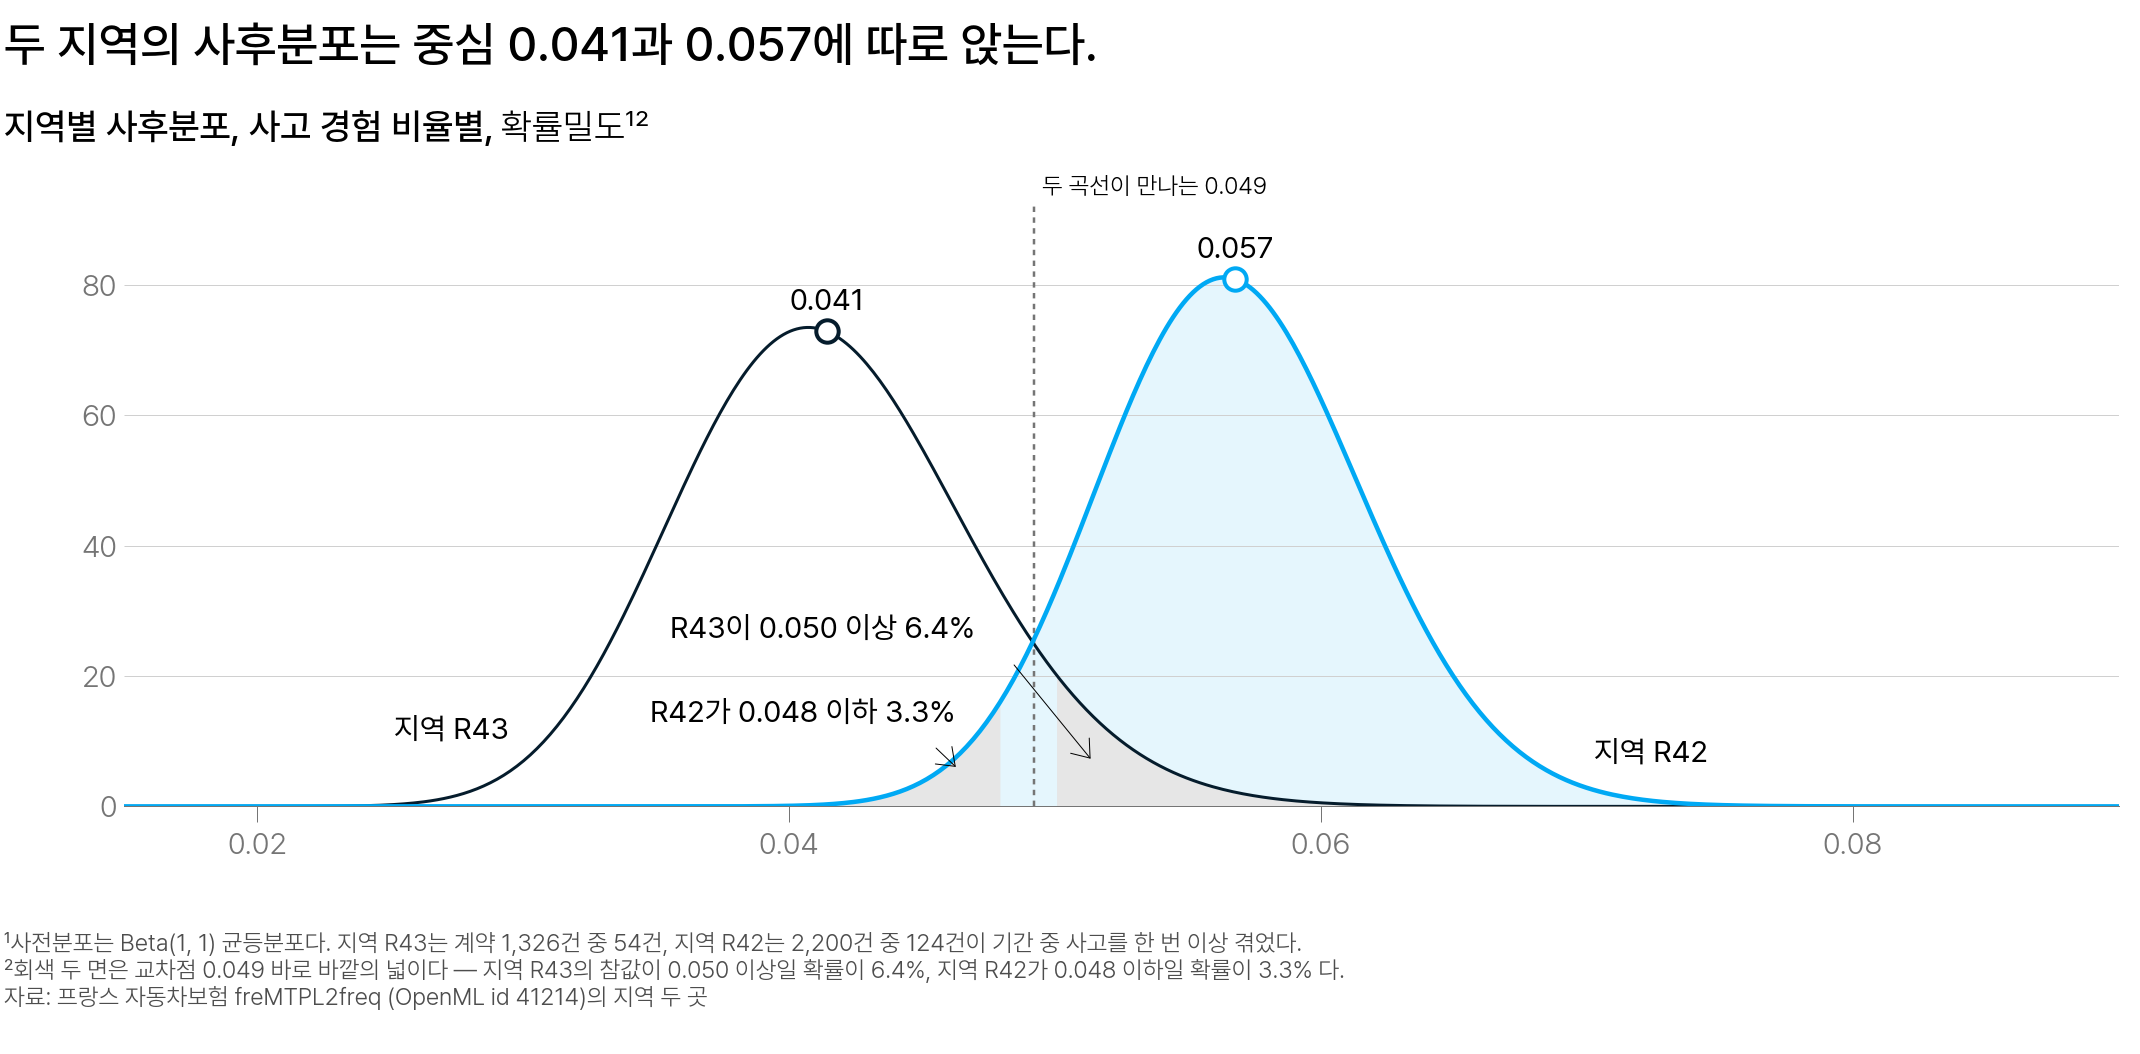

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 지역 R43(남색)와 R42(하늘색)의 사후분포 — 가로축은 계약 하나가 기간 중 사고를 겪을 확률 θ, 세로축은 확률밀도이고, 속 빈 원이 사후 평균 0.041·0.057, 회색 점선이 두 곡선이 교차하는 0.049, 그 바깥 회색 두 면이 지역 R43이 0.050 이상일 확률 6.4%와 지역 R42가 0.048 이하일 확률 3.3%다</em></p>

#### 결과 해석

예측 탭의 답은 두 번째, 중심은 떨어져 있으나 그 사이 구간에서 겹친다 입니다. 속 빈 원으로 표시한 두 **사후 평균** 사이의 거리만 볼 것이 아닙니다. **두 곡선은 0.049 에서 교차합니다.** 교차점 바깥의 회색 두 면 — R43 의 참값이 0.050 이상일 확률 6.4%, R42 가 0.048 이하일 확률 3.3% — 이 둘 다 0 이 아니라, "B가 더 나쁘다"를 단정할 수는 없습니다.

세로축은 확률밀도라 높이가 아니라 넓이가 확률입니다. 최빈값 위치의 최댓값 73(R43)·81(R42)도 확률이 아니라, 길이 0.001인 구간으로 치면 7%·8%라는 뜻입니다. 최댓값이 나오는 **위치**가 최빈값이고 속 빈 원이 표시한 **사후 평균**은 그보다 조금 오른쪽이라, 두 요약값은 같은 위치가 아닙니다.

<details class="lms-extra"><summary>더 깊이 — 최댓값 73 과 81 의 비가 표준편차 비와 같은 숫자인 계산</summary>

높이 비 $81 \div 73 = 1.11$ 과 표준편차 비 $0.00547 \div 0.00493 = 1.11$ 이 같은 숫자로 나옵니다. 우연이 아니라 "곡선 아래 넓이가 1" 이라는 제약에서 나오는 결과입니다.

**⑴ 두 사후분포의 표준편차를 공식으로 냅니다.** $\text{Beta}(\alpha, \beta)$ 의 분산은 이렇습니다.

$$
\mathrm{Var} = \frac{\alpha\beta}{(\alpha+\beta)^{2}\,(\alpha+\beta+1)}
$$

- $\alpha$, $\beta$ : 그 사후분포의 두 모수 — R43 는 55 와 1,273 입니다

**⑵ 지역 R43 의 $\text{Beta}(55,\, 1273)$ 에 넣습니다.** 분자는 $55 \times 1273 = 70{,}015$ 이고, 분모는 $1{,}328^{2} \times 1{,}329 = 2{,}343{,}803{,}136$ 입니다.

$$
\mathrm{Var}_A = \frac{70{,}015}{2.3438 \times 10^{9}} = 2.987 \times 10^{-5}
$$

제곱근을 씌워 표준편차로 바꿉니다.

$$
\sigma_A = \sqrt{2.987 \times 10^{-5}} = 0.00547
$$

**⑶ 지역 R42 의 $\text{Beta}(125,\, 2077)$ 에도 같은 식을 넣습니다.** 같은 절차로 계산하면 $\sigma_B = 0.00493$ 입니다.

**⑷ 두 곡선 다 아래 넓이가 1 이라, 좁아진 만큼 높아집니다.** 정규분포로 근사하면 최대 밀도가 $1/(\sigma\sqrt{2\pi})$ 라 $\sigma$ 에 반비례하니, 최댓값의 비는 표준편차 비의 역수가 됩니다.

$$
\frac{0.00547}{0.00493} = 1.11
$$

그림에서 읽은 최댓값이 81 과 73 이고 $81 \div 73 = 1.11$ 이라 같은 값입니다. 11% 차이는 곡선의 산포로는 눈에 띄지 않지만 최댓값에서는 세로축 눈금 8개 차이로 나타납니다.

</details>

## "B가 A보다 클 확률"을 계산하는 방법

두 곡선에서 값을 하나씩 추출했을 때 B 쪽이 큰 경우가 몇 %인지를 계산하는 일입니다. 두 지역의 계약은 겹치지 않아 두 사후분포를 **서로 독립**으로 두었습니다 — 덕분에 두 곡선에서 읽은 값을 그냥 곱할 수 있습니다.

**방법 1 — 격자로 넓이를 더합니다.** $\theta$ 를 잘게 나누고, 구간마다 "B가 그 구간에 있을 밀도 × A가 그보다 작을 확률"을 곱해 전부 더합니다.

$$
P(\theta_B > \theta_A) = \int_0^1 f_B(\theta)\, F_A(\theta)\; d\theta
$$

- $f_B(\theta)$ : R42 사후분포의 밀도 — 방금 그림의 하늘색 곡선 높이
- $F_A(\theta)$ : R43 사후분포의 **누적확률**(CDF) — "A의 값이 $\theta$ 보다 작을 확률", 남색 곡선 아래 넓이를 왼쪽부터 누적한 값입니다

이 데이터에서 그 값은 **0.980** 입니다.

**방법 2 — 두 사후분포에서 표본을 추출해 비율을 계산합니다.** 지역 R43 과 지역 R42 의 사후분포에서 값을 하나씩 짝지어 **표본 10만 쌍**을 추출합니다. 그중 R42 쪽이 큰 쌍의 비율을 계산하는 방법이 **몬테카를로(Monte Carlo)** 입니다. 같은 사건의 확률을 계산하는 것이라 답도 격자와 같은 **0.980** 이고, 적분이 어려운 모형에서도 표본만 추출하면 값이 나와 실무에서 더 자주 씁니다.

<details class="lms-extra"><summary>더 깊이 — 몬테카를로 추출의 방법과 표준오차 0.00044</summary>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Pi_30K.gif" width="400" height="400"/>
<p align="center"><em>▲ 몬테카를로로 원주율을 계산하는 화면 — 한 변이 1 인 정사각형에 점 3만 개를 무작위로 배치하면 사분원 안에 든 빨강 점의 비율이 π/4 에 수렴하고, 화면 위 π ≈ 3.1524 가 그 비율에 4 를 곱한 값이다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia</span></p>

표본 1쌍은 두 사후분포에서 값을 하나씩 추출해 짝지은 것이고, 코드로는 `rng.beta(a, b)` 한 행입니다. 그 표본 10만 쌍에서 R42 쪽이 큰 비율을 계산하면 격자와 같은 **0.980** 이 나옵니다.

추출로 얻은 값에는 오차가 있습니다. 비율의 표준오차는 표본 수가 $N$ 이고 참값이 $p$ 일 때 이렇습니다.

$$
\mathrm{SE} = \sqrt{\frac{p(1-p)}{N}}
$$

- $p$ : 계산하려는 비율 — 여기서는 0.98 근처입니다
- $N$ : 추출한 표본 쌍의 수 — 여기서는 100,000 입니다

$p \approx 0.98$, $N = 100{,}000$ 을 넣으면 분자가 $0.98 \times 0.02 = 0.0196$ 이라 이렇게 됩니다.

$$
\mathrm{SE} = \sqrt{\frac{0.0196}{100{,}000}}
$$

먼저 나눕니다.

$$
\frac{0.0196}{100{,}000} = 0.000000196
$$

제곱근을 씌웁니다.

$$
\sqrt{0.000000196} = 0.00044
$$

소수 셋째 자리까지는 믿을 만하고 넷째 자리는 난수에 따라 변한다는 뜻입니다. 유효숫자를 한 자리 더 얻으려면 표본 수를 100배로 늘려야 합니다.

</details>

아래 실행 카드가 사용하는 숫자 4개는 계약 수, 사고를 겪은 계약 수, 사고 건수, 노출 합입니다. 4절의 그 계약 표를 열어 지역으로 걸러 더하면 그대로 나옵니다 — 이름은 여기서 `expo`, 실습에서는 `df` 입니다.

```python
from sklearn.datasets import fetch_openml

expo = fetch_openml(data_id=41214, as_frame=True).frame       # 첫 실행은 다운로드에 수십 초
expo["ClaimNb"] = expo["ClaimNb"].astype(int).clip(upper=4)   # 모듈 공통 규칙: 사고 건수 4건 상한 처리
expo["Exposure"] = expo["Exposure"].clip(upper=1.0)           # 모듈 공통 규칙: 노출 1년 상한

for r in ("R43", "R42"):
    sub = expo[expo["Region"] == r]                      # 그 지역 계약만 남긴다
    print(f"{r}: 행 {len(sub):,} · 사고 겪은 행 {(sub['ClaimNb'] >= 1).sum()} · "
          f"ClaimNb 합 {sub['ClaimNb'].sum()} · Exposure 합 {sub['Exposure'].sum():,.2f}")
```

```
R43: 행 1,326 · 사고 겪은 행 54 · ClaimNb 합 57 · Exposure 합 563.77
R42: 행 2,200 · 사고 겪은 행 124 · ClaimNb 합 133 · Exposure 합 1,208.64
```

행 수 1,326 이 계약 수, 사고가 1건이라도 있는 행 54 가 사고 경험률의 분자입니다. `ClaimNb` 합 57 과 `Exposure` 합 563.77 은 절 뒤에서 지표를 바꿀 때 사용합니다.

In [ ]:
# 사후분포 두 개를 견주는 두 방법 - 격자로 넓이를 더하기 vs 몬테카를로 추출
import math

import numpy as np

# 네 숫자는 바로 위에서 지역으로 걸러 찍어 본 값이다 - 사고 겪은 계약 54건 / 전체 1,326건 (R43),
# 124건 / 2,200건 (R42). 균등 사전 Beta(1, 1) 에 그대로 더하면 아래 두 줄이 된다
a_A, b_A = 55, 1273      # 지역 R43 의 사후분포 Beta(54 + 1, 1,326 - 54 + 1)
a_B, b_B = 125, 2077     # 지역 R42 의 사후분포 Beta(124 + 1, 2,200 - 124 + 1)


def beta_pdf(x, a, b):   # 통계 라이브러리 없이 - 넓이를 1로 맞추는 상수는 로그감마로 만든다
    log_B = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    return np.exp((a - 1) * np.log(x) + (b - 1) * np.log(1 - x) - log_B)


# 방법 1 - 격자: theta 를 5만 칸으로 썰어 사다리꼴 넓이로 더한다
g = np.linspace(1e-6, 0.2, 50001)
f_A, f_B = beta_pdf(g, a_A, b_A), beta_pdf(g, a_B, b_B)
step = np.diff(g)
F_A = np.concatenate([[0.0], np.cumsum((f_A[1:] + f_A[:-1]) / 2 * step)])   # A 의 누적확률
w = f_B * F_A
p_grid = float(np.sum((w[1:] + w[:-1]) / 2 * step))

# 방법 2 - 몬테카를로: 두 사후분포에서 10만 개씩 추출해 B 쪽이 큰 비율을 계산한다
rng = np.random.default_rng(7)
s_A, s_B = rng.beta(a_A, b_A, 100000), rng.beta(a_B, b_B, 100000)
diff = s_B - s_A

print(f"격자로 더하기      P(theta_B > theta_A) = {p_grid:.4f}")
print(f"몬테카를로         P(theta_B > theta_A) = {np.mean(diff > 0):.4f}")
print(f"차이 theta_B - theta_A 의 95% 신용구간 = "
      f"{np.quantile(diff, 0.025):+.4f} ~ {np.quantile(diff, 0.975):+.4f}")

# 노출 지표로도 계산해 보기 - 사고 여부 대신 사고 건수 / 노출 이면 감마 사후분포다
# numpy 의 gamma 는 두 번째 자리에 노출 합이 아니라 그 역수 scale = 1 / 노출 합 을 받는다
# 0.712 는 0.98 보다 0.5 에 가까워 벌마다 흔들리는 폭이 크니 벌 수를 열 배로 올린다
lam_A = rng.gamma(57, 1 / 563.77, 1000000)     # 지역 R43 - 사고 57건 / 노출 563.77년
lam_B = rng.gamma(133, 1 / 1208.64, 1000000)   # 지역 R42 - 사고 133건 / 노출 1,208.64년
print(f"노출 지표(감마)    P(lambda_B > lambda_A) = {np.mean(lam_B > lam_A):.3f}")

#### 결과 해석

카드를 실행하면 두 방법이 각각 계산한 확률, 차이의 95% 신용구간, 지표를 바꿔 다시 계산한 확률이 차례로 출력됩니다. 두 방법의 값이 **0.980** 으로 일치합니다. 이 값을 문장으로 옮기면 이렇습니다. **"지금 데이터를 본 뒤의 판단으로, 지역 R42 계약이 사고를 겪을 확률이 R43보다 높을 사후확률은 98%다."** 모수에 확률을 직접 부여해 말할 수 있는 것이 사후분포의 특징입니다.

3절에서 정의한 신용구간을 차이 $\theta_B - \theta_A$ 에 적용하면 **+0.0007 ～ +0.0296** 입니다. 구간 전체가 0 보다 커서 방향은 정해졌지만 아래쪽 끝은 계약 1만 건당 7건이라, **"차이가 있다"와 "차이가 크다"는 다른 말**입니다.

4번째 행 **0.712** 는 지표를 사고 건수 ÷ 노출로 바꿔 계산한 값이고(57건은 사고를 겪은 계약 54건이 아니라 사고 건수입니다), 왜 감소하는지는 이 절 뒤에서 봅니다. 그 전에 차이를 그림으로 봅니다 — 차이의 사후 평균은 두 사후 평균의 차인 $0.0568 - 0.0414 = 0.0154$ 이고, 곡선이 대칭에 가까워 최빈값도 사실상 같은 값입니다.

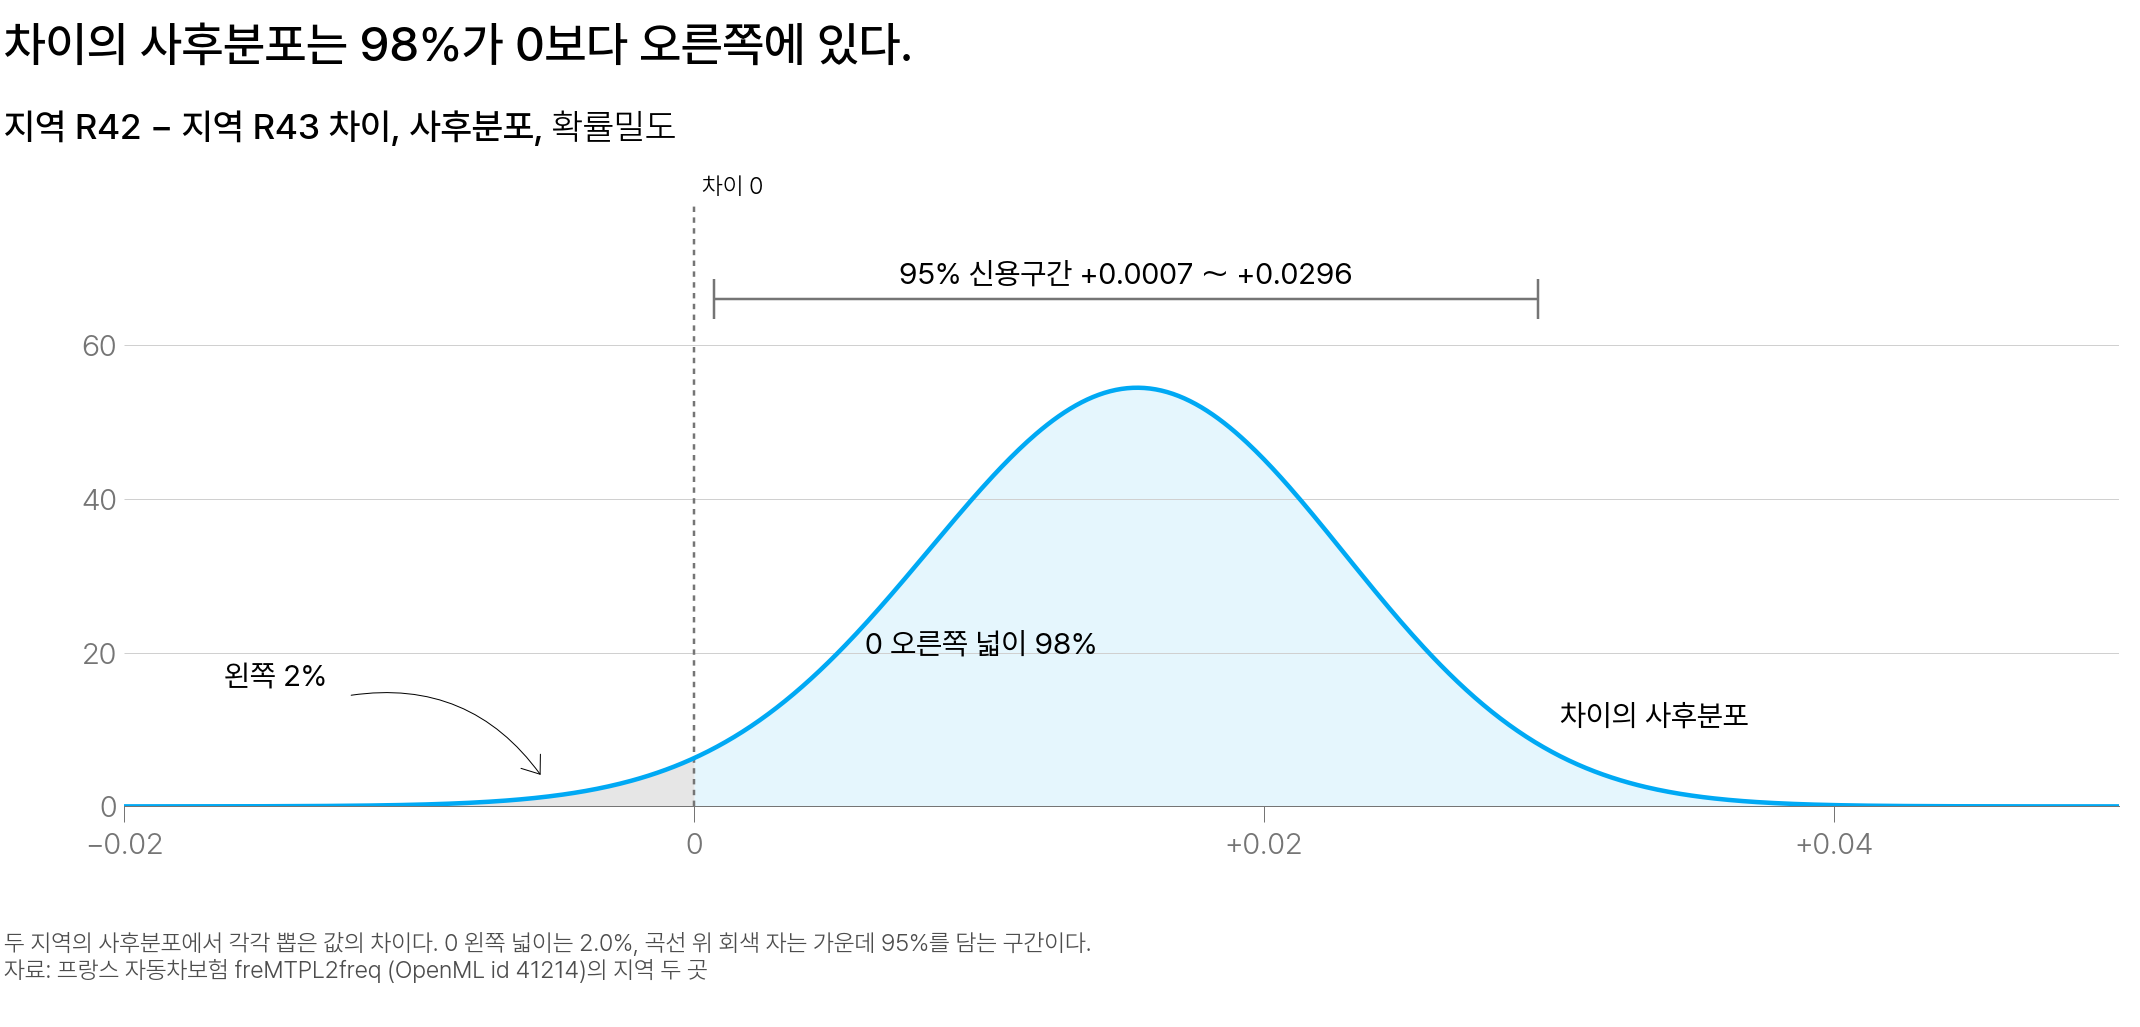

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 차이(지역 R42 − 지역 R43)의 사후분포 — 회색 점선이 차이 0 의 위치이고, 하늘색으로 채운 0 오른쪽 넓이가 98%, 회색으로 남은 왼쪽 꼬리가 2%이며, 곡선 위 회색 막대가 가운데 95%를 포함하는 구간 +0.0007 ～ +0.0296 이다</em></p>

#### 결과 해석

앞의 두 사후분포를 차이 하나의 분포로 합친 그림입니다. 가로축이 "B의 사고 경험률 − A의 사고 경험률" 이라 **0 의 오른쪽 넓이가 곧 $P(\theta_B > \theta_A)$** 입니다. 채운 넓이가 98%, 얇은 왼쪽 꼬리가 2% 입니다. 곡선 하나로 확률 1개와 신용구간 1개를 함께 계산할 수 있습니다.

**실질 동등 구간(region of practical equivalence)** — 이 안의 차이라면 요율을 다시 매길 만큼은 아니라고 미리 정해 두는 구간입니다. 여기서는 지역 R43 의 사후 평균에서 위아래로 0.005, 곧 계약 1만 건당 50건까지를 그 범위로 잡았습니다. 방금 읽은 신용구간 +0.0007 ～ +0.0296 을 그 범위와 비교하면 아래쪽 끝은 안에 들어와 있고, 위쪽 끝은 0.005 의 약 6배라 범위 밖입니다 — 방향은 정해졌는데 "다시 매길 만한 차이인가" 는 아직 판정되지 않은 상태입니다.

### [직접 해보기] 계약이 쌓이면서 두 곡선이 분리되는 과정

지금까지는 계약을 전부 넣은 **최종** 사후분포만 봤습니다. 한 건씩 들어오는 동안 두 곡선이 어떻게 변했는지 봅니다. 위젯은 두 지역에 **같은 수**의 계약을 넣습니다.

1. **조작.** 위젯은 `각 700건` 에서 열립니다. `투입 계약 수` 슬라이더를 왼쪽 끝(계약 80건)으로 옮겨 놓고, 거기서부터 한 단계씩 증가시켜 보세요. 주요 변화는 앞쪽 200건 구간에 집중됩니다.
2. **관찰.** 두 Beta 사후분포가 좁아지며 겹치던 구간이 줄고 `P(θ_B > θ_A)` 숫자가 함께 갱신됩니다. 가운데 회색으로 칠한 `실질 동등 구간`(위젯 화면의 `회색 띠`) 이 본문에서 정한 그 구간이고, R42 곡선이 그 회색 면을 얼마나 벗어나 있는지 확인합니다.
3. **확인 질문.** 옮기기 전에 예측해 보세요 — 계약을 늘려 갈 때 $P(\theta_B > \theta_A)$ 가 0.98 까지 한 방향으로만 증가할까요?

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/ab-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 계약이 누적될 때 P(θ_B > θ_A) 의 단조 증가 여부</summary>

한 방향으로 증가하지 않습니다. `각 83건` 에서 0.941 까지 증가했다가 `각 177건` 에서 0.600 으로 다시 감소하고, 거기서 다시 증가합니다. 화면의 `P(θ_B > θ_A)` 숫자와 맞춰 보세요. 사고는 드문 사건이라 몇백 건을 넣는 동안 지역 R43 쪽에 사고가 집중되면 두 곡선이 다시 가까워지기 때문입니다.

정리할 것이 2개입니다. 하나, **중간에 본 0.941은 결론이 아닙니다**. 더 넣으면 달라질 수 있는 값입니다. 둘, 계약을 다 넣고 나면 곡선이 충분히 좁아져 사고 한두 건으로는 거의 달라지지 않습니다.

이 감소 구간은 `각 83건` 과 `각 177건` 사이입니다. 위젯이 열리는 `각 700건` 에서 오른쪽으로만 옮기면 이미 지나간 뒤라, 왼쪽 끝에서부터 증가시켜야 확인할 수 있습니다.

위젯이 양쪽에 같은 수를 넣는 것도 한 번 확인해 둡니다. 앞 그림에서 R42 곡선이 좁았던 것은 계약이 2,200건으로 더 많아서였는데, 여기서는 양쪽이 같은 수라 그 이점이 없어 R42 곡선이 R43 보다 좁지 않고 오른쪽 끝에서는 오히려 조금 넓습니다. 오른쪽 끝(`각 1,326건`)의 R42 는 2,200건 가운데 앞 1,326건만 쓴 것이라, 그 사후분포의 중심도 0.059 로 최종 그림의 0.057 과 조금 다릅니다.

</details>

## 사고 여부 대신 사고 건수 — 감마-포아송 모형

사고 경험 여부만 기록하면 사고를 2번 낸 계약과 1번 낸 계약이 같아지고, 1년짜리 계약과 3개월짜리 계약도 같아집니다. 이 데이터의 본래 지표는 **사고 건수 ÷ 노출**입니다.

**감마-포아송** — 포아송 우도에 감마 사전분포를 짝지은 켤레 모형입니다(3절 표의 두 번째 행). 노출 $E$년을 관측한 계약의 사고 건수가 평균 $\lambda E$ 의 포아송이라, 갱신 공식의 관측 수 $n$ 항에 **노출 합**이 들어갑니다.

$$
\lambda \mid \text{데이터} \;\sim\; \text{Gamma}\Big(\alpha_0 + \textstyle\sum_i y_i,\;\; \beta_0 + \sum_i E_i\Big)
$$

- $y_i$ : $i$번째 계약의 사고 건수
- $E_i$ : 그 계약의 노출 — 관측 기간이고 단위는 년입니다
- $\alpha_0$, $\beta_0$ : 감마 사전분포의 두 모수 — 중심 $(\alpha_0-1)/\beta_0$ 과 강도 $\beta_0$ 입니다
- $\sim$ : "오른쪽 분포를 따른다" 는 기호이고, 세로 막대 $\mid$ 는 1절과 같이 "데이터를 본 뒤" 라는 조건입니다

그 사후분포의 최빈값, 곧 노출 기준 MAP 는 $(\alpha_0 + \sum_i y_i - 1)/(\beta_0 + \sum_i E_i)$ 입니다. 실습에서 세그먼트마다 쓰는 식이 이것입니다.

여기서는 사전분포의 강도를 0 으로 둔($\alpha_0 = \beta_0 = 0$) 선택을 씁니다 — 사후 평균이 4절의 노출 보정 사고율과 정확히 겹치게 하려는 것이라, 강도 2 인 균등 사전분포 $\text{Beta}(1,1)$ 과는 다른 선택입니다. 그러면 사후분포가 $\text{Gamma}(\sum_i y_i,\ \sum_i E_i)$ 로 줄어듭니다.

R43는 사고 **57건** ÷ 노출 **563.77년**, R42는 **133건** ÷ **1,208.64년** 이라 사후 평균은 **0.1011**·**0.1100** 건/년이고, 앞과 같은 방식으로 계산하면 $P(\lambda_B > \lambda_A) = 0.712$ 입니다.

**그래서** 데이터는 그대로인데 0.980 이 0.712 로 감소했습니다. 두 지표를 나란히 놓고 봅니다.

<details class="lms-extra"><summary>더 깊이 — 강도를 0 으로 둔 선택과 평균·최빈값의 차이</summary>

**⑴ 3절의 $\alpha_0$ 는 어디로 갔나.** 3절의 "가상 사건 + 1" 로 읽으면 $\alpha_0 = 1$ 이 출발점입니다. 여기서는 사후 평균이 노출 보정 사고율과 정확히 겹치도록 한 단계 더 낮췄습니다. $\alpha_0 = \beta_0 = 0$ 은 그 자체로는 넓이를 1로 맞출 수 없는(분포가 아닌) 사전분포이지만, 데이터를 곱하면 사후분포는 정상적인 감마분포로 나옵니다.

**⑵ 평균을 숫자로 확인합니다.** $\text{Gamma}(\alpha, \beta)$ 의 평균은 $\alpha/\beta$ 이고, 첫 모수에 $\sum_i y_i$ 가 둘째 모수에 $\sum_i E_i$ 가 들어갔으니 이 사후 평균은 4절의 노출 보정 사고율 그대로입니다. 두 지역의 사고 합을 각자의 노출 합으로 나눕니다.

$$
\frac{57}{563.77} = 0.10111, \qquad \frac{133}{1{,}208.64} = 0.11004
$$

**⑶ 그 평균은 최빈값과는 다른 요약값입니다.** 3절에서 MAP 로 쓴 최빈값은 $(\alpha-1)/\beta$ 라 지역 R43 는 $56 \div 563.77 = 0.09933$ 입니다. 평균과 얼마나 차이가 나는지 두 값을 뺍니다.

$$
0.10111 - 0.09933 = 0.00178
$$

단위가 건/년이니 노출 1만 년을 곱하면 건수가 됩니다.

$$
0.00178 \times 10{,}000 = 17.8
$$

노출 1만 년당 18건쯤 차이가 납니다. 감마분포가 오른쪽으로 긴 꼬리를 갖고 있어 평균이 최빈값보다 크기 때문이고, 여기서는 4절의 노출 보정 사고율과 정확히 겹치는 평균 쪽을 골랐습니다.

**⑷ 코드의 인자도 대조해 둡니다.** 카드에 적힌 `rng.gamma(57, 1 / 563.77, 1000000)` 에서 첫 인자는 $\sum_i y_i$ 이고, 둘째 인자는 노출 합의 역수입니다 — numpy 는 두 번째 모수를 척도(scale) 방식으로 받기 때문입니다. 셋째 인자 1,000,000 은 추출한 벌 수로, $p$ 가 0.5 에 가까울수록 표준오차가 커지는 것을 보완하려고 10배로 늘렸습니다.

</details>

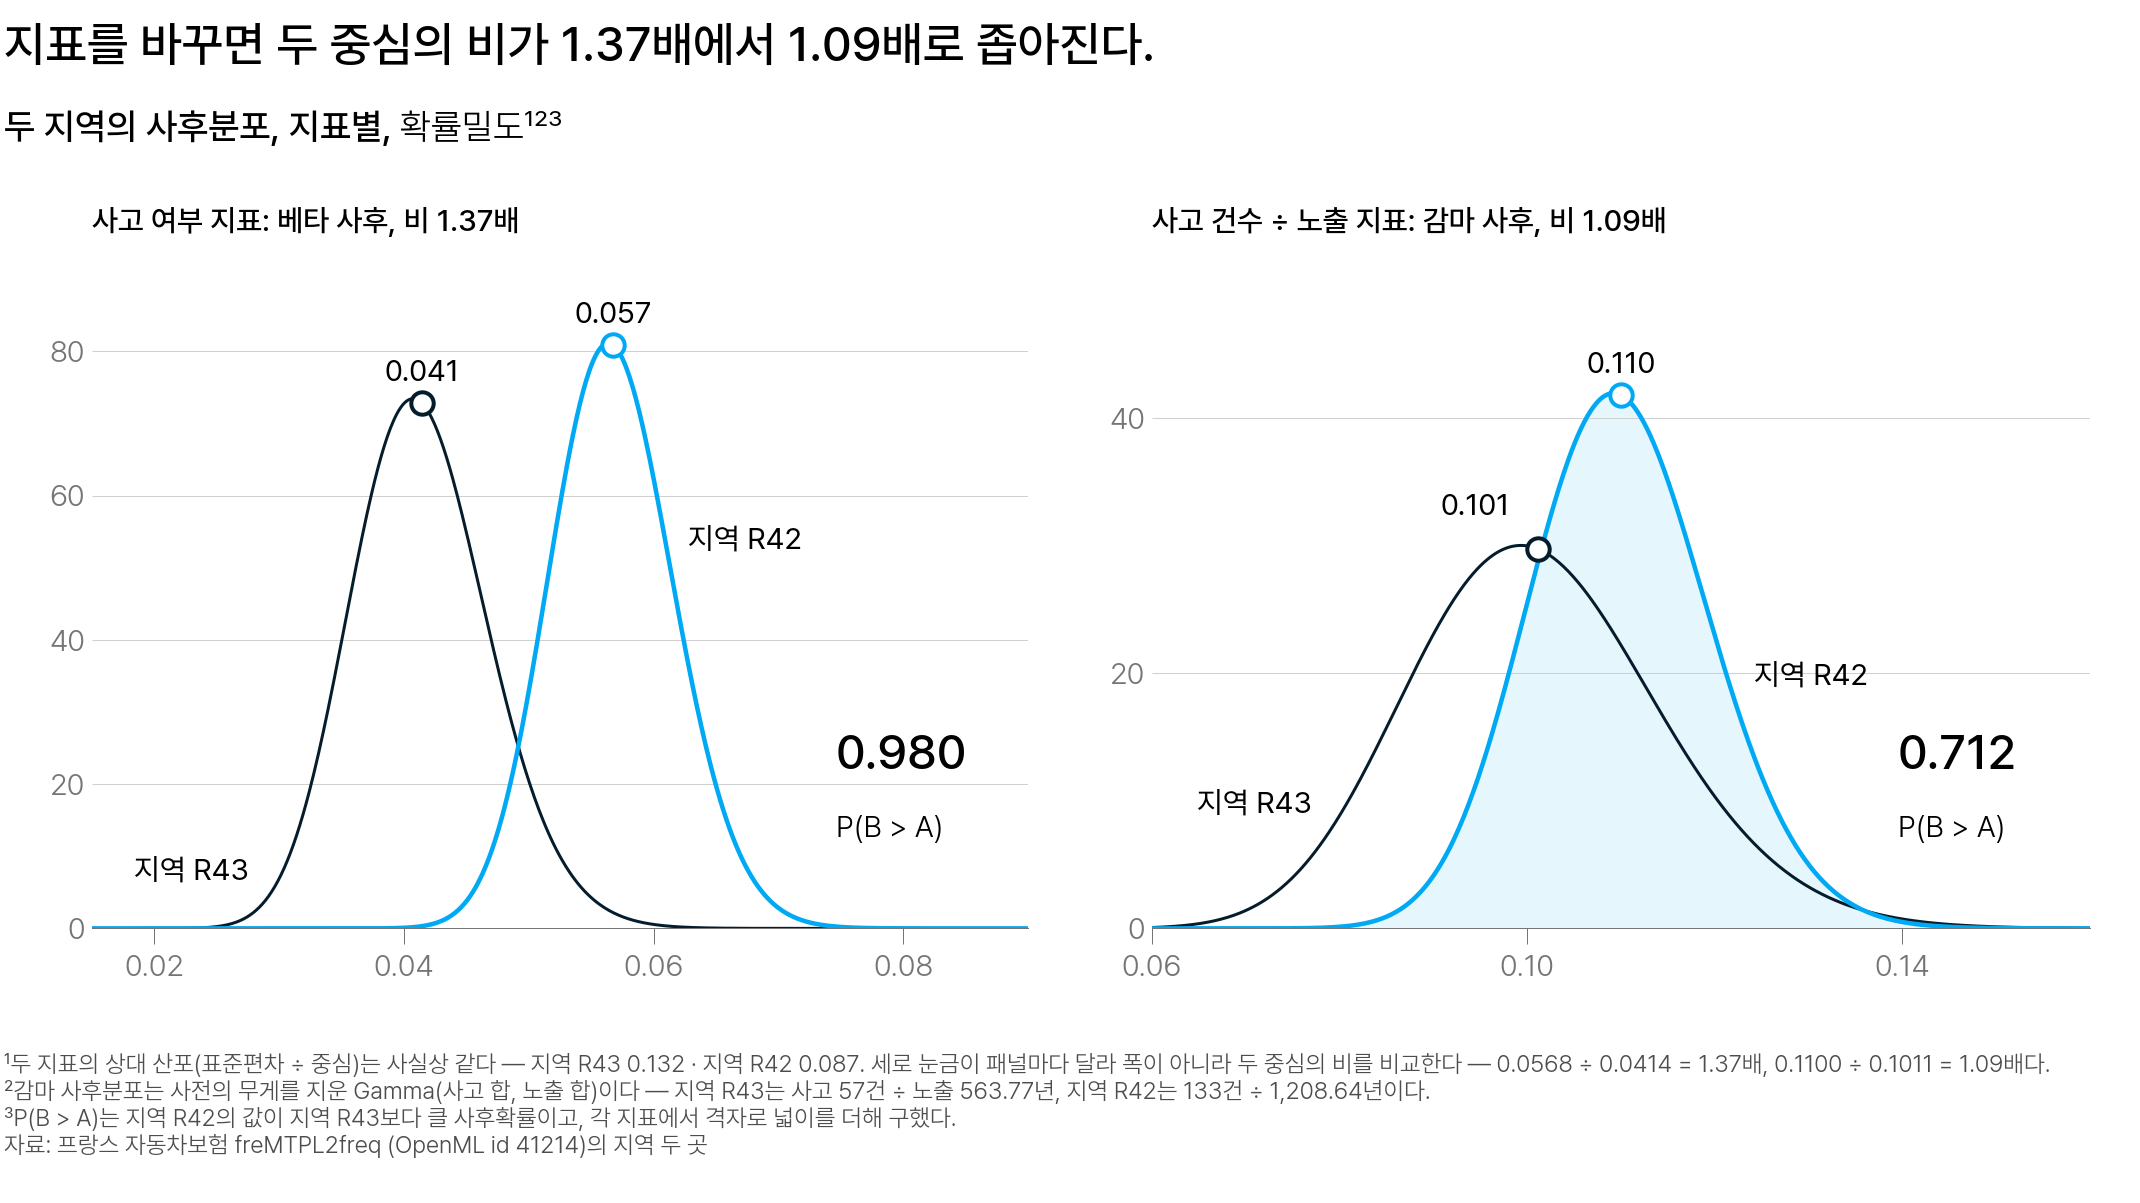

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 두 지표의 사후분포 — 왼쪽은 사고 여부로 계산한 베타 사후분포(남색 지역 R43 중심 0.041 · 하늘색 지역 R42 0.057), 오른쪽은 같은 색 약속으로 사고 건수 ÷ 노출로 계산한 감마 사후분포(0.101 · 0.110)인데, 세로축 척도가 패널마다 달라 산포 대신 두 사후 평균의 비를 비교하면 왼쪽에서 떨어져 있던 두 곡선이 오른쪽에서는 크게 겹치고 P(B > A) 도 0.980 에서 0.712 로 감소한다</em></p>

곡선으로 보면 달라진 부분이 분명하게 드러납니다. 달라진 것은 **두 사후 평균의 비**입니다. 사고 경험률 지표에서 0.0414 대 0.0568 로 1.371배였던 비가, 노출 지표에서는 0.1011 대 0.1100 으로 1.088배까지 감소합니다. 곡선 각각의 산포는 두 지표가 사실상 같으니, 비만 줄어든 만큼 두 곡선이 크게 겹치고 확률이 0.980 에서 0.712 로 감소합니다.

**비가 왜 좁아졌는지는 노출에 있습니다.** 지역 R43의 평균 노출은 노출 합 ÷ 계약 수로 $563.77 / 1{,}326 = 0.4252$년, R42는 $1{,}208.64 / 2{,}200 = 0.5494$년입니다. R42의 계약을 약 30% 더 오래 관측한 것이고, 오래 관측하면 사고를 한 번이라도 겪을 확률은 증가합니다.

두 지역의 사고율을 **같다**고 두고(전체 계약으로 계산한 $\hat{\lambda} = 0.1006$건/년) 각자의 평균 노출만 넣어 보면 이렇습니다.

$$
P(\text{사고} \ge 1) = 1 - e^{-\lambda \bar{E}} \;\Longrightarrow\; \text{지역 R43 } 0.0419,\quad \text{지역 R42 } 0.0538
$$

- $\bar{E}$ : 그 지역 계약 하나의 평균 노출(년), 기호 위의 가로 막대가 평균을 뜻합니다
- $e^{-\lambda\bar{E}}$ : 그 기간에 사고가 0건일 확률이라, 1 에서 빼면 한 번 이상일 확률이 됩니다

사고율을 같게 두고도 예측되는 비가 $0.0538 / 0.0419 = 1.284$ 인데, 관측된 비는 $0.0564 / 0.0407 = 1.384$ 였습니다. **그래서** 사고 경험률에서 본 격차의 **대부분이 "얼마나 오래 관측했나"로 설명**됩니다 — 어떤 지표로 집계하느냐가 결론을 바꿉니다.

<details class="lms-extra"><summary>자세히 — 1 − e^(−λĒ) 에 두 지역의 평균 노출을 넣는 과정</summary>

**⑴ "한 번 이상" 은 여집합으로 계산합니다.** 사고가 한 번 이상일 확률을 직접 더하면 1건·2건·3건… 을 끝없이 더해야 하니, 전체 확률이 1 인 것을 써서 0건일 확률만 구해 빼는 편이 짧습니다.

$$
P(Y \ge 1) = 1 - P(Y = 0)
$$

**⑵ 포아송의 0건 확률을 넣습니다.** 평균 $m$ 인 포아송에서 $y$건이 나올 확률은 $e^{-m} m^{y} / y!$ 입니다. $y = 0$ 이면 $m^{0} = 1$ 이고 $0! = 1$ 이라 남는 것은 $e^{-m}$ 하나입니다.

$$
P(Y = 0) = e^{-m}
$$

**⑶ 평균에 $\lambda\bar{E}$ 를 넣습니다.** 노출 $\bar{E}$년을 관측한 계약의 사고 건수는 평균 $\lambda\bar{E}$ 의 포아송이기 때문입니다.

$$
P(\text{사고} \ge 1) = 1 - e^{-\lambda\bar{E}}
$$

**⑷ 지역 R43 에 숫자를 넣습니다.** 지수부터 계산하면 $0.1006 \times 0.4252 = 0.04278$ 입니다.

$$
1 - e^{-0.04278} = 1 - 0.95813 = 0.04187
$$

**⑸ 지역 R42 도 같은 식으로 넣습니다.** 지수는 $0.1006 \times 0.5494 = 0.05527$ 입니다.

$$
1 - e^{-0.05527} = 1 - 0.94623 = 0.05377
$$

**⑹ 두 값의 비를 계산합니다.** 사고율을 같게 두었는데도 이만큼 차이가 난다는 것이 이 계산의 핵심입니다.

$$
\frac{0.0538}{0.0419} = 1.284
$$

**검산.** 관측된 격차 1.384 가운데 1.284 가 노출 차이만으로 설명되는 부분입니다. 남는 것은 $1.384 \div 1.284 = 1.078$ 로, 노출을 맞추고 나면 R42 가 R43 보다 8% 가량 높은 정도만 남습니다. 노출 지표로 계산한 비 1.088 과 거의 같은 크기입니다.

</details>

**한 문장만 조심하면 됩니다.** 두 지역은 무작위로 나눈 집단이 아니라 계약자가 스스로 사는 곳입니다. 계산으로 알 수 있는 것은 **"두 집단의 사고 경험률이 다르다"** 까지이고 **"지역이 사고율을 높인다"** 는 아닙니다.

그렇다고 사고 경험률 지표가 틀린 것은 아닙니다. 계약자에게 "기간 중 사고를 한 번이라도 겪을 확률" 을 설명해야 하는 경우에는 이 지표가 맞고, 1년치 보험료를 매기는 경우에는 4절이 답으로 남긴 노출 지표가 맞습니다.

**그래서** 요율 회의로 가져갈 문장은 이렇게 됩니다. 방향은 R42 쪽일 사후확률이 98% 이지만 차이의 신용구간은 계약 1만 건당 7건에서 296건 사이이고, 노출 지표로 다시 계산하면 그 확률이 0.712 로 감소합니다. 지금 근거로 지역 간 요율 격차를 키우는 결정은 보류하고, 노출을 반영한 지표로 다시 계산하는 것이 순서입니다. 결정에 필요한 것은 확률 한 숫자가 아니라 **실질 동등 구간**, 곧 "이 구간 안의 차이는 같게 본다" 는 기준을 미리 정해 두는 일입니다.

여기서 쓴 0.980 과 0.712 는 강도 2 인 균등 사전분포로 낸 값입니다. 실습 과제는 같은 두 지역에 전체 계약의 경험률을 중심에 둔 가상 관측 100건(강도 $\alpha+\beta = 102$)인 사전분포를 적용하므로, 두 사후분포가 함께 수축해 확률이 이 값보다 작아집니다.

#### 핵심 주의점

$P(\theta_B > \theta_A) = 0.980$ 을 "차이가 크다" 로 읽으면 안 됩니다.

$$
P(\theta_B > \theta_A) = \int_0^1 f_B(\theta)\, F_A(\theta)\; d\theta = 0.980
$$

이 적분은 B 가 A 보다 큰 쪽에 누적된 넓이라 방향만 측정하고 차이의 크기는 반영하지 않습니다. 따라서 0.980 을 "R42 가 R43 보다 98% 더 나쁘다" 로 옮겨 적으면 틀린 문장이 됩니다.

정확한 뜻은 다음과 같습니다.

> **데이터를 본 뒤 R42 의 사고 경험률이 R43 보다 클 사후확률이 0.980 이고, 그 차이는 계약 1만 건당 7건에서 296건 사이다.**

> 두 후보를 비교하는 일은 확률 한 숫자를 내는 일이 아니라, 어느 지표로 집계할지와 어느 구간까지를 같게 볼지를 먼저 정하는 일입니다.

> **[문제] 요율 회의에 어느 지표를 사용할까**
>
> 같은 데이터에서 사고 경험률 지표는 $P(\theta_B > \theta_A) = 0.980$, 노출 지표는 $P(\lambda_B > \lambda_A) = 0.712$ 가 나왔습니다. 요율 회의에 어느 쪽을 사용할지 고르고, 두 지역의 평균 노출 0.4252년·0.5494년과 차이의 신용구간 +0.0007 ～ +0.0296 을 근거로 이유를 3문장으로 적어 보세요.

## 6절 오늘의 정리와 수업에서 다룰 질문

## 오늘의 정리

**이 절에서 할 일**

1. 사전분포에서 사후분포까지, 오늘 배운 개념 5개를 한 문장 정의로 다시 적습니다.
2. 같은 데이터에서 MLE 0.70 과 MAP 0.67 이 어디서 달라지는지 흐름도 1장으로 확인합니다.
3. 지표를 바꾸자 0.980 이 0.712 로 감소한 지점을 확인해, 회의로 가져갈 문장 하나를 정합니다.

어제 정의한 **우도**와 그 최댓값을 주는 **MLE** 위에, 오늘 한 일은 사전분포를 한 번 곱한 것 하나입니다. 곱하고 나면 답이 값 하나가 아니라 분포로 나옵니다.

**베이즈 정리(Bayes' theorem)** — 사전분포에 우도를 곱하면 사후분포에 비례합니다. 데이터를 보기 전의 사전분포를 데이터로 갱신해 사후분포로 바꾸는 규칙입니다.

$$
p(\theta \mid X) \;\propto\; p(\theta) \times L(\theta)
$$

- $p(\theta)$ : **사전분포** — 데이터를 보기 전에 어느 모수값이 얼마나 그럴듯한지 그려 둔 분포
- $L(\theta)$ : **우도** — 모수값이 $\theta$ 라면 지금 이 데이터가 나올 가능성
- $p(\theta \mid X)$ : **사후분포** — 둘을 곱해 다시 그린 분포. 오늘의 산출물이 이것입니다

**사전분포의 강도와 비중** — 가상 관측 수 $\nu = (\alpha-1)+(\beta-1)$ 이 최빈값을 어디에 둘지 정하고, 관측 $n$ 이 들어왔을 때 $\nu/(\nu+n)$ 이 사전분포의 비중(최빈값 기준)입니다. 두 모수를 더한 $\alpha+\beta = \nu+2$ 는 강도(유효 표본 수)라 부르고 곡선의 산포를 정하니, 위치와 산포는 따로 고르는 값입니다. 관측이 쌓일수록 비중은 작아집니다.

**켤레 사전분포(conjugate prior)** — 사전분포와 사후분포가 같은 분포족이 되는 짝입니다. 베타-베르누이·감마-포아송이 그렇고, 갱신이 덧셈 2회로 끝납니다. 감마분포의 $\beta_0$ 는 「가상으로 몇 년 더 관측했다」 는 강도이고, 노출 기준 MAP 는 $(\alpha_0 + \sum_i y_i - 1)/(\beta_0 + \sum_i E_i)$ 입니다. 그 강도를 얼마로 둘지는 데이터가 아니라 사람이 정합니다.

**MAP(maximum a posteriori)** — 사후분포의 최빈값, 곧 사전분포를 반영한 MLE 입니다. 관측이 적은 세그먼트에서 추정값이 극단값으로 나오는 정도를 감소시킵니다. $\text{Beta}(2,2)$ 사전분포에 동전 10번·앞면 7번이면 MLE 0.70 / MAP 0.67 이고, 3번에 3번이면 MLE 1.00 / MAP 0.80 입니다.

**신용구간(credible interval)** — 사후분포에서 잘라 낸 구간입니다. 사후분포는 넓이가 1인 분포라 모수에 확률을 부여할 수 있고, 그래서 95% 를 「모수가 이 구간 안에 있을 사후확률」로 읽습니다.

**노출(exposure)** — 계약 하나가 보장을 받은 기간(년)입니다. 사고 건수를 이 기간으로 나눠야 연 단위 사고율이 됩니다. 계약 67만 8천 건에서 계약당 단순 평균은 사고 0.0532건이지만, 사고 건수 합을 노출 합(년)으로 나누면 **0.1006건/년**입니다.

두 집단을 비교할 때도 점추정 2개가 아니라 사후분포 2개를 겹칩니다. $P(\theta_B > \theta_A) = 0.980$ 은 **어느 쪽이 큰가**에 답하고, 차이의 신용구간 $+0.0007 \sim +0.0296$ 은 **얼마나 다른가**에 답합니다. 두 숫자가 한 짝이어야 회의로 가져갈 문장이 됩니다.

<details class="lms-extra"><summary>자세히 — 오늘 구분한 개념 쌍 5개의 수치 대조</summary>

이름이 닮아 혼동하기 쉬운 쌍만 선별해, 구분되는 지점과 오늘 나온 숫자를 나란히 둡니다.

| 쌍 | 구분되는 지점 | 오늘 숫자 |
|---|---|---|
| 확률 / 우도 | 무엇을 고정하나 | 동전 3번에 앞면 2번 — $p = 2/3$ 고정 시 $P(x=2) = 0.444$ / 데이터 $x=2$ 고정 시 $L(2/3) = 0.444$ |
| MLE / MAP | 사전분포를 곱하나 | $\text{Beta}(2,2)$ 사전에서 0.70 / 0.67 (동전 3번에 3번이면 1.00 / 0.80) |
| 최빈값 / 사후 평균 | 곡선이 가장 높은 위치냐 기댓값이냐 | $\text{Beta}(9,5)$ 에서 0.667 / 0.643 |
| 신뢰구간 / 신용구간 | 95% 가 무엇의 비율인가 | 표집 반복 시 포함 비율 / 모수의 사후확률 — 둘 다 구간은 0.0497 ～ 0.0508 |
| 사고 경험률 / 사고율 | 무엇을 집계하고 무엇으로 나누나 | 0.0502 (사고를 겪은 계약 34,060 ÷ 계약 678,013) / 0.1006건/년 (사고 36,056건 ÷ 노출 358,360년) |

숫자가 같은 셀이 2개 있는데, 그것이 이 표의 요점입니다. 확률과 우도는 값이 0.444 로 같아도 무엇을 고정했는지가 다르고, 신뢰구간과 신용구간은 구간이 0.0497 ～ 0.0508 로 같아도 95% 가 무엇의 비율인지가 다릅니다.

</details>

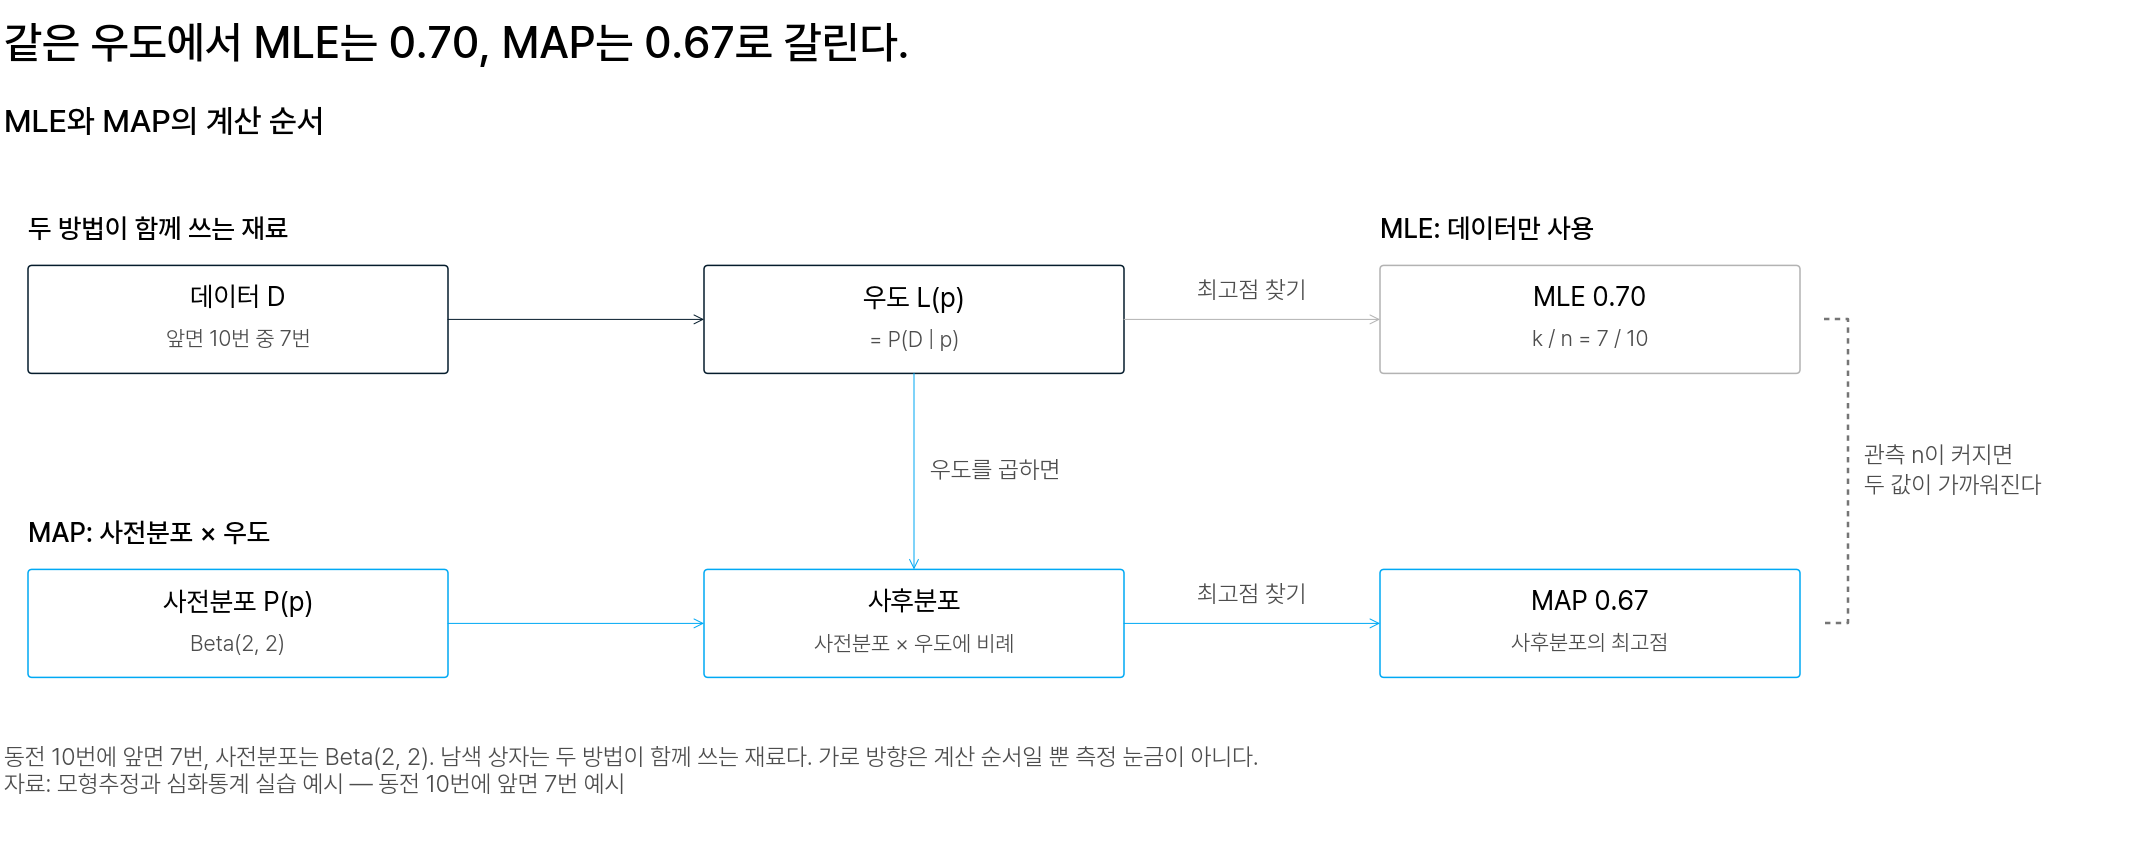

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 남색 상자(데이터 D · 우도 L(p))에서 오른쪽으로 그대로 가면 회색 MLE 0.70, 아래 가로 행으로 분기해 사전분포를 곱하면 하늘색 MAP 0.67 — 같은 우도에서 두 답이 달라진다</em></p>

오른쪽 점선 브래킷이 두 답을 묶어 둔 근거는 앞서 실행한 실행 카드입니다 — 같은 70% 비율에서 관측을 10건에서 640건으로 늘리자 MAP 가 0.6667 에서 0.6994 로, MLE 0.7000 에 근접했습니다. 관측이 많아질수록 사전분포의 비중이 작아진다는 뜻입니다.

**그래서** 오늘 남는 것은 값 하나가 아니라 지표 고르기입니다. 사고 경험률 지표에서는 $P(\theta_B > \theta_A) = 0.980$ 이었는데, 사고 건수를 노출(보장 기간)로 나눈 지표로 바꾸자 $P(\lambda_B > \lambda_A) = 0.712$ 로 감소했습니다. 같은 데이터인데 결론의 확신 정도가 달라진 것입니다. 그래서 회의로 가져갈 문장은 「지금 근거로 지역 간 요율 격차를 키우는 결정은 보류하고, 노출을 반영한 0.712 쪽 지표로 다시 계산한다」입니다. 두 지역은 무작위로 배정한 집단이 아니니 말할 수 있는 데까지가 「두 집단의 사고 경험률이 다르다」이고, 「지역이 사고율을 높인다」는 인과 표현은 넣지 않습니다.

#### 핵심 주의점

우도 곡선의 높이를 "모수가 그 값일 확률" 로 읽으면 안 됩니다.

$$
L(2/3) = P(x = 2 \mid p = 2/3) = 0.444
$$

우도는 모수값마다 다른 확률표에서 값을 하나씩 가져온 것이라 $p$ 전체에 대해 더하거나 적분해도 1 이 아닙니다. 따라서 0.444 는 "$p = 2/3$ 일 확률이 44.4%" 라는 뜻이 아닙니다.

정확한 뜻은 다음과 같습니다.

> **$p = 2/3$ 이라는 모형에서 동전 3번에 앞면 2번이 나올 확률이 0.444 이고, 확률을 부여해 말할 수 있는 것은 넓이가 1 인 사후분포 쪽이다.**

> MLE 는 우도가 최대인 값 하나를 고르고, 베이즈 추정은 사전분포와 데이터를 합쳐 분포를 산출합니다 — 그 분포의 최빈값이 MAP 이고, 데이터가 충분히 쌓이면 두 답이 사실상 겹칩니다.

<details class="lms-extra"><summary>더 깊이 — 우도에는 확률을 부여하지 못하고 사후분포에는 부여하는 이유</summary>

우도를 처음 배울 때 「우도 곡선의 높이는 모수에 대한 확률이 아니다」라고 언급했습니다. 그런데 오늘은 사후분포를 두고 $P(\theta_B > \theta_A) = 0.980$ 이라고 확률을 부여했습니다. 두 문장이 어떻게 함께 성립하는지 정리합니다.

먼저 높이 자체의 정체부터 봅니다. 값이 이산인 동전·사고 건수에서는 우도 곡선의 높이 그 자체가 확률입니다 — 다만 **데이터가 나올 확률**이지 모수의 확률이 아닙니다. 값이 이어진 경우에는 높이가 밀도라서, 넓이라야 확률이 됩니다.

구분되는 지점은 넓이입니다. 우도 곡선은 모수값마다 서로 다른 확률표에서 값을 하나씩 가져온 것이라, $\theta$ 값을 따라 다 더해도 1이 되지 않습니다. 넓이가 1이 아닌 곡선은 확률분포가 아니니 「$\theta$ 가 0.7 보다 클 확률」 같은 문장은 성립하지 않습니다.

사후분포는 다릅니다. 사전분포에 우도를 곱한 뒤 전체 넓이가 1이 되도록 나눠 주므로($p(X)$ 로 나누는 그 단계), $\theta$ 전체에 정의된 하나의 분포가 됩니다. 넓이가 1이니 구간의 넓이를 확률로 읽어도 되고, 그래서 $P(\theta_B > \theta_A)$ 도 신용구간도 자격을 얻습니다.

</details>

오늘은 계약 전체에 사고율 하나를 매겼지만, 실제 요율은 나이·차종·지역을 반영해야 합니다. 모수 하나짜리 $\lambda$ 를 계약 특성의 함수로 바꾸는 작업이 **일반화선형모형(GLM)** 이고, 다음 권에서 그 안에 오늘의 우도·사후분포가 그대로 다시 들어갑니다. 더 보려면 Seeing Theory(seeing-theory.brown.edu)의 Bayesian Inference 챕터를 권합니다.

## 수업에서 다룰 질문

읽기는 여기까지입니다. 판단이 나뉘는 문제를 1개 제시합니다. 정답이 정해져 있지 않은 문항이라, 혼자 입장을 정해 두고 수업에서 팀원들과 근거를 비교한 뒤 팀 답 하나로 정리하는 활동입니다.

> **[문제] 팀 라운드 — 사고 0건으로 나온 세그먼트의 요율**
>
> 4절에서 사용한 자동차보험 계약 67만 8천 건의 연간 사고율은 0.1006건/년입니다. 그런데 실제 요율표는 전체 계약에 한 숫자를 매기지 않고, 지역·차종처럼 잘게 쪼개서 세그먼트마다 사고율을 매깁니다. 쪼개면 계약이 수십 건뿐인 세그먼트가 생기고, 그런 세그먼트에서는 관측 기간 내내 사고가 한 건도 없는 일이 흔합니다 — MLE는 그 세그먼트의 사고율을 그대로 0 으로 계산합니다. 요율 회의에 이 표를 제출해야 하는데, 팀 안에서 의견이 3가지로 나뉘었습니다.
> 
> - **관점 A — 데이터가 말한 대로 쓰자.** 추정값은 데이터로 계산한 값을 그대로 쓰고, 그 세그먼트의 계약 수와 노출을 나란히 적어 관측이 적다는 사실까지 함께 보고하면 된다. 사전분포를 적용하는 순간 그 숫자에는 분석가의 판단이 포함된다.
> - **관점 B — 전체 계약의 사고율을 사전으로 걸자.** 0으로 매긴 세그먼트는 보험료가 사실상 공짜가 된다. 0.1006 을 평균으로 둔 감마 사전분포를 설정하고 MAP를 쓰면, 관측이 적은 세그먼트는 전체 계약의 평균 쪽으로 수축하고 계약 수가 많은 세그먼트는 데이터 값을 유지한다.
> - **관점 C — 애초에 그렇게 잘게 쪼개지 말자.** 수정할 대상은 추정 방법이 아니라 표를 설계한 방식이다. 계약이 적은 세그먼트는 인접한 세그먼트와 합쳐 노출을 키우거나, 데이터가 더 쌓일 때까지 그 세그먼트에는 전체 계약의 요율을 그대로 적용하자.
> 
> 자기 입장 하나와 근거 3문장, 그리고 확신도를 정해 오세요.